In [1]:
import sys
from pathlib import Path

import os

# Set the working directory to the root of the project
os.chdir(Path('..').resolve())  # Adjust this path as necessary

# Now append the src directory to the path
import sys
sys.path.append(str(Path('src').resolve()))

import numpy as np
import pandas as pd
# Now import the necessary modules
from config import Config
import argparse
import logging
from pathlib import Path
from config import Config, setup_logging
from model import get_models
from data_loader import (
    StockDataset,
    download_stock_data,
    get_sp500_tickers,
    prepare_data,
    create_dataloader
)
from trainer import GANTrainer
from evaluation import (
    generate_synthetic_data,
    evaluate_quality,
    plot_results,
    plot_training_history,
    analyze_distributions
)
# Initialize configuration and check the data directory
config = Config()
print(f"Data directory: {config.DATA_DIR}")

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Fetch S&P 500 tickers and download stock data
tickers = get_sp500_tickers(config)
stock_data = download_stock_data(tickers, config)
# stock_data

INFO:data_loader:Loaded data for 495 stocks


Data directory: data
data/stock_data.pkl


Original 5 days of data:
                  Open        High         Low       Close   Volume
Date                                                               
2020-01-02  148.561874  150.510040  148.110367  150.501678  4307633
2020-01-03  148.010040  149.381271  146.847824  149.205688  2950412
2020-01-06  148.118729  149.423080  147.449829  149.347824  2389608
2020-01-07  149.063538  149.255859  147.842804  148.745819  2598908
2020-01-08  148.829437  151.755859  148.536789  151.028427  3298927


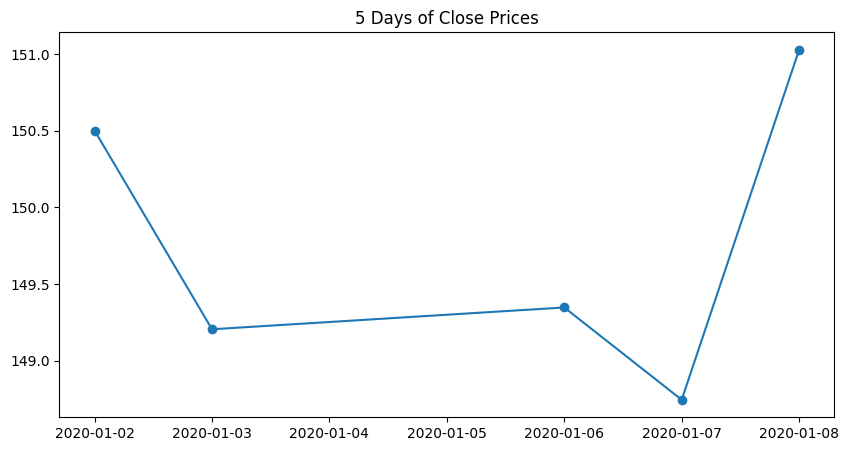

In [2]:
# Cell 1: Setting up initial data and visualization
import torch
import numpy as np
import matplotlib.pyplot as plt

# Take one stock sequence (5 days of data)
first_stock = list(stock_data.values())[0]
five_days = first_stock.iloc[:5]

print("Original 5 days of data:")
print(five_days)

plt.figure(figsize=(10, 5))
plt.plot(five_days['Close'], marker='o')
plt.title('5 Days of Close Prices')
plt.show()

In [3]:
print("first 10 date indexes for our stock:")
print(first_stock.index[:10])  # Show first 10 dates

# Calculate day differences
day_diffs = pd.Series(first_stock.index).diff()
print("\nTime differences between consecutive records:")
day_diffs.value_counts().sort_index()

first 10 date indexes for our stock:
DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15'],
              dtype='datetime64[ns]', name='Date', freq=None)

Time differences between consecutive records:


Date
1 days    596
2 days      3
3 days    133
4 days     23
Name: count, dtype: int64

We can see that we don't have consecutive dates which is common in financial markets that are closed on the weekends. We need to take this into account when generating synthetic data.

Stock data lengths:
Min rows: 11
Max rows: 756
Mean rows: 752.3777777777777

Unique row counts and their frequency:
11       1
240      1
518      1
568      1
703      2
756    489
Name: count, dtype: int64


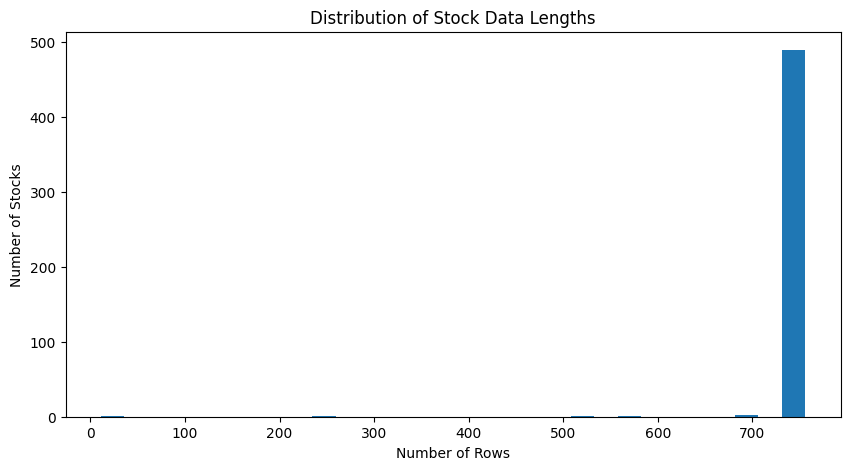


Example stocks with different lengths:

Stock GEHC has 11 rows:
First date: 2022-12-15 00:00:00
Last date: 2022-12-30 00:00:00

Stock CEG has 240 rows:
First date: 2022-01-19 00:00:00
Last date: 2022-12-30 00:00:00

Stock ABNB has 518 rows:
First date: 2020-12-10 00:00:00
Last date: 2022-12-30 00:00:00


In [4]:
# Cell 5: Check row counts for all stocks
stock_lengths = {}
for symbol, data in stock_data.items():
    stock_lengths[symbol] = len(data)

# Convert to pandas Series for easy analysis
lengths = pd.Series(stock_lengths)

print("Stock data lengths:")
print("Min rows:", lengths.min())
print("Max rows:", lengths.max())
print("Mean rows:", lengths.mean())
print("\nUnique row counts and their frequency:")
print(lengths.value_counts().sort_index())

# Plot distribution of lengths
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=30)
plt.title('Distribution of Stock Data Lengths')
plt.xlabel('Number of Rows')
plt.ylabel('Number of Stocks')
plt.show()

# Show some examples of stocks with different lengths
print("\nExample stocks with different lengths:")
for length in sorted(lengths.unique())[:3]:  # Show first 3 different lengths
    symbol = lengths[lengths == length].index[0]
    print(f"\nStock {symbol} has {length} rows:")
    print("First date:", stock_data[symbol].index[0])
    print("Last date:", stock_data[symbol].index[-1])

- 489 stocks have complete data (756 rows)

- A few stocks have significantly less data

- One stock has only 11 rows

I will remove stocks that have less than 100 days of data.

In [5]:
stock_data['MMM'].head(2)

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,148.561874,150.510040,148.110367,150.501678,4307633
2020-01-03,148.010040,149.381271,146.847824,149.205688,2950412


In [6]:
# import numpy as np

# # Define the minimum length for valid stocks
# MIN_LENGTH = 100  # Only take stocks that have 100 or more days of data

# # Filter valid stocks based on minimum length
# valid_stocks = {symbol: data for symbol, data in stock_data.items() 
#                 if len(data) >= MIN_LENGTH}

# print(f"After filtering: {len(valid_stocks)} valid stocks out of {len(stock_data)} total")

# # Create a ticker-to-index mapping for one-hot encoding
# tickers = list(valid_stocks.keys())
# ticker_to_idx = {ticker: idx for idx, ticker in enumerate(tickers)}
# num_tickers = len(tickers)

# # Calculate total sequences from valid stocks
# total_sequences = 0
# for stock_df in valid_stocks.values():
#     n_sequences = len(stock_df) - 4  # Assuming 5-day sequences
#     total_sequences += n_sequences

# print(f"Total sequences we can create from valid stocks: {total_sequences}")

# # Initialize storage for sequences with ticker condition, day-of-week, and additional metrics
# # Shape: (total_sequences, sequence_length, OHLCV + ticker one-hot + day one-hot + additional metrics)
# num_days = 5  # Only trading days, Monday to Friday
# num_metrics = 7  # open_return, high_return, low_return, close_return, volume_change, high_low_range, open_close_range
# sequence_length = 5

# # Storage array: OHLCV (5) + ticker encoding (num_tickers) + day encoding (5) + additional metrics (7)
# feature_dim = 5 + num_tickers + num_days + num_metrics
# training_data = np.zeros((total_sequences, sequence_length, feature_dim))

# # Day labels (optional, for weekday analysis if needed)
# day_labels = np.zeros((total_sequences, sequence_length), dtype=int)

# current_idx = 0

# for symbol, stock_df in valid_stocks.items():
#     stock_values = stock_df[['Open', 'High', 'Low', 'Close', 'Volume']].values
#     days = stock_df.index.dayofweek.values  # 0 = Monday, ..., 4 = Friday

#     # Calculate returns and ranges
#     open_return = np.diff(stock_values[:, 0], prepend=np.nan) / stock_values[:, 0]
#     high_return = np.diff(stock_values[:, 1], prepend=np.nan) / stock_values[:, 1]
#     low_return = np.diff(stock_values[:, 2], prepend=np.nan) / stock_values[:, 2]
#     close_return = np.diff(stock_values[:, 3], prepend=np.nan) / stock_values[:, 3]
#     volume_change = np.diff(stock_values[:, 4], prepend=np.nan) / stock_values[:, 4]

#     high_low_range = (stock_values[:, 1] - stock_values[:, 2]) / stock_values[:, 2]
#     open_close_range = (stock_values[:, 0] - stock_values[:, 3]) / stock_values[:, 3]

#     # Stack the metrics into an array for easy slicing
#     additional_metrics = np.column_stack([
#         open_return, high_return, low_return, close_return, 
#         volume_change, high_low_range, open_close_range
#     ])

#     # Handle NaNs in metrics for the first day by filling with 0
#     additional_metrics = np.nan_to_num(additional_metrics)

#     # One-hot encode the ticker condition for this stock
#     ticker_condition = np.zeros(num_tickers)
#     ticker_condition[ticker_to_idx[symbol]] = 1

#     n_sequences = len(stock_df) - sequence_length + 1
#     for i in range(n_sequences):
#         # Store the OHLCV values for the sequence
#         training_data[current_idx, :, :5] = stock_values[i:i+sequence_length]
        
#         # Store the ticker condition for each day in the sequence
#         training_data[current_idx, :, 5:5 + num_tickers] = ticker_condition  # Broadcast across sequence length
        
#         # One-hot encode the day of the week for each day in the sequence
#         day_one_hot = np.eye(num_days)[days[i:i+sequence_length]]
#         training_data[current_idx, :, 5 + num_tickers:5 + num_tickers + num_days] = day_one_hot
        
#         # Store the additional metrics for the sequence
#         training_data[current_idx, :, 5 + num_tickers + num_days:] = additional_metrics[i:i+sequence_length]
        
#         # Store day labels (for optional weekday analysis)
#         day_labels[current_idx] = days[i:i+sequence_length]
        
#         current_idx += 1
        
#         if current_idx % 10000 == 0:
#             print(f"Processed {current_idx}/{total_sequences} sequences")


# print("\nFinal shapes after filtering:")
# print("Training data:", training_data.shape)
# print("Day labels:", day_labels.shape)


In [7]:

# # Define the minimum length for valid stocks
# MIN_LENGTH = 100  # Only take stocks that have 100 or more days of data

# # Filter valid stocks based on minimum length
# valid_stocks = {symbol: data for symbol, data in stock_data.items() 
#                 if len(data) >= MIN_LENGTH}

# print(f"After filtering: {len(valid_stocks)} valid stocks out of {len(stock_data)} total")

# # Create a ticker-to-index mapping for one-hot encoding
# tickers = list(valid_stocks.keys())
# ticker_to_idx = {ticker: idx for idx, ticker in enumerate(tickers)}
# num_tickers = len(tickers)

# # Calculate total sequences from valid stocks
# total_sequences = 0
# for stock_df in valid_stocks.values():
#     n_sequences = len(stock_df) - 4  # Assuming 5-day sequences
#     total_sequences += n_sequences

# print(f"Total sequences we can create from valid stocks: {total_sequences}")

# # Define features
# num_days = 5  # Days in a week
# num_metrics = 7  # open_return, high_return, etc.
# ohlcv_dim = 5  # OHLCV features
# cyclical_day_dim = 2  # Sin and Cos
# sequence_length = 5  # Length of each sequence

# # Define a small epsilon to avoid division by zero
# epsilon = 1e-10

# # Total features
# feature_dim = ohlcv_dim + num_tickers + cyclical_day_dim + num_metrics
# training_data = np.zeros((total_sequences, sequence_length, feature_dim))

# # Placeholder for day labels (optional)
# day_labels = np.zeros((total_sequences, sequence_length), dtype=int)

# current_idx = 0

# for symbol, stock_df in valid_stocks.items():
#     stock_values = stock_df[['Open', 'High', 'Low', 'Close', 'Volume']].values + epsilon
#     days = stock_df.index.dayofweek.values  # 0 = Monday, ..., 4 = Friday
    
#     # Calculate returns and ranges
#     open_return = np.diff(stock_values[:, 0], prepend=np.nan) / stock_values[:, 0]
#     high_return = np.diff(stock_values[:, 1], prepend=np.nan) / stock_values[:, 1]
#     low_return = np.diff(stock_values[:, 2], prepend=np.nan) / stock_values[:, 2]
#     close_return = np.diff(stock_values[:, 3], prepend=np.nan) / stock_values[:, 3]
#     volume_change = np.diff(stock_values[:, 4], prepend=np.nan) / stock_values[:, 4]
#     high_low_range = (stock_values[:, 1] - stock_values[:, 2]) / stock_values[:, 2]
#     open_close_range = (stock_values[:, 0] - stock_values[:, 3]) / stock_values[:, 3]
    
#     # Stack metrics
#     additional_metrics = np.column_stack([
#         open_return, high_return, low_return, close_return, 
#         volume_change, high_low_range, open_close_range
#     ])
#     additional_metrics = np.nan_to_num(additional_metrics)

#     # One-hot encode the ticker
#     ticker_condition = np.zeros(num_tickers)
#     ticker_condition[ticker_to_idx[symbol]] = 1

#     # Calculate cyclical encoding for each day in `days`
#     day_angles = 2 * np.pi * days / num_days
#     cyclical_day_encoding = np.column_stack((np.sin(day_angles), np.cos(day_angles)))

#     # Generate sequences
#     n_sequences = len(stock_df) - sequence_length + 1
#     for i in range(n_sequences):
#         # Store OHLCV values
#         training_data[current_idx, :, :ohlcv_dim] = stock_values[i:i+sequence_length]
        
#         # Store ticker encoding (broadcast across sequence length)
#         training_data[current_idx, :, ohlcv_dim:ohlcv_dim + num_tickers] = ticker_condition
        
#         # Store cyclical day encoding
#         training_data[current_idx, :, ohlcv_dim + num_tickers:ohlcv_dim + num_tickers + cyclical_day_dim] = cyclical_day_encoding[i:i+sequence_length]
        
#         # Store additional metrics
#         training_data[current_idx, :, -num_metrics:] = additional_metrics[i:i+sequence_length]
        
#         # Optionally store day labels for each sequence
#         day_labels[current_idx] = days[i:i+sequence_length]
        
#         current_idx += 1
#         if current_idx % 10000 == 0:
#             print(f"Processed {current_idx}/{total_sequences} sequences")

# print("\nFinal shapes after filtering:")
# print("Training data:", training_data.shape)
# print("Day labels:", day_labels.shape)


import numpy as np
import pandas as pd

# def create_training_sequences(stock_data: dict, sequence_length: int = 5, min_length: int = 100):
#     """
#     Create training sequences with only essential features for GAN training.
#     """
#     # Filter valid stocks
#     valid_stocks = {symbol: data for symbol, data in stock_data.items() 
#                    if len(data) >= min_length}
    
#     print(f"After filtering: {len(valid_stocks)} valid stocks out of {len(stock_data)} total")
    
#     # Create ticker mapping
#     tickers = list(valid_stocks.keys())
#     ticker_to_idx = {ticker: idx for idx, ticker in enumerate(tickers)}
#     num_tickers = len(tickers)
    
#     # Calculate total sequences
#     total_sequences = sum(len(df) - sequence_length + 1 for df in valid_stocks.values())
#     print(f"Total sequences we can create: {total_sequences}")
    
#     # Define dimensions
#     ohlcv_dim = 5  # OHLCV features
#     cyclical_day_dim = 2  # Sin and Cos of day
#     feature_dim = ohlcv_dim + num_tickers + cyclical_day_dim
    
#     # Initialize arrays
#     training_data = np.zeros((total_sequences, sequence_length, feature_dim))
    
#     current_idx = 0
    
#     for symbol, stock_df in valid_stocks.items():
#         # Get OHLCV data
#         ohlcv = stock_df[['Open', 'High', 'Low', 'Close', 'Volume']].values
        
#         # Handle zero or very small values
#         eps = 1e-8
#         ohlcv_safe = np.where(ohlcv == 0, eps, ohlcv)
        
#         # Calculate day of week cyclical encoding
#         days = stock_df.index.dayofweek.values
#         day_angles = 2 * np.pi * days / 5  # 5 trading days
#         cyclical_encoding = np.column_stack((np.sin(day_angles), np.cos(day_angles)))
        
#         # One-hot encode ticker
#         ticker_encoding = np.zeros(num_tickers)
#         ticker_encoding[ticker_to_idx[symbol]] = 1
        
#         # Generate sequences
#         n_sequences = len(stock_df) - sequence_length + 1
#         for i in range(n_sequences):
#             # Store OHLCV
#             training_data[current_idx, :, :ohlcv_dim] = ohlcv_safe[i:i+sequence_length]
            
#             # Store ticker encoding
#             training_data[current_idx, :, ohlcv_dim:ohlcv_dim + num_tickers] = ticker_encoding
            
#             # Store cyclical day encoding
#             training_data[current_idx, :, -cyclical_day_dim:] = cyclical_encoding[i:i+sequence_length]
            
#             current_idx += 1
#             if current_idx % 10000 == 0:
#                 print(f"Processed {current_idx}/{total_sequences} sequences")
    
#     print("\nFinal shape:", training_data.shape)
    
#     return training_data

def create_training_sequences(stock_data: dict, sequence_length: int = 5, min_length: int = 100):
    """
    Create training sequences with only essential features for GAN training.
    """
    # Filter valid stocks
    valid_stocks = {symbol: data for symbol, data in stock_data.items() 
                   if len(data) >= min_length}
    
    print(f"After filtering: {len(valid_stocks)} valid stocks out of {len(stock_data)} total")
    
    # Create ticker mapping
    tickers = list(valid_stocks.keys())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(tickers)}
    num_tickers = len(tickers)
    
    # Calculate total sequences
    total_sequences = sum(len(df) - sequence_length + 1 for df in valid_stocks.values())
    print(f"Total sequences we can create: {total_sequences}")
    
    # Define dimensions
    ohlcv_dim = 5  # OHLCV features
    cyclical_day_dim = 2  # Sin and Cos of day
    feature_dim = ohlcv_dim + num_tickers + cyclical_day_dim
    
    # Initialize arrays
    training_data = np.zeros((total_sequences, sequence_length, feature_dim))
    
    current_idx = 0
    
    for symbol, stock_df in valid_stocks.items():
        # Get OHLCV data
        ohlcv = stock_df[['Open', 'High', 'Low', 'Close', 'Volume']].values
        
        # Handle zero or very small values
        eps = 1e-8
        ohlcv_safe = np.where(ohlcv == 0, eps, ohlcv)
        
        # Calculate day of week cyclical encoding
        days = stock_df.index.dayofweek.values
        day_angles = 2 * np.pi * days / 5  # 5 trading days
        cyclical_encoding = np.column_stack((np.sin(day_angles), np.cos(day_angles)))
        
        # One-hot encode ticker
        ticker_encoding = np.zeros(num_tickers)
        ticker_encoding[ticker_to_idx[symbol]] = 1
        
        # Generate sequences
        n_sequences = len(stock_df) - sequence_length + 1
        for i in range(n_sequences):
            # Store OHLCV
            training_data[current_idx, :, :ohlcv_dim] = ohlcv_safe[i:i+sequence_length]
            
            # Store ticker encoding
            training_data[current_idx, :, ohlcv_dim:ohlcv_dim + num_tickers] = ticker_encoding
            
            # Store cyclical day encoding
            training_data[current_idx, :, -cyclical_day_dim:] = cyclical_encoding[i:i+sequence_length]
            
            current_idx += 1
            if current_idx % 10000 == 0:
                print(f"Processed {current_idx}/{total_sequences} sequences")
    
    print("\nFinal shape:", training_data.shape)
    
    return training_data, ticker_to_idx

# Usage:
training_data, ticker_to_idx = create_training_sequences(stock_data)

After filtering: 494 valid stocks out of 495 total
Total sequences we can create: 370440
Processed 10000/370440 sequences
Processed 20000/370440 sequences
Processed 30000/370440 sequences
Processed 40000/370440 sequences
Processed 50000/370440 sequences
Processed 60000/370440 sequences
Processed 70000/370440 sequences
Processed 80000/370440 sequences
Processed 90000/370440 sequences
Processed 100000/370440 sequences
Processed 110000/370440 sequences
Processed 120000/370440 sequences
Processed 130000/370440 sequences
Processed 140000/370440 sequences
Processed 150000/370440 sequences
Processed 160000/370440 sequences
Processed 170000/370440 sequences
Processed 180000/370440 sequences
Processed 190000/370440 sequences
Processed 200000/370440 sequences
Processed 210000/370440 sequences
Processed 220000/370440 sequences
Processed 230000/370440 sequences
Processed 240000/370440 sequences
Processed 250000/370440 sequences
Processed 260000/370440 sequences
Processed 270000/370440 sequences
Pr

In [8]:
stock_data['MMM'].head(1)

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,148.561874,150.51004,148.110367,150.501678,4307633


In [9]:
# 5 (OHLCV)+494 (tickers)+5 (day-of-week cycle)+2=501

In [10]:
# # Define number of unique days (0 = Monday, ..., 4 = Friday)
# num_days = 5

# # Update `training_data` to accommodate both ticker and day-of-week one-hot encoding
# # New shape: (total_sequences, sequence_length, OHLCV + ticker one-hot + day one-hot)
# training_data = np.zeros((total_sequences, 5, 5 + num_tickers + num_days))

# current_idx = 0
# for symbol, stock_df in valid_stocks.items():
#     stock_values = stock_df[['Open', 'High', 'Low', 'Close', 'Volume']].values
#     days = stock_df.index.dayofweek.values

#     # One-hot encode the ticker condition for this stock
#     ticker_condition = np.zeros(num_tickers)
#     ticker_condition[ticker_to_idx[symbol]] = 1

#     n_sequences = len(stock_df) - 4
#     for i in range(n_sequences):
#         # Store the OHLCV values for the sequence
#         training_data[current_idx, :, :5] = stock_values[i:i+5]
        
#         # Store the ticker condition for each day in the sequence
#         training_data[current_idx, :, 5:5 + num_tickers] = ticker_condition  # Broadcasts across sequence length
        
#         # One-hot encode the day of the week for each day in the sequence
#         day_one_hot = np.eye(num_days)[days[i:i+5]]  # Shape: (5, num_days)
#         training_data[current_idx, :, 5 + num_tickers:] = day_one_hot
        
#         current_idx += 1
        
#         if current_idx % 10000 == 0:
#             print(f"Processed {current_idx}/{total_sequences} sequences")

# print("\nFinal shapes after filtering:")
# print("Training data:", training_data.shape)
# print("Day labels:", day_labels.shape)


In [11]:
# Get the one-hot encoded ticker vector for the first sequence (first day in this example)
ticker_one_hot = training_data[0, 0, 5:]  # Slice after OHLCV (first 5 features)

# Find the index of the ticker in the one-hot vector
ticker_idx = np.argmax(ticker_one_hot)  # Get the position of the '1'

# Get the ticker symbol using the index
ticker_symbol = tickers[ticker_idx]
print("Ticker symbol for the first sequence:", ticker_symbol)


Ticker symbol for the first sequence: MMM


,open_return,high_return,low_return,close_return,volume_change,high_low_range,open_close_range,day_of_week
Date,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,0.016153,0.013057,Thursday
2020-01-03,-0.003715,-0.007500,-0.008524,-0.008611,-0.315073,0.017117,0.008078,Friday
2020-01-06,0.000734,0.000280,0.004100,0.000953,-0.190077,0.013322,0.008298,Monday
2020-01-07,0.006379,-0.001119,0.002665,-0.004031,0.087588,0.009480,-0.002131,Tuesday
2020-01-08,-0.001570,0.016750,0.004694,0.015346,0.269351,0.021629,0.014775,Wednesday
...,...,...,...,...,...,...,...,...
2022-12-23,0.005567,0.005444,0.011914,0.005033,-0.339798,0.016262,0.008650,Friday
2022-12-27,0.009688,0.001782,0.000209,-0.003156,-0.058945,0.017682,-0.004181,Tuesday
2022-12-28,-0.005003,0.003353,0.001393,-0.010117,0.507360,0.019769,-0.009299,Wednesday


Statistics for all metrics by day:


open_return                 high_return                  \
                   mean  median     std        mean  median     std   
day_of_week                                                           
Friday           0.0020  0.0017  0.0261     -0.0004  0.0003  0.0218   
Monday          -0.0007  0.0008  0.0274      0.0003  0.0006  0.0258   
Thursday        -0.0018 -0.0003  0.0265     -0.0009 -0.0006  0.0228   
Tuesday          0.0038  0.0022  0.0256      0.0029  0.0013  0.0223   
Wednesday       -0.0006 -0.0004  0.0240      0.0004  0.0002  0.0230   

            low_return                 close_return  ...          \
                  mean  median     std         mean  ...     std   
day_of_week                                          ...           
Friday          0.0014  0.0015  0.0236       0.0008  ...  0.0243   
Monday         -0.0002  0.0011  0.0264       0.0001  ...  0.0296   
Thursday       -0.0016 -0.0004  0.0249      -0.0002  ...  0.0267   
Tuesday         0.0030  0.0021  0.0232       0.0017  ...  0.0253   
Wednesday       0.0001  0.0011  0.0240       0.0004  ...  0.0260   

            volume_change                 high_low_range                  \
                     mean  median     std           mean  median     std   
day_of_week                                                                
Friday             0.1314  0.0014  0.6216         0.0283  0.0236  0.0190   
Monday                inf -0.0301     NaN         0.0293  0.0239  0.0211   
Thursday              inf -0.0172     NaN         0.0302  0.0243  0.0222   
Tuesday            0.0861  0.0069  0.4435         0.0288  0.0239  0.0191   
Wednesday          0.0503 -0.0267  0.5276         0.0292  0.0240  0.0210   

            open_close_range                  
                        mean  median     std  
day_of_week                                   
Friday                0.0001  0.0004  0.0199  
Monday                0.0008  0.0007  0.0210  
Thursday              0.0013  0.0011  0.0219  
Tuesday              -0.0012 -0.0013  0.0200  
Wednesday            -0.0003  0.0000  0.0206  

[5 rows x 21 columns]

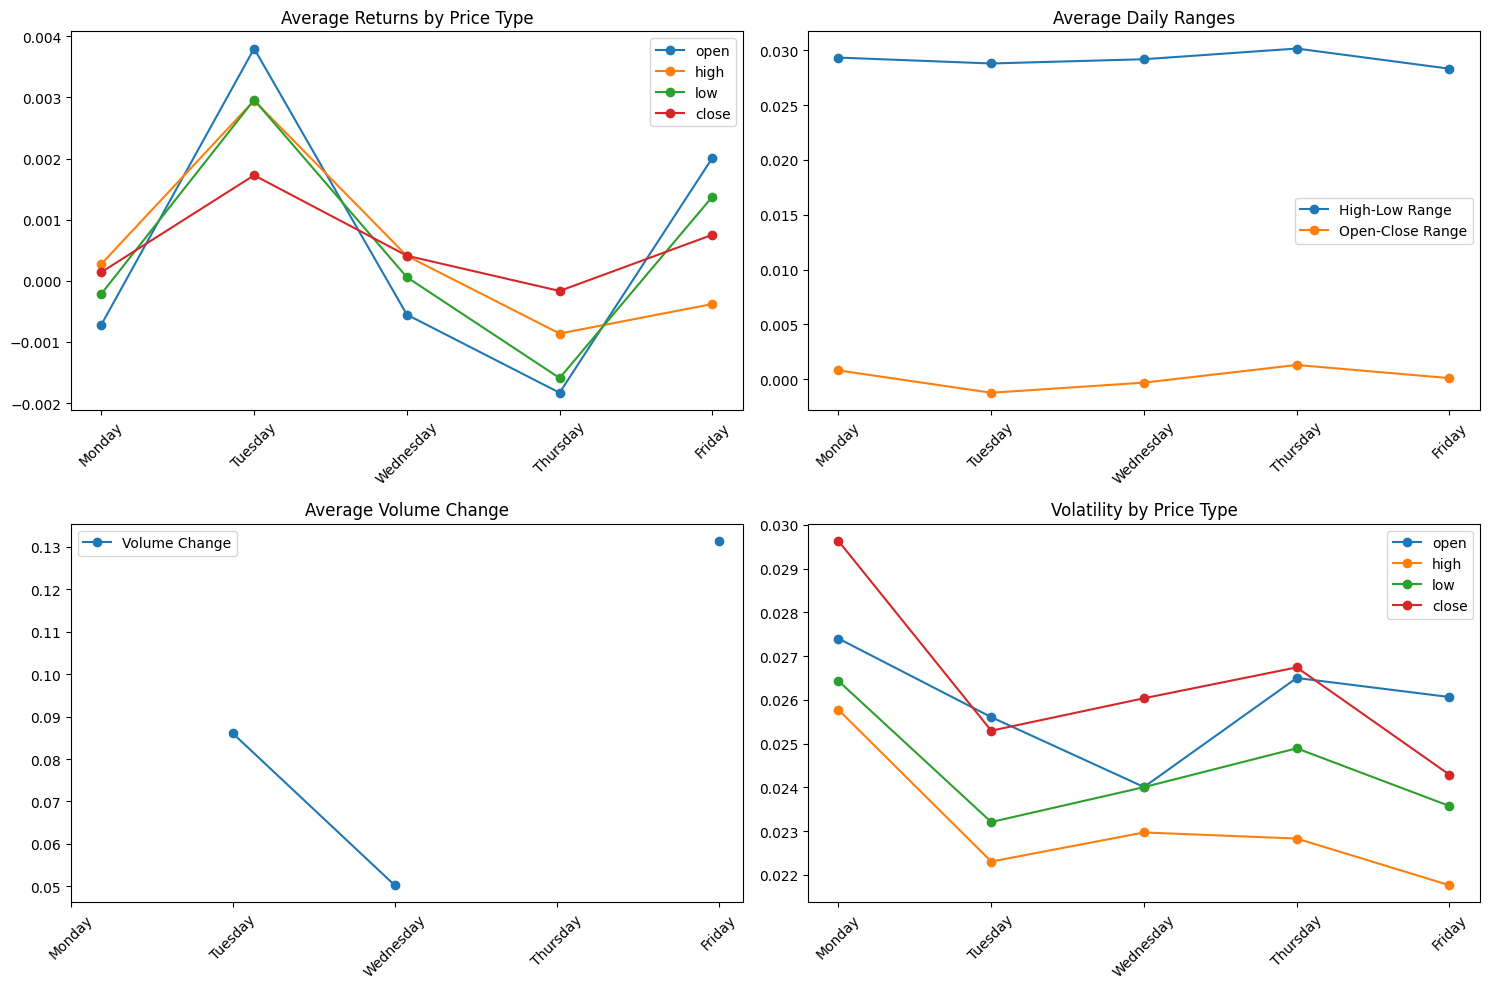


Detailed statistics by day:

Monday:
Mean returns:
  open_return: -0.000717
  high_return: 0.000276
  low_return: -0.000213
  close_return: 0.000142
Mean volume change: inf
Mean high-low range: 0.029327

Tuesday:
Mean returns:
  open_return: 0.003799
  high_return: 0.002949
  low_return: 0.002960
  close_return: 0.001726
Mean volume change: 0.086063
Mean high-low range: 0.028789

Wednesday:
Mean returns:
  open_return: -0.000553
  high_return: 0.000408
  low_return: 0.000059
  close_return: 0.000411
Mean volume change: 0.050265
Mean high-low range: 0.029178

Thursday:
Mean returns:
  open_return: -0.001831
  high_return: -0.000862
  low_return: -0.001590
  close_return: -0.000166
Mean volume change: inf
Mean high-low range: 0.030151

Friday:
Mean returns:
  open_return: 0.002011
  high_return: -0.000380
  low_return: 0.001375
  close_return: 0.000753
Mean volume change: 0.131371
Mean high-low range: 0.028313

Correlations between different metrics:


,open_return,high_return,low_return,close_return,volume_change,high_low_range,open_close_range
open_return,1.000,0.716,0.726,0.352,-0.019,-0.066,-0.003
high_return,0.716,1.000,0.758,0.719,-0.017,0.099,0.445
low_return,0.726,0.758,1.000,0.721,-0.024,-0.173,0.444
close_return,0.352,0.719,0.721,1.000,-0.018,-0.008,0.806
volume_change,-0.019,-0.017,-0.024,-0.018,1.000,0.007,0.001
high_low_range,-0.066,0.099,-0.173,-0.008,0.007,1.000,0.029
open_close_range,-0.003,0.445,0.444,0.806,0.001,0.029,1.000


In [12]:
import numpy as np

all_data = pd.DataFrame()

for symbol, data in stock_data.items():
    # Calculate returns for price columns
    returns_data = pd.DataFrame({
        'open_return': data['Open'].pct_change(),
        'high_return': data['High'].pct_change(),
        'low_return': data['Low'].pct_change(),
        'close_return': data['Close'].pct_change(),
        'volume_change': data['Volume'].pct_change(),  # Volume change
        'high_low_range': (data['High'] - data['Low']) / data['Open'],  # Daily range
        'open_close_range': (data['Close'] - data['Open']) / data['Open'],  # Intraday change
        'day_of_week': data.index.day_name()
    })
    all_data = pd.concat([all_data, returns_data])

display(all_data)

stats_by_day = all_data.groupby('day_of_week').agg({
    'open_return': ['mean', 'median', 'std'],
    'high_return': ['mean', 'median',  'std'],
    'low_return': ['mean', 'median',  'std'],
    'close_return': ['mean', 'median',  'std'],
    'volume_change': ['mean', 'median',  'std'],
    'high_low_range': ['mean', 'median',  'std'],
    'open_close_range': ['mean', 'median',  'std']
}).round(4)

print("Statistics for all metrics by day:")
display(stats_by_day)

day_map = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4
}

day_list = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
x_positions = np.arange(len(day_list))

plt.figure(figsize=(15, 10))

# Price returns comparison
plt.subplot(2, 2, 1)
metrics = ['open_return', 'high_return', 'low_return', 'close_return']
for metric in metrics:
    values = [all_data.groupby('day_of_week')[metric].mean()[day] for day in day_list]
    plt.plot(x_positions, values, label=metric.replace('_return', ''), marker='o')
plt.title('Average Returns by Price Type')
plt.legend()
plt.xticks(x_positions, day_list, rotation=45)

# Daily ranges
plt.subplot(2, 2, 2)
hl_range = [all_data.groupby('day_of_week')['high_low_range'].mean()[day] for day in day_list]
oc_range = [all_data.groupby('day_of_week')['open_close_range'].mean()[day] for day in day_list]
plt.plot(x_positions, hl_range, label='High-Low Range', marker='o')
plt.plot(x_positions, oc_range, label='Open-Close Range', marker='o')
plt.title('Average Daily Ranges')
plt.legend()
plt.xticks(x_positions, day_list, rotation=45)

# Volume changes
plt.subplot(2, 2, 3)
vol_changes = [all_data.groupby('day_of_week')['volume_change'].mean()[day] for day in day_list]
plt.plot(x_positions, vol_changes, label='Volume Change', marker='o')
plt.title('Average Volume Change')
plt.legend()
plt.xticks(x_positions, day_list, rotation=45)

# Volatility comparison
plt.subplot(2, 2, 4)
for metric in metrics:
    values = [all_data.groupby('day_of_week')[metric].std()[day] for day in day_list]
    plt.plot(x_positions, values, label=metric.replace('_return', ''), marker='o')
plt.title('Volatility by Price Type')
plt.legend()
plt.xticks(x_positions, day_list, rotation=45)

plt.tight_layout()
plt.show()

# Print numeric statistics for clearer understanding
print("\nDetailed statistics by day:")
for day in day_list:
    day_data = all_data[all_data['day_of_week'] == day]
    print(f"\n{day}:")
    print("Mean returns:")
    for metric in metrics:
        print(f"  {metric}: {day_data[metric].mean():.6f}")
    print(f"Mean volume change: {day_data['volume_change'].mean():.6f}")
    print(f"Mean high-low range: {day_data['high_low_range'].mean():.6f}")

print("\nCorrelations between different metrics:")
correlations = all_data[[col for col in all_data.columns if col != 'day_of_week']].corr()
display(correlations.round(3))

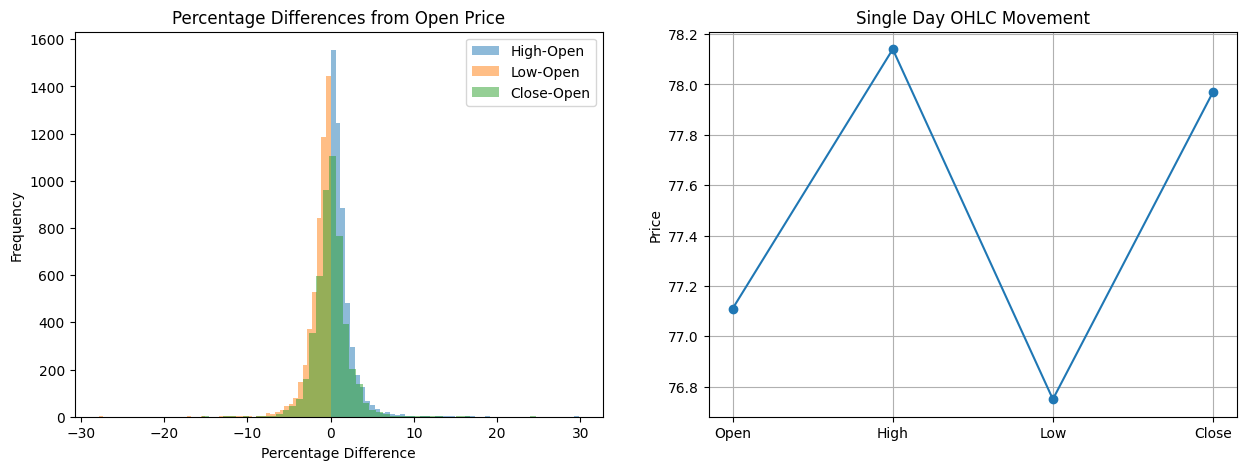

Average percentage differences:
High vs Open: 1.4294%
Low vs Open: -1.4273%
Close vs Open: 0.0583%

Price order statistics:
High is higher than Open: 100.00% of the time
High is higher than Close: 100.00% of the time
Low is lower than Open: 100.00% of the time
Low is lower than Close: 100.00% of the time


In [13]:
# Cell 2: Look at relative differences
# Take a sample of sequences to see OHLC relationships better
sample_size = 1000
sample_idx = np.random.choice(len(training_data), sample_size)
sample_data = training_data[sample_idx]

# Calculate percentage differences
high_open_diff = ((sample_data[:,:,1] - sample_data[:,:,0]) / sample_data[:,:,0]) * 100  # High vs Open
low_open_diff = ((sample_data[:,:,2] - sample_data[:,:,0]) / sample_data[:,:,0]) * 100   # Low vs Open
close_open_diff = ((sample_data[:,:,3] - sample_data[:,:,0]) / sample_data[:,:,0]) * 100 # Close vs Open

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.hist(high_open_diff.flatten(), bins=50, alpha=0.5, label='High-Open')
plt.hist(low_open_diff.flatten(), bins=50, alpha=0.5, label='Low-Open')
plt.hist(close_open_diff.flatten(), bins=50, alpha=0.5, label='Close-Open')
plt.title('Percentage Differences from Open Price')
plt.xlabel('Percentage Difference')
plt.ylabel('Frequency')
plt.legend()

# Look at a single day's OHLC movement
plt.subplot(1, 2, 2)
day_idx = 0
plt.plot(['Open', 'High', 'Low', 'Close'], sample_data[0, day_idx, :4], marker='o')
plt.title(f'Single Day OHLC Movement')
plt.ylabel('Price')
plt.grid(True)
plt.show()

print("Average percentage differences:")
print(f"High vs Open: {high_open_diff.mean():.4f}%")
print(f"Low vs Open: {low_open_diff.mean():.4f}%")
print(f"Close vs Open: {close_open_diff.mean():.4f}%")

# Show how often High is highest and Low is lowest
high_is_highest = (sample_data[:,:,1] >= sample_data[:,:,0]).mean() * 100
high_vs_close = (sample_data[:,:,1] >= sample_data[:,:,3]).mean() * 100
low_is_lowest = (sample_data[:,:,2] <= sample_data[:,:,0]).mean() * 100
low_vs_close = (sample_data[:,:,2] <= sample_data[:,:,3]).mean() * 100

print("\nPrice order statistics:")
print(f"High is higher than Open: {high_is_highest:.2f}% of the time")
print(f"High is higher than Close: {high_vs_close:.2f}% of the time")
print(f"Low is lower than Open: {low_is_lowest:.2f}% of the time")
print(f"Low is lower than Close: {low_vs_close:.2f}% of the time")

In [14]:
training_data.shape

(370440, 5, 501)

In [15]:
# for i, col in enumerate(column_names):
#     prices = ohlc_data[:, i]
#     display(prices[prices < 0])

In [16]:
stock_data['MMM'].head(2)

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,148.561874,150.510040,148.110367,150.501678,4307633
2020-01-03,148.010040,149.381271,146.847824,149.205688,2950412


Price statistics by column:

Open:
Min: $1.58
Max: $5977.61
Mean: $151.18
Median: $95.93
95th percentile: $403.33
99th percentile: $728.99

High:
Min: $1.70
Max: $5982.45
Mean: $153.22
Median: $97.28
95th percentile: $408.77
99th percentile: $737.03

Low:
Min: $1.58
Max: $5884.06
Mean: $149.09
Median: $94.55
95th percentile: $397.89
99th percentile: $719.72

Close:
Min: $1.60
Max: $5959.33
Mean: $151.17
Median: $95.92
95th percentile: $403.39
99th percentile: $728.50


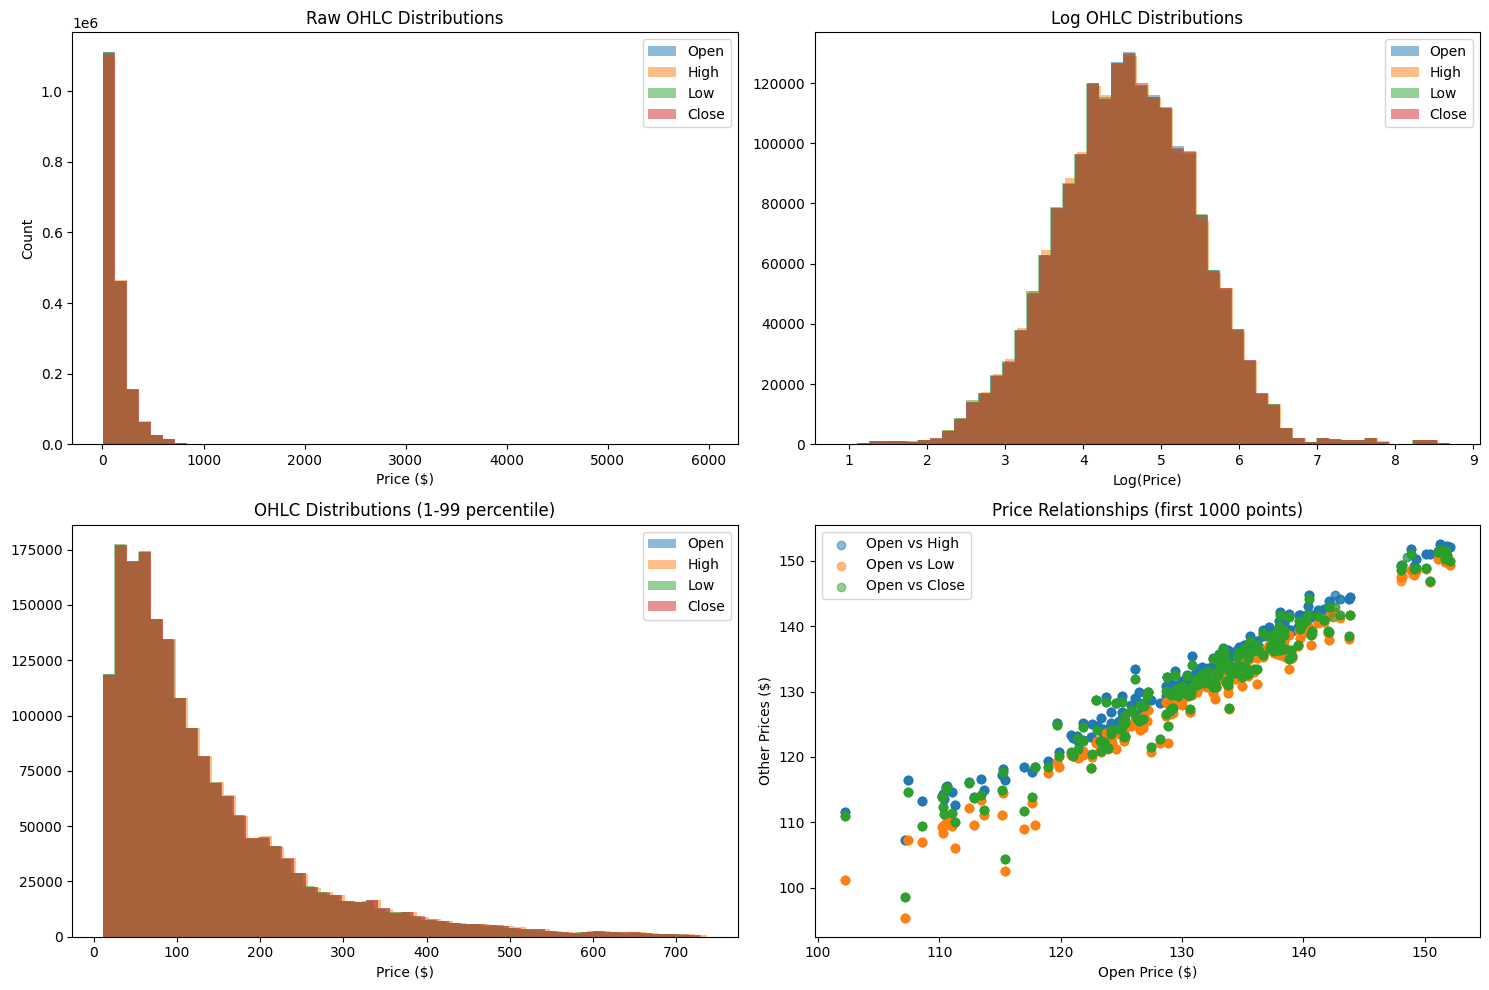


OHLC Correlations:
           Open      High       Low     Close
Open   1.000000  0.999887  0.999880  0.999765
High   0.999887  1.000000  0.999840  0.999888
Low    0.999880  0.999840  1.000000  0.999889
Close  0.999765  0.999888  0.999889  1.000000


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming `training_data` contains the OHLCV data
# Get OHLC prices from the first 4 columns (adjust if necessary)
ohlc_data = training_data.reshape(-1, training_data.shape[2])[:, :4]  # First 4 columns are OHLC
column_names = ['Open', 'High', 'Low', 'Close']

# Basic statistics for each column
print("Price statistics by column:")
for i, col in enumerate(column_names):
    prices = ohlc_data[:, i]
    # prices = prices[np.isfinite(prices) & (prices > 0)]  # Filter non-finite or non-positive values
    print(f"\n{col}:")
    print(f"Min: ${np.min(prices):.2f}")
    print(f"Max: ${np.max(prices):.2f}")
    print(f"Mean: ${np.mean(prices):.2f}")
    print(f"Median: ${np.median(prices):.2f}")
    print(f"95th percentile: ${np.percentile(prices, 95):.2f}")
    print(f"99th percentile: ${np.percentile(prices, 99):.2f}")

# Plot distributions
plt.figure(figsize=(15, 10))

# Raw distributions
plt.subplot(2, 2, 1)
for i, col in enumerate(column_names):
    plt.hist(ohlc_data[:, i][np.isfinite(ohlc_data[:, i])], bins=50, alpha=0.5, label=col)
plt.title('Raw OHLC Distributions')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.legend()

# Log distributions (filter non-positive values)
plt.subplot(2, 2, 2)
for i, col in enumerate(column_names):
    log_prices = np.log1p(ohlc_data[:, i])  # Filter to positive values only
    plt.hist(log_prices, bins=50, alpha=0.5, label=col)
plt.title('Log OHLC Distributions')
plt.xlabel('Log(Price)')
plt.legend()

# Cleaned distributions (1-99 percentile)
plt.subplot(2, 2, 3)
for i, col in enumerate(column_names):
    prices = ohlc_data[:, i]
    lower = np.percentile(prices, 1)
    upper = np.percentile(prices, 99)
    clean_prices = prices[(prices >= lower) & (prices <= upper)]
    plt.hist(clean_prices, bins=50, alpha=0.5, label=col)
plt.title('OHLC Distributions (1-99 percentile)')
plt.xlabel('Price ($)')
plt.legend()

# Price relationships
plt.subplot(2, 2, 4)
plt.scatter(ohlc_data[:1000, 0], ohlc_data[:1000, 1], alpha=0.5, label='Open vs High')
plt.scatter(ohlc_data[:1000, 0], ohlc_data[:1000, 2], alpha=0.5, label='Open vs Low')
plt.scatter(ohlc_data[:1000, 0], ohlc_data[:1000, 3], alpha=0.5, label='Open vs Close')
plt.title('Price Relationships (first 1000 points)')
plt.xlabel('Open Price ($)')
plt.ylabel('Other Prices ($)')
plt.legend()

plt.tight_layout()
plt.show()

# Check correlations between OHLC
valid_ohlc_data = ohlc_data[np.all(np.isfinite(ohlc_data), axis=1)]  # Filter valid rows for correlation
corr_matrix = np.corrcoef(valid_ohlc_data.T)
print("\nOHLC Correlations:")
print(pd.DataFrame(corr_matrix, columns=column_names, index=column_names))


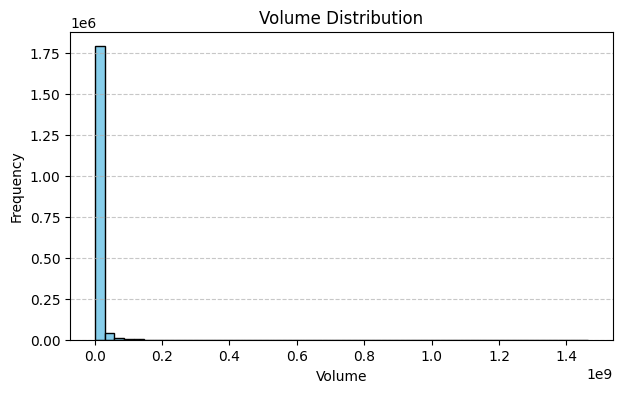

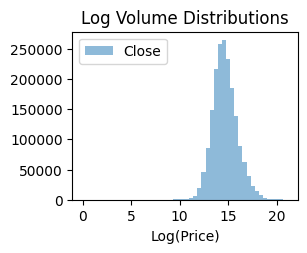

In [18]:
volume_data = training_data[:, :, 4].flatten()  # Flatten to 1D array for plotting

# Plot the distribution
plt.figure(figsize=(7, 4))
plt.hist(volume_data, bins=50, color='skyblue', edgecolor='black')
plt.title('Volume Distribution')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Log distributions (filter non-positive values)
plt.subplot(2, 2, 2)
# for i, col in enumerate(column_names):
log_prices = np.log1p(volume_data)  # Filter to positive values only
plt.hist(log_prices, bins=50, alpha=0.5, label=col)
plt.title('Log Volume Distributions')
plt.xlabel('Log(Price)')
plt.legend()

In [19]:
# import numpy as np
# from typing import Tuple, Dict

# def normalize_financial_sequences_fast(data: np.ndarray) -> Tuple[np.ndarray, Dict]:
#     """
#     Vectorized normalization of financial sequence data.
#     """
#     normalized = np.copy(data)
    
#     # Get dimensions
#     num_tickers = data.shape[2] - 17  # 5 (OHLCV) + 5 (days) + 7 (metrics)
    
#     # 1. OHLCV normalization (first 5 columns)
#     # Log transform
#     ohlc_data = data[:, :, :4]
#     volume_data = data[:, :, 4]
    
#     log_ohlc = np.log(ohlc_data + 1e-8)
#     log_volume = np.log(volume_data + 1e-8)
    
#     # Normalize OHLC (all at once)
#     ohlc_median = np.median(log_ohlc.reshape(-1))
#     q75_ohlc, q25_ohlc = np.percentile(log_ohlc.reshape(-1), [75, 25])
#     iqr_ohlc = q75_ohlc - q25_ohlc + 1e-8
#     norm_ohlc = (log_ohlc - ohlc_median) / iqr_ohlc
    
#     # Normalize volume (all at once)
#     vol_median = np.median(log_volume.reshape(-1))
#     q75_vol, q25_vol = np.percentile(log_volume.reshape(-1), [75, 25])
#     iqr_vol = q75_vol - q25_vol + 1e-8
#     norm_volume = (log_volume - vol_median) / iqr_vol
    
#     # Preserve OHLC relationships using vectorized operations
#     high_vals = np.maximum(norm_ohlc[:, :, 0], 
#                           np.maximum(norm_ohlc[:, :, 1], 
#                                    norm_ohlc[:, :, 3]))
#     low_vals = np.minimum(norm_ohlc[:, :, 0], 
#                          np.minimum(norm_ohlc[:, :, 2], 
#                                   norm_ohlc[:, :, 3]))
    
#     norm_ohlc[:, :, 1] = high_vals + 1e-8
#     norm_ohlc[:, :, 2] = low_vals - 1e-8
    
#     # Store normalized values
#     normalized[:, :, :4] = np.clip(norm_ohlc, -3, 3)
#     normalized[:, :, 4] = np.clip(norm_volume, -3, 3)
    
#     # 2. One-hot encodings stay as is
    
#     # 3. Additional metrics (clip outliers)
#     metrics_start = 5 + num_tickers + 5
#     normalized[:, :, metrics_start:] = np.clip(data[:, :, metrics_start:], -3, 3)
    
#     feature_info = {
#         'shape': normalized.shape,
#         'features': {
#             'ohlcv': slice(0, 5),
#             'ticker_encoding': slice(5, 5 + num_tickers),
#             'day_encoding': slice(5 + num_tickers, 5 + num_tickers + 5),
#             'metrics': slice(5 + num_tickers + 5, None)
#         }
#     }
    
#     return normalized, feature_info

# import numpy as np
# from typing import Tuple, Dict

# import numpy as np
# from typing import Tuple, Dict

# def normalize_financial_sequences_fast(data: np.ndarray) -> Tuple[np.ndarray, Dict]:
#     """
#     Normalizes financial sequence data without clipping or log scaling for robustness.
#     """
#     # Clone data to prevent modifying the original
#     normalized = np.copy(data)

#     # Define indices for the different feature sections
#     metrics_dim = 7
#     ohlcv_dim = 5  # Open, High, Low, Close, Volume
#     cyclical_day_dim = 2 
#     ticker_dim = data.shape[2] - (metrics_dim + cyclical_day_dim + ohlcv_dim)  # Adjust dynamically based on data structure

#     # Calculate indices dynamically based on structure
#     ohlcv_indices = slice(0, ohlcv_dim)
#     ticker_indices = slice(ohlcv_dim, ohlcv_dim + ticker_dim)
#     cyclical_day_indices = slice(ohlcv_dim + ticker_dim, ohlcv_dim + ticker_dim + cyclical_day_dim)
#     metrics_indices = slice(ohlcv_dim + ticker_dim + cyclical_day_dim, None)
    
#     # Normalize OHLCV
#     ohlc_data = normalized[:, :, :4]  # OHLC data
#     volume_data = normalized[:, :, 4]  # Volume data
    
#     # Robust normalization for OHLC
#     ohlc_median = np.median(ohlc_data.reshape(-1))
#     q75_ohlc, q25_ohlc = np.percentile(ohlc_data.reshape(-1), [75, 25])
#     iqr_ohlc = q75_ohlc - q25_ohlc
#     norm_ohlc = (ohlc_data - ohlc_median) / (iqr_ohlc if iqr_ohlc != 0 else 1)
    
#     # Robust normalization for volume
#     vol_median = np.median(volume_data)
#     q75_vol, q25_vol = np.percentile(volume_data, [75, 25])
#     iqr_vol = q75_vol - q25_vol
#     norm_volume = (volume_data - vol_median) / (iqr_vol if iqr_vol != 0 else 1)
    
#     normalized[:, :, :4] = norm_ohlc
#     normalized[:, :, 4] = norm_volume

#     # Keep cyclical day encoding as is
#     normalized[:, :, cyclical_day_indices] = data[:, :, cyclical_day_indices]
    
#     # Robust normalization for metrics without log transformation
#     additional_metrics = data[:, :, metrics_indices]
#     metrics_median = np.median(additional_metrics, axis=(0, 1))
#     metrics_iqr = np.percentile(additional_metrics, 75, axis=(0, 1)) - np.percentile(additional_metrics, 25, axis=(0, 1))
#     metrics_iqr[metrics_iqr == 0] = 1  # Prevent division by zero
#     normalized[:, :, metrics_indices] = (additional_metrics - metrics_median) / metrics_iqr
    
#     # Define feature information for indexing
#     feature_info = {
#         'shape': normalized.shape,
#         'features': {
#             'ohlcv': ohlcv_indices,
#             'ticker_encoding': ticker_indices,
#             'day_encoding': cyclical_day_indices,
#             'metrics': metrics_indices
#         }
#     }
    
#     return normalized, feature_info

# Testing the function with your actual data
# normalized_data, feature_info = normalize_financial_sequences_fast(training_data)

# Quick verification
# print("Normalized data shape:", normalized_data.shape)
# print("Feature info:", feature_info)
# print("\nValue ranges:")
# print("OHLCV:", normalized_data[:, :, ohlcv_indices].min(), "-", normalized_data[:, :, ohlcv_indices].max())
# print("Cyclical day encoding (sin):", normalized_data[:, :, cyclical_day_indices].min(), "-", normalized_data[:, :, cyclical_day_indices].max())
# print("Metrics:", normalized_data[:, :, metrics_indices].min(), "-", normalized_data[:, :, metrics_indices].max())



# Testing the function (replace `training_data` with your actual data)
# normalized_data, feature_info = normalize_financial_sequences_fast(training_data)


# print("Normalized data shape:", normalized_data.shape)
# print("Feature info:", feature_info)

# print("\nValue ranges:")
# print("OHLCV:", normalized_data[:, :, :5].min(), "-", normalized_data[:, :, :5].max())
# print("One-hot encodings:", 
#       normalized_data[:, :, 5:5+num_tickers+5].min(), "-", 
#       normalized_data[:, :, 5:5+num_tickers+5].max())
# print("Additional metrics:", 
#       normalized_data[:, :, -7:].min(), "-", 
#       normalized_data[:, :, -7:].max())

In [20]:
# import numpy as np
# from typing import Tuple, Dict

# def normalize_financial_sequences(data: np.ndarray) -> Tuple[np.ndarray, Dict]:
#     """
#     Normalizes financial sequence data with robust input handling.
#     Expected input: (samples, sequence_length, features)
#     """
#     # Input validation and reshaping if needed
#     if not isinstance(data, np.ndarray):
#         raise TypeError(f"Expected numpy array, got {type(data)}")
    
#     # Print input shape for debugging
#     print("Input data shape:", data.shape)
    
#     # Ensure 3D array
#     if len(data.shape) < 3:
#         raise ValueError(f"Expected 3D array (samples, sequence_length, features), got shape {data.shape}")
    
#     normalized = np.copy(data)
#     samples, seq_len, features = data.shape
    
#     print(f"Processing data with dimensions:")
#     print(f"- Samples: {samples}")
#     print(f"- Sequence length: {seq_len}")
#     print(f"- Features: {features}")
    
#     # OHLC normalization (first 4 features)
#     if features >= 4:
#         prices = normalized[..., :4]
#         log_prices = np.log1p(prices)
#         prices_median = np.median(log_prices, axis=(0, 1), keepdims=True)
#         prices_std = np.std(log_prices, axis=(0, 1), keepdims=True)
#         normalized[..., :4] = (log_prices - prices_median) / np.maximum(prices_std, 1e-6)
    
#     # Volume normalization (5th feature)
#     if features >= 5:
#         volume = normalized[..., 4:5]
#         log_volume = np.log1p(volume)
#         vol_median = np.median(log_volume, axis=(0, 1), keepdims=True)
#         vol_q75 = np.percentile(log_volume, 75, axis=(0, 1), keepdims=True)
#         vol_q25 = np.percentile(log_volume, 25, axis=(0, 1), keepdims=True)
#         vol_iqr = np.maximum(vol_q75 - vol_q25, 1e-6)
#         normalized[..., 4:5] = (log_volume - vol_median) / vol_iqr * 2.0
    
#     feature_info = {
#         'shape': normalized.shape,
#         'features': {
#             'ohlc': slice(0, 4) if features >= 4 else None,
#             'volume': slice(4, 5) if features >= 5 else None,
#             'other': slice(5, None) if features > 5 else None
#         }
#     }
    
#     return normalized, feature_info

# def print_detailed_stats(data: np.ndarray, feature_info: Dict):
#     """
#     Print detailed statistics for each feature group.
#     """
#     def get_stats(x, name):
#         if x is None or x.size == 0:
#             return
#         print(f"\n{name} statistics:")
#         print(f"Shape: {x.shape}")
#         print(f"Range: {x.min():.4f} to {x.max():.4f}")
#         print(f"Mean: {x.mean():.4f}")
#         print(f"Std: {x.std():.4f}")
#         print(f"25th percentile: {np.percentile(x, 25):.4f}")
#         print(f"75th percentile: {np.percentile(x, 75):.4f}")
    
#     # Get feature slices safely
#     features = feature_info['features']
    
#     if features['ohlc'] is not None:
#         get_stats(data[..., features['ohlc']], "OHLC")
    
#     if features['volume'] is not None:
#         get_stats(data[..., features['volume']], "Volume")
    
#     if features['other'] is not None:
#         get_stats(data[..., features['other']], "Other features")

# # Run normalization with proper error handling
# try:
#     normalized_data, feature_info = normalize_financial_sequences(training_data)
#     print_detailed_stats(normalized_data, feature_info)
# except Exception as e:
#     print(f"Error processing data: {str(e)}")
#     print("Please ensure training_data is a 3D numpy array with shape (samples, sequence_length, features)")

In [21]:
import numpy as np
from typing import Tuple, Dict

def normalize_financial_sequences(data: np.ndarray) -> Tuple[np.ndarray, Dict]:
    """
    Optimized normalization of financial sequences.
    """
    print(f"Input data shape: {data.shape}")
    normalized = np.copy(data)
    
    # Get dimensions
    n_samples, seq_length, total_features = data.shape
    ohlcv_dim = 5
    cyclical_day_dim = 2
    ticker_dim = total_features - (ohlcv_dim + cyclical_day_dim)
    
    print(f"Feature breakdown:")
    print(f"- OHLCV features: {ohlcv_dim}")
    print(f"- Ticker features: {ticker_dim}")
    print(f"- Day encoding features: {cyclical_day_dim}")
    
    # 1. Normalize OHLC (first 4 features)
    prices = data[..., :4]
    log_prices = np.log1p(np.maximum(prices, 1e-8))
    prices_median = np.median(log_prices, axis=(0, 1), keepdims=True)
    prices_std = np.std(log_prices, axis=(0, 1), keepdims=True)
    normalized[..., :4] = (log_prices - prices_median) / np.maximum(prices_std, 1e-8)
    
    # 2. Normalize Volume (5th feature)
    volume = data[..., 4:5]
    log_volume = np.log1p(np.maximum(volume, 1e-8))
    vol_median = np.median(log_volume, axis=(0, 1), keepdims=True)
    vol_std = np.std(log_volume, axis=(0, 1), keepdims=True)
    normalized[..., 4:5] = (log_volume - vol_median) / np.maximum(vol_std, 1e-8)
    
    # Store normalization parameters
    norm_params = {
        'prices_median': prices_median,
        'prices_std': prices_std,
        'volume_median': vol_median,
        'volume_std': vol_std
    }
    
    feature_info = {
        'shape': normalized.shape,
        'features': {
            'ohlc': slice(0, 4),
            'volume': slice(4, 5),
            'ticker': slice(5, 5 + ticker_dim),
            'day': slice(-2, None)
        },
        'norm_params': norm_params
    }
    
    # Print only essential statistics
    print("\nNormalized data statistics:")
    print("OHLC range:", normalized[..., :4].min(), "to", normalized[..., :4].max())
    print("Volume range:", normalized[..., 4:5].min(), "to", normalized[..., 4:5].max())
    print("Ticker range:", normalized[..., 5:5+ticker_dim].min(), "to", normalized[..., 5:5+ticker_dim].max())
    print("Day encoding range:", normalized[..., -2:].min(), "to", normalized[..., -2:].max())
    
    return normalized, feature_info

def denormalize_financial_sequences(normalized_data: np.ndarray, feature_info: Dict) -> np.ndarray:
    """
    Denormalize the sequences back to original scale.
    """
    denormalized = np.copy(normalized_data)
    norm_params = feature_info['norm_params']
    
    # Denormalize OHLC
    denormalized[..., :4] = norm_params['prices_std'] * normalized_data[..., :4] + norm_params['prices_median']
    denormalized[..., :4] = np.expm1(denormalized[..., :4])
    
    # Denormalize Volume
    denormalized[..., 4:5] = norm_params['volume_std'] * normalized_data[..., 4:5] + norm_params['volume_median']
    denormalized[..., 4:5] = np.expm1(denormalized[..., 4:5])
    
    return denormalized

# Usage:
normalized_data, feature_info = normalize_financial_sequences(training_data)

Input data shape: (370440, 5, 501)
Feature breakdown:
- OHLCV features: 5
- Ticker features: 494
- Day encoding features: 2

Normalized data statistics:
OHLC range: -3.978269763266716 to 4.523124081173589
Volume range: -11.424845455648306 to 5.1217506273890665
Ticker range: 0.0 to 1.0
Day encoding range: -0.9510565162951536 to 1.0


In [22]:
stats_norm = {
    'min': np.min(normalized_data[:, :, :5], axis=(0, 1)),
    'max': np.max(normalized_data[:, :, :5], axis=(0, 1)),
    'mean': np.mean(normalized_data[:, :, :5], axis=(0, 1)),
    'median': np.median(normalized_data[:, :, :5], axis=(0, 1)),
    'std': np.std(normalized_data[:, :, :5], axis=(0, 1))
}

# Print statistics
print("\nNormalized data statistics:")
for i, name in enumerate(['Open', 'High', 'Low', 'Close', 'Volume']):
    print(f"\n{name}:")
    print(f"Min: {stats_norm['min'][i]:.3f}")
    print(f"Max: {stats_norm['max'][i]:.3f}")
    print(f"Mean: {stats_norm['mean'][i]:.3f}")
    print(f"Median: {stats_norm['median'][i]:.3f}")
    print(f"Std: {stats_norm['std'][i]:.3f}")


Normalized data statistics:

Open:
Min: -3.978
Max: 4.523
Mean: -0.002
Median: 0.000
Std: 1.000

High:
Min: -3.951
Max: 4.516
Mean: -0.001
Median: 0.000
Std: 1.000

Low:
Min: -3.958
Max: 4.514
Mean: -0.002
Median: 0.000
Std: 1.000

Close:
Min: -3.971
Max: 4.519
Mean: -0.002
Median: 0.000
Std: 1.000

Volume:
Min: -11.425
Max: 5.122
Mean: 0.068
Median: 0.000
Std: 1.000


Data structure:
Full data shape: (370440, 5, 501)
Sample shape: (10000, 5, 501)

First 3 sequences:
[[[ 2.73543314  2.72453368  2.71515484 ...  0.         -0.58778525
   -0.80901699]
  [ 2.70687343  2.71379458  2.71398123 ...  0.         -0.95105652
    0.30901699]
  [ 2.7109007   2.70737657  2.71248853 ...  0.          0.
    1.        ]
  [ 2.70444992  2.69471606  2.69730128 ...  0.          0.95105652
    0.30901699]
  [ 2.69344828  2.7185648   2.70449901 ...  0.          0.58778525
   -0.80901699]]

 [[ 0.8967132   0.88996058  0.90325706 ...  0.          0.
    1.        ]
  [ 0.90040701  0.88806812  0.89548907 ...  0.          0.95105652
    0.30901699]
  [ 0.8895899   0.87860665  0.889245   ...  0.          0.58778525
   -0.80901699]
  [ 0.89651313  0.886372    0.90370931 ...  0.         -0.58778525
   -0.80901699]
  [ 0.89566264  0.89452899  0.90611826 ...  0.         -0.95105652
    0.30901699]]

 [[-2.0585701  -2.05212945 -2.05865217 ...  0.          0.58778525
   -0.80901699]

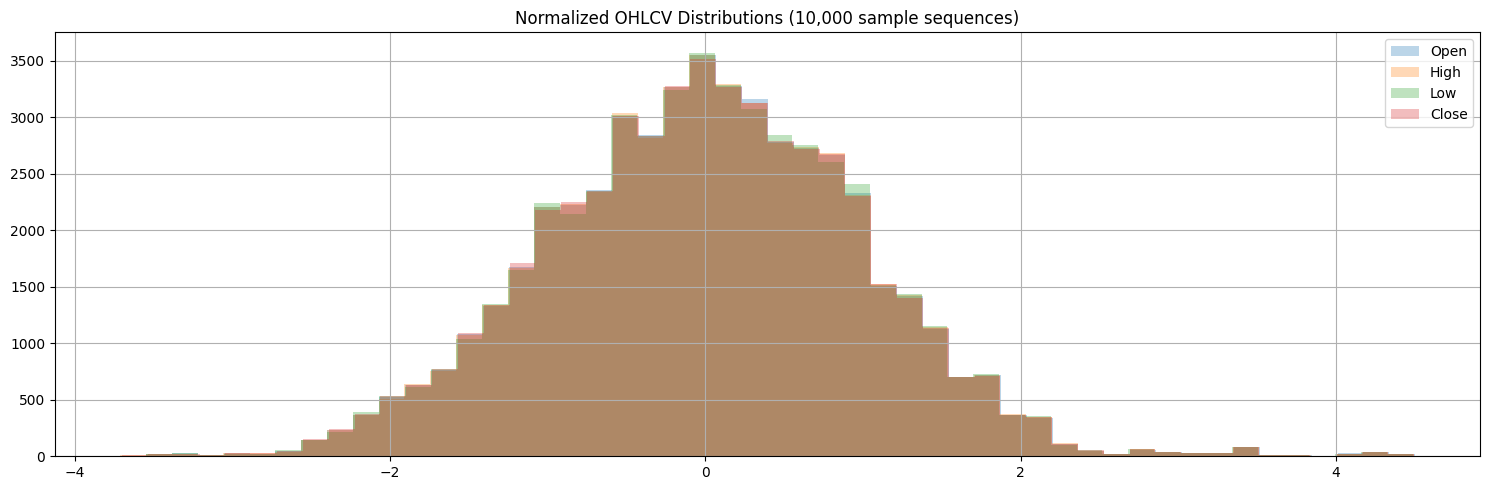


Normalized data statistics (from sample):

Open:
Min: -3.712
Max: 4.503
Mean: -0.001
Std: 0.998

High:
Min: -3.714
Max: 4.498
Mean: -0.001
Std: 0.998

Low:
Min: -3.709
Max: 4.487
Mean: -0.002
Std: 0.998

Close:
Min: -3.699
Max: 4.493
Mean: -0.001
Std: 0.998

Volume:
Min: -4.494
Max: 4.935
Mean: 0.078
Std: 1.004

OHLC relationship violations in sample: 9997 out of 10000
Violation rate: 99.97%


In [23]:
# Cell to analyze normalized data structure - optimized version
import numpy as np
import matplotlib.pyplot as plt

# Take a sample for faster visualization
sample_size = 10000
random_indices = np.random.choice(len(normalized_data), sample_size, replace=False)
sample_data = normalized_data[random_indices]

print("Data structure:")
print(f"Full data shape: {normalized_data.shape}")
print(f"Sample shape: {sample_data.shape}")
print("\nFirst 3 sequences:")
print(sample_data[:3])

# Vectorized OHLC relationship check
def check_ohlc_relationships(data):
    high_vs_open = (data[:, :, 1] >= data[:, :, 0]).all(axis=1)
    high_vs_close = (data[:, :, 1] >= data[:, :, 3]).all(axis=1)
    low_vs_open = (data[:, :, 2] <= data[:, :, 0]).all(axis=1)
    low_vs_close = (data[:, :, 2] <= data[:, :, 3]).all(axis=1)
    
    violations = np.sum(~(high_vs_open & high_vs_close & low_vs_open & low_vs_close))
    return violations

# Fast statistics calculation
stats = {
    'min': np.min(sample_data[:, :, :5], axis=(0, 1)),
    'max': np.max(sample_data[:, :, :5], axis=(0, 1)),
    'mean': np.mean(sample_data[:, :, :5], axis=(0, 1)),
    'std': np.std(sample_data[:, :, :5], axis=(0, 1))
}

# Plot distributions using sample
plt.figure(figsize=(15, 5))

# OHLCV distributions
for i, name in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.hist(sample_data[:, :, i].flatten(), 
            bins=50, alpha=0.3, label=name)
plt.title('Normalized OHLCV Distributions (10,000 sample sequences)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print statistics
print("\nNormalized data statistics (from sample):")
for i, name in enumerate(['Open', 'High', 'Low', 'Close', 'Volume']):
    print(f"\n{name}:")
    print(f"Min: {stats['min'][i]:.3f}")
    print(f"Max: {stats['max'][i]:.3f}")
    print(f"Mean: {stats['mean'][i]:.3f}")
    print(f"Std: {stats['std'][i]:.3f}")

# Check OHLC relationships on sample
violations = check_ohlc_relationships(sample_data)
print(f"\nOHLC relationship violations in sample: {violations} out of {len(sample_data)}")
print(f"Violation rate: {(violations/len(sample_data))*100:.2f}%")

In [24]:

# # Assuming `normalized_data` is already loaded and has the required day, OHLCV, ticker, and metric features

# # Create clock encoding for 5-day trading cycle
# days = np.arange(5)
# angles = 2 * np.pi * days / 5
# clock_encodings = np.column_stack([np.sin(angles), np.cos(angles)])

# # Initialize new array for the full dataset with the desired 508 features
# new_features = 508
# num_samples = normalized_data.shape[0]
# converted_data = np.zeros((num_samples, 5, new_features))

# # Copy unchanged parts directly to `converted_data`
# converted_data[:, :, :5] = normalized_data[:, :, :5]  # OHLCV
# converted_data[:, :, 5:499] = normalized_data[:, :, 5:499]  # Ticker
# converted_data[:, :, 501:] = normalized_data[:, :, 504:511]  # Metrics

# # Convert day encoding for all sequences in the full dataset
# day_indices = np.argmax(normalized_data[:, :, 499:504], axis=2)
# converted_data[:, :, 499:501] = clock_encodings[day_indices]

# print("Converted data shape:", converted_data.shape)


The discriminator takes sequences with the same format as the real and generated sequences from our generator (shape (32, 5, 508)). It will progressively reduce this to a single probability that represents the likelihood of the sequence being real.

In [25]:
# # Defining core dimensions
# batch_size = 64            # Number of samples per training batch
# sequence_length = 5        # Number of days in each sequence
# feature_dim = 508          # Total features per day in your data
# target_output_dim = sequence_length * feature_dim  # Final flattened output dimension
# noise_dim = 200            # Dimensionality of the input noise vector for the generator
# hidden_dim1 = 256          # First hidden layer dimension, chosen to increase feature representation capacity
# hidden_dim2 = 512          # Second hidden layer dimension for further expansion

# # Generate random noise input for the generator
# noise = torch.randn(batch_size, noise_dim)
# print("Noise shape:", noise.shape)  # Expected: (32, 100)
# print("Sample noise values (first sequence):", noise[0][:5])  # Displaying first 5 values

# input_dim_generator = feature_dim + noise_dim  # 508 real features + 200 noise dimensions = 708
# W1 = torch.nn.Parameter(torch.randn(input_dim_generator, hidden_dim1) / np.sqrt(input_dim_generator))  # Adjust W1 size

# # Initialize weights and biases for the first layer (noise_dim -> hidden_dim1)
# W1 = torch.randn(noise_dim, hidden_dim1) / np.sqrt(noise_dim)  # Xavier initialization
# b1 = torch.zeros(hidden_dim1, requires_grad=True)

# # Apply linear transformation and add bias
# hidden1 = torch.matmul(noise, W1) + b1
# print("\nFirst hidden layer shape:", hidden1.shape)  # Expected shape: (32, 256)
# print("Sample hidden values before activation:", hidden1[0][:5])

# # Apply LeakyReLU activation to introduce non-linearity
# hidden1_activated = torch.where(hidden1 > 0, hidden1, 0.2 * hidden1)
# print("\nSample hidden values after LeakyReLU activation:", hidden1_activated[0][:5])

# # Second layer transformation: hidden_dim1 -> hidden_dim2
# W2 = torch.randn(hidden_dim1, hidden_dim2) / np.sqrt(hidden_dim1)  # Xavier initialization
# b2 = torch.zeros(hidden_dim2)

# # Forward pass through the second layer
# hidden2 = torch.matmul(hidden1_activated, W2) + b2
# print("\nBefore batch normalization, first few values:", hidden2[0][:5])

# # Compute mean and variance for batch normalization
# batch_mean = hidden2.mean(dim=0)
# batch_var = hidden2.var(dim=0, unbiased=False)
# epsilon = 1e-5  # Small number for stability

# # Normalize `hidden2` based on batch statistics
# hidden2_normalized = (hidden2 - batch_mean) / torch.sqrt(batch_var + epsilon)
# gamma = torch.ones(hidden_dim2)  # Learnable scale
# beta = torch.zeros(hidden_dim2)  # Learnable shift
# hidden2_normalized = gamma * hidden2_normalized + beta

# # Apply LeakyReLU activation
# hidden2_activated = torch.where(hidden2_normalized > 0, hidden2_normalized, 0.2 * hidden2_normalized)
# print("\nAfter LeakyReLU, first few values:", hidden2_activated[0][:5])
# # Final layer transformation: hidden_dim2 -> (sequence_length * feature_dim)
# W3 = torch.randn(hidden_dim2, sequence_length * feature_dim) / np.sqrt(hidden_dim2)  # Adjusted to match target shape
# b3 = torch.zeros(sequence_length * feature_dim, requires_grad=True)  # Match dimensions

# # Linear transformation to generate output with correct feature dimensions
# output = torch.matmul(hidden2_activated, W3) + b3
# print("\nBefore tanh, first sequence values:", output[0][:5])

# # Apply tanh and reshape to (batch_size, sequence_length, feature_dim)
# final_output = torch.tanh(output).reshape(batch_size, sequence_length, feature_dim)
# print("\nAfter tanh and reshape, final output shape:", final_output.shape)  # Expected: (64, 5, 508)
# print("\nFirst generated sequence (5 days, 508 features):", final_output[0])

# # Reshape to (batch_size, sequence_length, feature_dim) directly, no target_output_dim
# # final_output = final_output.reshape(batch_size, sequence_length, feature_dim)
# # print("\nReshaped output shape:", final_output.shape)  # Expected: (64, 5, 508)
# # print("\nFirst generated sequence (5 days, 508 features):")
# # print(final_output[0])


# # Define discriminator dimensions
# input_dim = feature_dim  # 508 features per day from our data
# sequence_length = 5      # 5 days per sequence
# hidden_dim1_disc = 256   # Hidden dimension for first layer
# hidden_dim2_disc = 128   # Hidden dimension for second layer
# output_dim = 1           # Final output dimension for probability (real or fake)

# # The first layer of the discriminator will apply a linear transformation and activation across each of the 5 days in each sequence.
# # Initialize weights and biases for the first discriminator layer
# W1_disc = torch.randn(input_dim, hidden_dim1_disc) / np.sqrt(input_dim)
# b1_disc = torch.zeros(hidden_dim1_disc)

# # Reshape the batch of sequences for linear transformation (32 * 5, 508)
# disc_input = final_output.reshape(-1, input_dim)  # Reshape to process each day independently

# # Forward pass through first discriminator layer
# hidden1_disc = torch.matmul(disc_input, W1_disc) + b1_disc
# print("\nFirst discriminator layer output shape (before reshape):", hidden1_disc.shape)  # Expected: (160, 256)

# # Apply LeakyReLU activation
# hidden1_disc_activated = torch.where(hidden1_disc > 0, hidden1_disc, 0.2 * hidden1_disc)
# print("First discriminator layer activated output (first 5 values):", hidden1_disc_activated[0][:5])

# # Reshape back to (batch_size, sequence_length, hidden_dim1_disc)
# hidden1_disc_activated = hidden1_disc_activated.reshape(batch_size, sequence_length, hidden_dim1_disc)
# print("\nFirst discriminator layer output shape (after reshape):", hidden1_disc_activated.shape)  # Expected: (32, 5, 256)

# # Define LSTM parameters for sequence analysis
# lstm_input_dim = hidden_dim1_disc  # Input dimension for LSTM
# hidden_dim_lstm = hidden_dim2_disc  # Output dimension of LSTM

# # Initialize LSTM layer
# lstm = torch.nn.LSTM(input_size=lstm_input_dim, hidden_size=hidden_dim_lstm, batch_first=True)

# # Pass the sequence through the LSTM
# lstm_output, (h_n, c_n) = lstm(hidden1_disc_activated)
# print("\nLSTM output shape:", lstm_output.shape)  # Expected: (32, 5, 128)
# print("LSTM final hidden state (h_n):", h_n.shape)  # Expected: (1, 32, 128)

# # Select the final LSTM hidden state for each sequence (summary of the sequence)
# sequence_summary = h_n.squeeze(0)  # Remove extra dimension, resulting in (32, 128)
# print("\nSequence summary shape (from LSTM hidden state):", sequence_summary.shape)

# # Initialize weights and biases for the output layer
# W3_disc = torch.randn(hidden_dim_lstm, output_dim) / np.sqrt(hidden_dim_lstm)
# b3_disc = torch.zeros(output_dim)

# # Calculate final score for real/fake classification
# disc_output = torch.matmul(sequence_summary, W3_disc) + b3_disc
# print("\nDiscriminator raw output (pre-sigmoid):", disc_output.shape)  # Expected shape: (32, 1)
# print("First few discriminator output values (pre-sigmoid):", disc_output[:5])

# # Apply sigmoid to interpret output as probability
# disc_output_prob = torch.sigmoid(disc_output)
# print("\nDiscriminator output (probability of being real):")
# print(disc_output_prob[:5])  # Show probabilities for first 5 sequences

# import torch

# # Assuming `real_sequences` and `fake_sequences` are numpy arrays
# real_sequences = np.random.rand(batch_size, sequence_length, feature_dim)  # Dummy real sequences
# fake_sequences = final_output.detach().numpy()  # Convert to numpy for this example

# # Convert real and fake sequences to PyTorch tensors
# real_disc_input = torch.tensor(real_sequences.reshape(batch_size * sequence_length, feature_dim), dtype=torch.float32)
# fake_disc_input = torch.tensor(fake_sequences.reshape(batch_size * sequence_length, feature_dim), dtype=torch.float32)

# # Forward pass through first discriminator layer for real sequences
# hidden_real = torch.matmul(real_disc_input, W1_disc) + b1_disc
# hidden_real_activated = torch.where(hidden_real > 0, hidden_real, 0.2 * hidden_real)
# hidden_real_activated = hidden_real_activated.reshape(batch_size, sequence_length, hidden_dim1_disc)

# # Forward pass through first discriminator layer for fake sequences
# hidden_fake = torch.matmul(fake_disc_input, W1_disc) + b1_disc
# hidden_fake_activated = torch.where(hidden_fake > 0, hidden_fake, 0.2 * hidden_fake)
# hidden_fake_activated = hidden_fake_activated.reshape(batch_size, sequence_length, hidden_dim1_disc)

# # LSTM pass for real and fake sequences
# lstm_output_real, (h_n_real, _) = lstm(hidden_real_activated)
# lstm_output_fake, (h_n_fake, _) = lstm(hidden_fake_activated)

# # Sequence summary from LSTM hidden state
# sequence_summary_real = h_n_real.squeeze(0)
# sequence_summary_fake = h_n_fake.squeeze(0)

# # Final layer for probability prediction
# disc_output_real = torch.matmul(sequence_summary_real, W3_disc) + b3_disc
# disc_output_fake = torch.matmul(sequence_summary_fake, W3_disc) + b3_disc

# # Apply sigmoid to interpret output as probability
# disc_output_prob_real = torch.sigmoid(disc_output_real)
# disc_output_prob_fake = torch.sigmoid(disc_output_fake)

# print("\nDiscriminator output (probability of being real) - Real Sequences:")
# print(disc_output_prob_real[:5])  # Show probabilities for real sequences

# print("\nDiscriminator output (probability of being real) - Fake Sequences:")
# print(disc_output_prob_fake[:5])  # Show probabilities for fake sequences


In [26]:

# import torch
# import torch.nn.functional as F
# import torch.optim as optim
# import numpy as np

# # Core dimensions
# batch_size = 64
# sequence_length = 5
# feature_dim = 508  # We need 508 features per day in each sequence
# noise_dim = 200
# hidden_dim1 = 256
# hidden_dim2 = 512

# # Generator weights (use W1_noise for noise-only and W1_full for concatenated real features + noise)
# W1_noise = torch.nn.Parameter(torch.randn(noise_dim, hidden_dim1) / np.sqrt(noise_dim))  # Noise input only
# b1_noise = torch.nn.Parameter(torch.zeros(hidden_dim1))

# # Adjusted to match final feature_dim
# W2 = torch.nn.Parameter(torch.randn(hidden_dim1, hidden_dim2) / np.sqrt(hidden_dim1))
# b2 = torch.nn.Parameter(torch.zeros(hidden_dim2))

# # This is the output layer, which should match `feature_dim` (508)
# W3 = torch.nn.Parameter(torch.randn(hidden_dim2, feature_dim) / np.sqrt(hidden_dim2))  # Now outputting 508 features per day
# b3 = torch.nn.Parameter(torch.zeros(feature_dim))

# # Generator weights for concatenated input inside the function (real features + noise)
# input_dim_generator_full = feature_dim + noise_dim  # 508 + 200 = 708
# W1_full = torch.nn.Parameter(torch.randn(input_dim_generator_full, hidden_dim1) / np.sqrt(input_dim_generator_full))
# b1_full = torch.nn.Parameter(torch.zeros(hidden_dim1))

# # Discriminator weights
# hidden_dim1_disc = 256
# hidden_dim2_disc = 128
# output_dim = 1

# W1_disc = torch.nn.Parameter(torch.randn(feature_dim, hidden_dim1_disc) / np.sqrt(feature_dim))
# b1_disc = torch.nn.Parameter(torch.zeros(hidden_dim1_disc))

# W3_disc = torch.nn.Parameter(torch.randn(hidden_dim2_disc, output_dim) / np.sqrt(hidden_dim2_disc))
# b3_disc = torch.nn.Parameter(torch.zeros(output_dim))

# # LSTM layer for discriminator
# lstm = torch.nn.LSTM(input_size=hidden_dim1_disc, hidden_size=hidden_dim2_disc, batch_first=True)

# # Optimizers
# learning_rate_gen = 0.0006
# learning_rate_disc = 0.0001
# disc_optimizer = optim.Adam([W1_disc, b1_disc, W3_disc, b3_disc] + list(lstm.parameters()), lr=learning_rate_disc)
# gen_optimizer = optim.Adam([W1_noise, b1_noise, W1_full, b1_full, W2, b2, W3, b3], lr=learning_rate_gen)

# batch_size = 64
# sequence_length = 5
# feature_dim = 501  # Changed from 508 to 501 to match your data
# noise_dim = 200
# hidden_dim1 = 256
# hidden_dim2 = 512

# # Feature dimensions breakdown
# ohlcv_dim = 5
# ticker_dim = 494
# cyclical_day_dim = 2

# # Activation adjustments for different feature groups
# def generator_output_activation(x, feature_info):
#     """Custom activation for different feature groups"""
#     output = torch.zeros_like(x)
    
#     # OHLC: tanh * 4.5 to match your range (-4 to 4.5)
#     output[..., :4] = torch.tanh(x[..., :4]) * 4.5
    
#     # Volume: tanh * 11.5 to match your range (-11.4 to 5.1)
#     output[..., 4:5] = torch.tanh(x[..., 4:5]) * 11.5
    
#     # Ticker: sigmoid for 0-1 range
#     output[..., 5:5+ticker_dim] = torch.sigmoid(x[..., 5:5+ticker_dim])
    
#     # Day encoding: tanh for -1 to 1 range
#     output[..., -2:] = torch.tanh(x[..., -2:])
    
#     return output

# # Modify your generate_sequences_for_stock function
# def generate_sequences_for_stock(full_real_features):
#     batch_size, sequence_length, feature_dim = full_real_features.shape
    
#     # Generate noise
#     noise = torch.randn(batch_size, sequence_length, noise_dim)
    
#     # Concatenate features and noise
#     gen_input = torch.cat((full_real_features, noise), dim=2)
    
#     generated_sequence = []
#     for day in range(sequence_length):
#         day_input = gen_input[:, day, :]
#         hidden1 = F.leaky_relu(torch.matmul(day_input, W1_full) + b1_full)
#         hidden2 = F.leaky_relu(torch.matmul(hidden1, W2) + b2)
#         day_output = torch.matmul(hidden2, W3) + b3  # Remove tanh here
        
#         # Apply custom activation
#         day_output = generator_output_activation(day_output, feature_info)
#         generated_sequence.append(day_output)
    
#     return torch.stack(generated_sequence, dim=1)

# # Training loop setup
# epochs = 2000
# print_interval = 50

# # Sample training loop
# for epoch in range(epochs):
#     # Select a batch of real sequences from the dataset
#     # Assuming `converted_data` is the full dataset with all 508 features as per feature_info structure

#     # Set up start and end indices for training data
#     start_index = (epoch * batch_size) % (normalized_data.shape[0] - batch_size)
#     end_index = start_index + batch_size

#     # Extract a batch of real sequences with all required features
#     real_sequences = torch.tensor(normalized_data[start_index:end_index], dtype=torch.float32)  # Shape: (batch_size, sequence_length, feature_dim)
#     # print("Real sequences shape:", real_sequences.shape)  # Expected: (batch_size, sequence_length, feature_dim)

#     # Generate fake sequences using real features as input
#     generated_sequences = generate_sequences_for_stock(real_sequences)
#     # print("Generated sequences shape after function:", generated_sequences.shape)  # Should match real_sequences shape for comparison

#     # ----------- Train Discriminator -----------
#     real_disc_input = real_sequences.reshape(batch_size * sequence_length, feature_dim)
#     fake_disc_input = generated_sequences.reshape(batch_size * sequence_length, feature_dim)
    
#     # Forward pass through discriminator
#     hidden_real = F.leaky_relu(torch.matmul(real_disc_input, W1_disc) + b1_disc)
#     hidden_real = hidden_real.reshape(batch_size, sequence_length, hidden_dim1_disc)
#     hidden_fake = F.leaky_relu(torch.matmul(fake_disc_input, W1_disc) + b1_disc)
#     hidden_fake = hidden_fake.reshape(batch_size, sequence_length, hidden_dim1_disc)

#     lstm_output_real, (h_n_real, _) = lstm(hidden_real)
#     lstm_output_fake, (h_n_fake, _) = lstm(hidden_fake)
    
#     sequence_summary_real = h_n_real.squeeze(0)
#     sequence_summary_fake = h_n_fake.squeeze(0)
    
#     disc_output_real = torch.sigmoid(torch.matmul(sequence_summary_real, W3_disc) + b3_disc)
#     disc_output_fake = torch.sigmoid(torch.matmul(sequence_summary_fake, W3_disc) + b3_disc)
    
#     real_labels = torch.ones(disc_output_real.shape)
#     fake_labels = torch.zeros(disc_output_fake.shape)
    
#     real_loss = F.binary_cross_entropy(disc_output_real, real_labels)
#     fake_loss = F.binary_cross_entropy(disc_output_fake, fake_labels)
#     disc_loss = real_loss + fake_loss

#     disc_optimizer.zero_grad()
#     disc_loss.backward(retain_graph=True)
#     disc_optimizer.step()
    
#     # ----------- Train Generator -----------
#     generated_sequences = generate_sequences_for_stock(real_sequences)
    
#     fake_disc_input = generated_sequences.reshape(batch_size * sequence_length, feature_dim)
#     hidden_fake = F.leaky_relu(torch.matmul(fake_disc_input, W1_disc) + b1_disc)
#     hidden_fake = hidden_fake.reshape(batch_size, sequence_length, hidden_dim1_disc)
    
#     lstm_output_fake, (h_n_fake, _) = lstm(hidden_fake)
#     sequence_summary_fake = h_n_fake.squeeze(0)
    
#     disc_output_fake = torch.sigmoid(torch.matmul(sequence_summary_fake, W3_disc) + b3_disc)
#     gen_loss = F.binary_cross_entropy(disc_output_fake, real_labels)
    
#     gen_optimizer.zero_grad()
#     gen_loss.backward()
#     gen_optimizer.step()
    
#     if (epoch + 1) % print_interval == 0:
#         print(f"Epoch [{epoch + 1}/{epochs}], Discriminator Loss: {disc_loss.item():.4f}, Generator Loss: {gen_loss.item():.4f}")


In [27]:

# import torch
# import torch.nn.functional as F
# import torch.optim as optim
# import numpy as np

# # Core dimensions
# batch_size = 64
# sequence_length = 5
# feature_dim = 501
# noise_dim = 200
# hidden_dim1 = 256
# hidden_dim2 = 512

# # Dimensions breakdown
# ohlcv_dim = 5
# ticker_dim = 494
# cyclical_day_dim = 2

# # Training parameters
# learning_rate_gen = 0.0002
# learning_rate_disc = 0.0001
# lambda_gp = 10.0  # Gradient penalty coefficient
# feature_matching_weight = 0.1

# # Initialize weights with better scaling
# def init_weights(shape, scale=0.02):
#     return torch.nn.Parameter(torch.randn(*shape) * scale)

# # Generator weights
# W1_full = init_weights((feature_dim + noise_dim, hidden_dim1))
# b1_full = init_weights((hidden_dim1,))

# W2 = init_weights((hidden_dim1, hidden_dim2))
# b2 = init_weights((hidden_dim2,))

# W3 = init_weights((hidden_dim2, feature_dim))
# b3 = init_weights((feature_dim,))

# # Discriminator weights
# hidden_dim1_disc = 256
# hidden_dim2_disc = 128
# output_dim = 1

# W1_disc = init_weights((feature_dim, hidden_dim1_disc))
# b1_disc = init_weights((hidden_dim1_disc,))

# W3_disc = init_weights((hidden_dim2_disc, output_dim))
# b3_disc = init_weights((output_dim,))

# # LSTM layer for discriminator
# lstm = torch.nn.LSTM(input_size=hidden_dim1_disc, hidden_size=hidden_dim2_disc, batch_first=True)

# # Optimizers
# disc_optimizer = optim.Adam(
#     [W1_disc, b1_disc, W3_disc, b3_disc] + list(lstm.parameters()), 
#     lr=learning_rate_disc, 
#     betas=(0.5, 0.999)
# )
# gen_optimizer = optim.Adam(
#     [W1_full, b1_full, W2, b2, W3, b3], 
#     lr=learning_rate_gen, 
#     betas=(0.5, 0.999)
# )

# def generator_output_activation(x):
#     """Custom activation for different feature groups"""
#     output = torch.zeros_like(x)
    
#     # OHLC: tanh * 4.5
#     output[..., :4] = torch.tanh(x[..., :4]) * 4.5
    
#     # Volume: tanh * 11.5
#     output[..., 4:5] = torch.tanh(x[..., 4:5]) * 11.5
    
#     # Ticker: sigmoid
#     output[..., 5:5+ticker_dim] = torch.sigmoid(x[..., 5:5+ticker_dim])
    
#     # Day encoding: tanh
#     output[..., -2:] = torch.tanh(x[..., -2:])
    
#     return output

# def gradient_penalty(discriminator_output, real_data, generated_data):
#     """Calculate gradient penalty for WGAN-GP with correct dimensions"""
#     batch_size = real_data.size(0)
    
#     # Create alpha with correct shape
#     alpha = torch.rand(batch_size, 1).to(real_data.device)
#     alpha = alpha.expand(batch_size, real_data.size(1))
    
#     # Interpolate between real and generated data
#     interpolated = alpha * real_data + (1 - alpha) * generated_data
#     interpolated.requires_grad_(True)
    
#     # Calculate discriminator output and features for interpolated data
#     disc_interpolated, _ = discriminator_output(interpolated)
    
#     # Calculate gradients
#     gradients = torch.autograd.grad(
#         outputs=disc_interpolated,
#         inputs=interpolated,
#         grad_outputs=torch.ones_like(disc_interpolated),
#         create_graph=True,
#         retain_graph=True
#     )[0]
    
#     # Calculate gradient penalty
#     gradients = gradients.view(batch_size, -1)
#     gradients_norm = torch.sqrt(torch.sum(gradients ** 2, dim=1) + 1e-12)
#     return ((gradients_norm - 1) ** 2).mean()

# def discriminator_forward(x, add_noise=True):
#     """Discriminator forward pass with noise and reshaping"""
#     batch_size = x.size(0) // sequence_length
    
#     # Add noise if requested
#     if add_noise:
#         noise = torch.randn_like(x) * 0.1
#         x = x + noise
    
#     # First layer
#     hidden = F.leaky_relu(torch.matmul(x, W1_disc) + b1_disc, 0.2)
#     hidden = hidden.reshape(batch_size, sequence_length, hidden_dim1_disc)
    
#     # LSTM layer
#     lstm_out, (h_n, _) = lstm(hidden)
    
#     # Extract features for feature matching
#     features = h_n.squeeze(0)
    
#     # Final layer
#     output = torch.sigmoid(torch.matmul(features, W3_disc) + b3_disc)
    
#     return output, features


# def generate_sequences_for_stock(real_features):
#     """Generate sequences with improved stability"""
#     batch_size = real_features.shape[0]
    
#     # Generate noise
#     # noise = torch.randn(batch_size, sequence_length, noise_dim)
#     noise = torch.randn(batch_size, sequence_length, noise_dim * 2)

    
#     generated_sequence = []
#     for day in range(sequence_length):
#         # Concatenate current day's features with noise
#         day_features = real_features[:, day, :]
#         day_noise = noise[:, day, :]
#         day_input = torch.cat([day_features, day_noise], dim=1)
        
#         # Generator forward pass with layer normalization
#         hidden1 = F.layer_norm(F.leaky_relu(torch.matmul(day_input, W1_full) + b1_full), 
#                              normalized_shape=[hidden_dim1])
#         hidden2 = F.layer_norm(F.leaky_relu(torch.matmul(hidden1, W2) + b2),
#                              normalized_shape=[hidden_dim2])
#         day_output = torch.matmul(hidden2, W3) + b3
        
#         # Apply custom activation
#         day_output = generator_output_activation(day_output)
#         generated_sequence.append(day_output)
    
#     return torch.stack(generated_sequence, dim=1)

# # Training loop
# epochs = 2000
# print_interval = 50
# running_D_loss = []
# running_G_loss = []

# for epoch in range(epochs):
#     # Select batch of real sequences
#     start_idx = (epoch * batch_size) % (normalized_data.shape[0] - batch_size)
#     real_sequences = torch.tensor(normalized_data[start_idx:start_idx + batch_size], dtype=torch.float32)
    
#     # Train Discriminator
#     for _ in range(2):  # Reduced number of D updates for better balance
#         # Generate fake sequences
#         generated_sequences = generate_sequences_for_stock(real_sequences)
#         # print("Generated Open, High, Low (first 3 sequences, 3 days):", generated_sequences[:3, :3, :3])
#         # Reshape sequences for discriminator
#         real_disc_input = real_sequences.reshape(-1, feature_dim)  # Flatten sequences
#         fake_disc_input = generated_sequences.detach().reshape(-1, feature_dim)
        
#         # Get discriminator outputs
#         real_output, real_features = discriminator_forward(real_disc_input)
#         fake_output, fake_features = discriminator_forward(fake_disc_input)
        
#         # Calculate losses
#         gp = gradient_penalty(discriminator_forward, real_disc_input, fake_disc_input)
#         disc_loss = (fake_output.mean() - real_output.mean() + lambda_gp * gp)
        
#         # Update discriminator
#         disc_optimizer.zero_grad()
#         disc_loss.backward()
#         disc_optimizer.step()
    
#     # Train Generator
#     generated_sequences = generate_sequences_for_stock(real_sequences)
#     fake_disc_input = generated_sequences.reshape(-1, feature_dim)
    
#     # Get discriminator outputs for generator training
#     fake_output, fake_features = discriminator_forward(fake_disc_input, add_noise=False)
#     _, real_features = discriminator_forward(real_disc_input, add_noise=False)
    
#     # Calculate generator losses
#     gen_loss = -fake_output.mean()
#     feature_matching_loss = F.mse_loss(fake_features, real_features.detach())
#     total_gen_loss = gen_loss + feature_matching_weight * feature_matching_loss
    
#     # Update generator
#     gen_optimizer.zero_grad()
#     total_gen_loss.backward()
#     gen_optimizer.step()
    
#     # Print progress
#     if (epoch + 1) % print_interval == 0:
#         print("Generated Open, High, Low for first batch sample:")
#         print(generated_sequences[0, :, :3])
#         print(f"Epoch [{epoch + 1}/{epochs}], "
#               f"D Loss: {disc_loss.item():.4f}, "
#               f"G Loss: {total_gen_loss.item():.4f}")
#         running_D_loss.append(disc_loss.item())
#         running_G_loss.append(total_gen_loss.item())

# # Plot training progress
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))
# plt.plot(running_D_loss, label='Discriminator Loss')
# plt.plot(running_G_loss, label='Generator Loss')
# plt.xlabel('Iterations (x50)')
# plt.ylabel('Loss')
# plt.title('Training Progress')
# plt.legend()
# plt.grid(True)
# plt.show()


In [28]:
stock_data['MMM']

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,148.561874,150.510040,148.110367,150.501678,4307633
2020-01-03,148.010040,149.381271,146.847824,149.205688,2950412
2020-01-06,148.118729,149.423080,147.449829,149.347824,2389608
2020-01-07,149.063538,149.255859,147.842804,148.745819,2598908
2020-01-08,148.829437,151.755859,148.536789,151.028427,3298927
...,...,...,...,...,...
2022-12-23,100.994980,101.170570,98.494980,100.451508,3120723
2022-12-27,100.451508,101.028427,99.632111,100.518394,2166195
2022-12-28,100.627090,101.170570,98.871239,98.904678,2345356


In [1]:
"""Main script for training and evaluating Financial GAN."""

import os
from pathlib import Path

# Set the working directory to the root of the project
os.chdir(Path('..').resolve())  # Adjust this path as necessary

import torch
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from src.data.data_loading import (
    get_sp500_tickers, download_stock_data
)
from src.data.data_processing import (
    create_sequences,
    normalize_sequences,
    # denormalize_sequences
)
from src.training.trainer import Trainer
from src.evaluation.metrics import FinancialMetrics
from src.visualization.plots import SequenceVisualizer
from config import Config, setup_logging
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.utils.paths import DIRS

import cProfile
import pstats
from pstats import SortKey
import time

import torch
import numpy as np

# Now you can use DIRS throughout your code
print("Project directories:")
for name, path in DIRS.items():
    print(f"- {name}: {path}")

setup_logging()
logger = logging.getLogger(__name__)

import numpy as np
from typing import Dict, Tuple

sequence_length = 5
# sequence_length = 250

config = Config()
# 1. Data Loading and Processing
print("\n=== Loading Data ===")
tickers = get_sp500_tickers(config)

# Setup profiler
profiler = cProfile.Profile()
profiler.enable()

# Time data loading
data_start = time.time()
# tickers = ['AAPL', 'MMM']
stock_data = download_stock_data(tickers, config)
# stock_data = {key: stock_data[key].head(7) for key in tickers}
# print(stock_data)

import numpy as np
import os

import h5py

# Define paths for HDF5 storage
sequences_hdf5_path = "data/sequences.h5"
normalized_hdf5_path = "data/normalized_data.h5"

import numpy as np
import h5py


# def save_sequences(sequences, ticker_mapping, chunk_size):
#     """Save sequences and ticker mapping using HDF5 with chunking."""
#     with h5py.File(sequences_hdf5_path, "w") as f:
#         # Define dataset with chunking
#         n_samples, seq_length, total_features = sequences.shape
#         dset = f.create_dataset("sequences", data=sequences.shape,
#                                 maxshape=(None, seq_length, total_features),
#                                 chunks=(chunk_size, seq_length, total_features),
#                                 compression="gzip")
#         # Write in chunks
#         for i in range(0, n_samples, chunk_size):
#             end = min(i + chunk_size, n_samples)
#             dset[i:end, :, :] = sequences[i:end]
#             print(f"Saved chunk {i//chunk_size + 1}/{n_samples // chunk_size + 1}")

#         # Save ticker mapping
#         ticker_mapping_group = f.create_group("ticker_mapping")
#         for ticker, idx in ticker_mapping.items():
#             ticker_mapping_group.attrs[ticker] = idx
#     print("Chunked sequences saved to HDF5.")

# def load_sequences():
#     """Load sequences from chunked HDF5 file if available."""
#     if os.path.exists(sequences_hdf5_path):
#         with h5py.File(sequences_hdf5_path, "r") as f:
#             sequences = f["sequences"][:]
#             ticker_mapping = {ticker: idx for ticker, idx in f["ticker_mapping"].attrs.items()}
#         print("Loaded chunked sequences and ticker mapping from HDF5.")
#         return sequences, ticker_mapping
#     else:
#         return None, None

sequences, ticker_mapping = create_sequences(stock_data, sequence_length=sequence_length)

INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/data
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/results
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/checkpoints
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/results/plots
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/results/models
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/logs
INFO:src.data.data_loading:Loaded data for 495 stocks


Project directories:
- data: /Users/lucijagregov/Documents/gan_finance/data
- results: /Users/lucijagregov/Documents/gan_finance/results
- checkpoints: /Users/lucijagregov/Documents/gan_finance/checkpoints
- plots: /Users/lucijagregov/Documents/gan_finance/results/plots
- models: /Users/lucijagregov/Documents/gan_finance/results/models
- logs: /Users/lucijagregov/Documents/gan_finance/logs

=== Loading Data ===
data/stock_data.pkl


Generating sequences: 100%|██████████| 495/495 [00:01<00:00, 295.78it/s]


In [4]:
len(stock_data)

495

In [2]:
sequences.shape

(74385, 5, 502)

In [2]:
import importlib
from src.data import data_processing
importlib.reload(data_processing)

from src.data.data_processing import normalize_with_progress, calculate_global_statistics

# feature_info = calculate_global_statistics(sequences, sample_size=100000)
normalized_data, normalization_params, feature_info = normalize_with_progress(sequences, window_size=5000, sample_size=100000)


Starting normalization of shape (74385, 5, 502)
Starting normalization. Input shape: (74385, 5, 502)


Normalizing: 100%|██████████| 15/15 [00:00<00:00, 36.57it/s]

Normalization completed in 0.84 seconds
Memory usage: 712.23 MB


In [ ]:
normalized_data.shape

Input shapes - Original: (74385, 5, 502), Normalized: (74385, 5, 502)


Processing features: 100%|██████████| 5/5 [00:07<00:00,  1.44s/it]


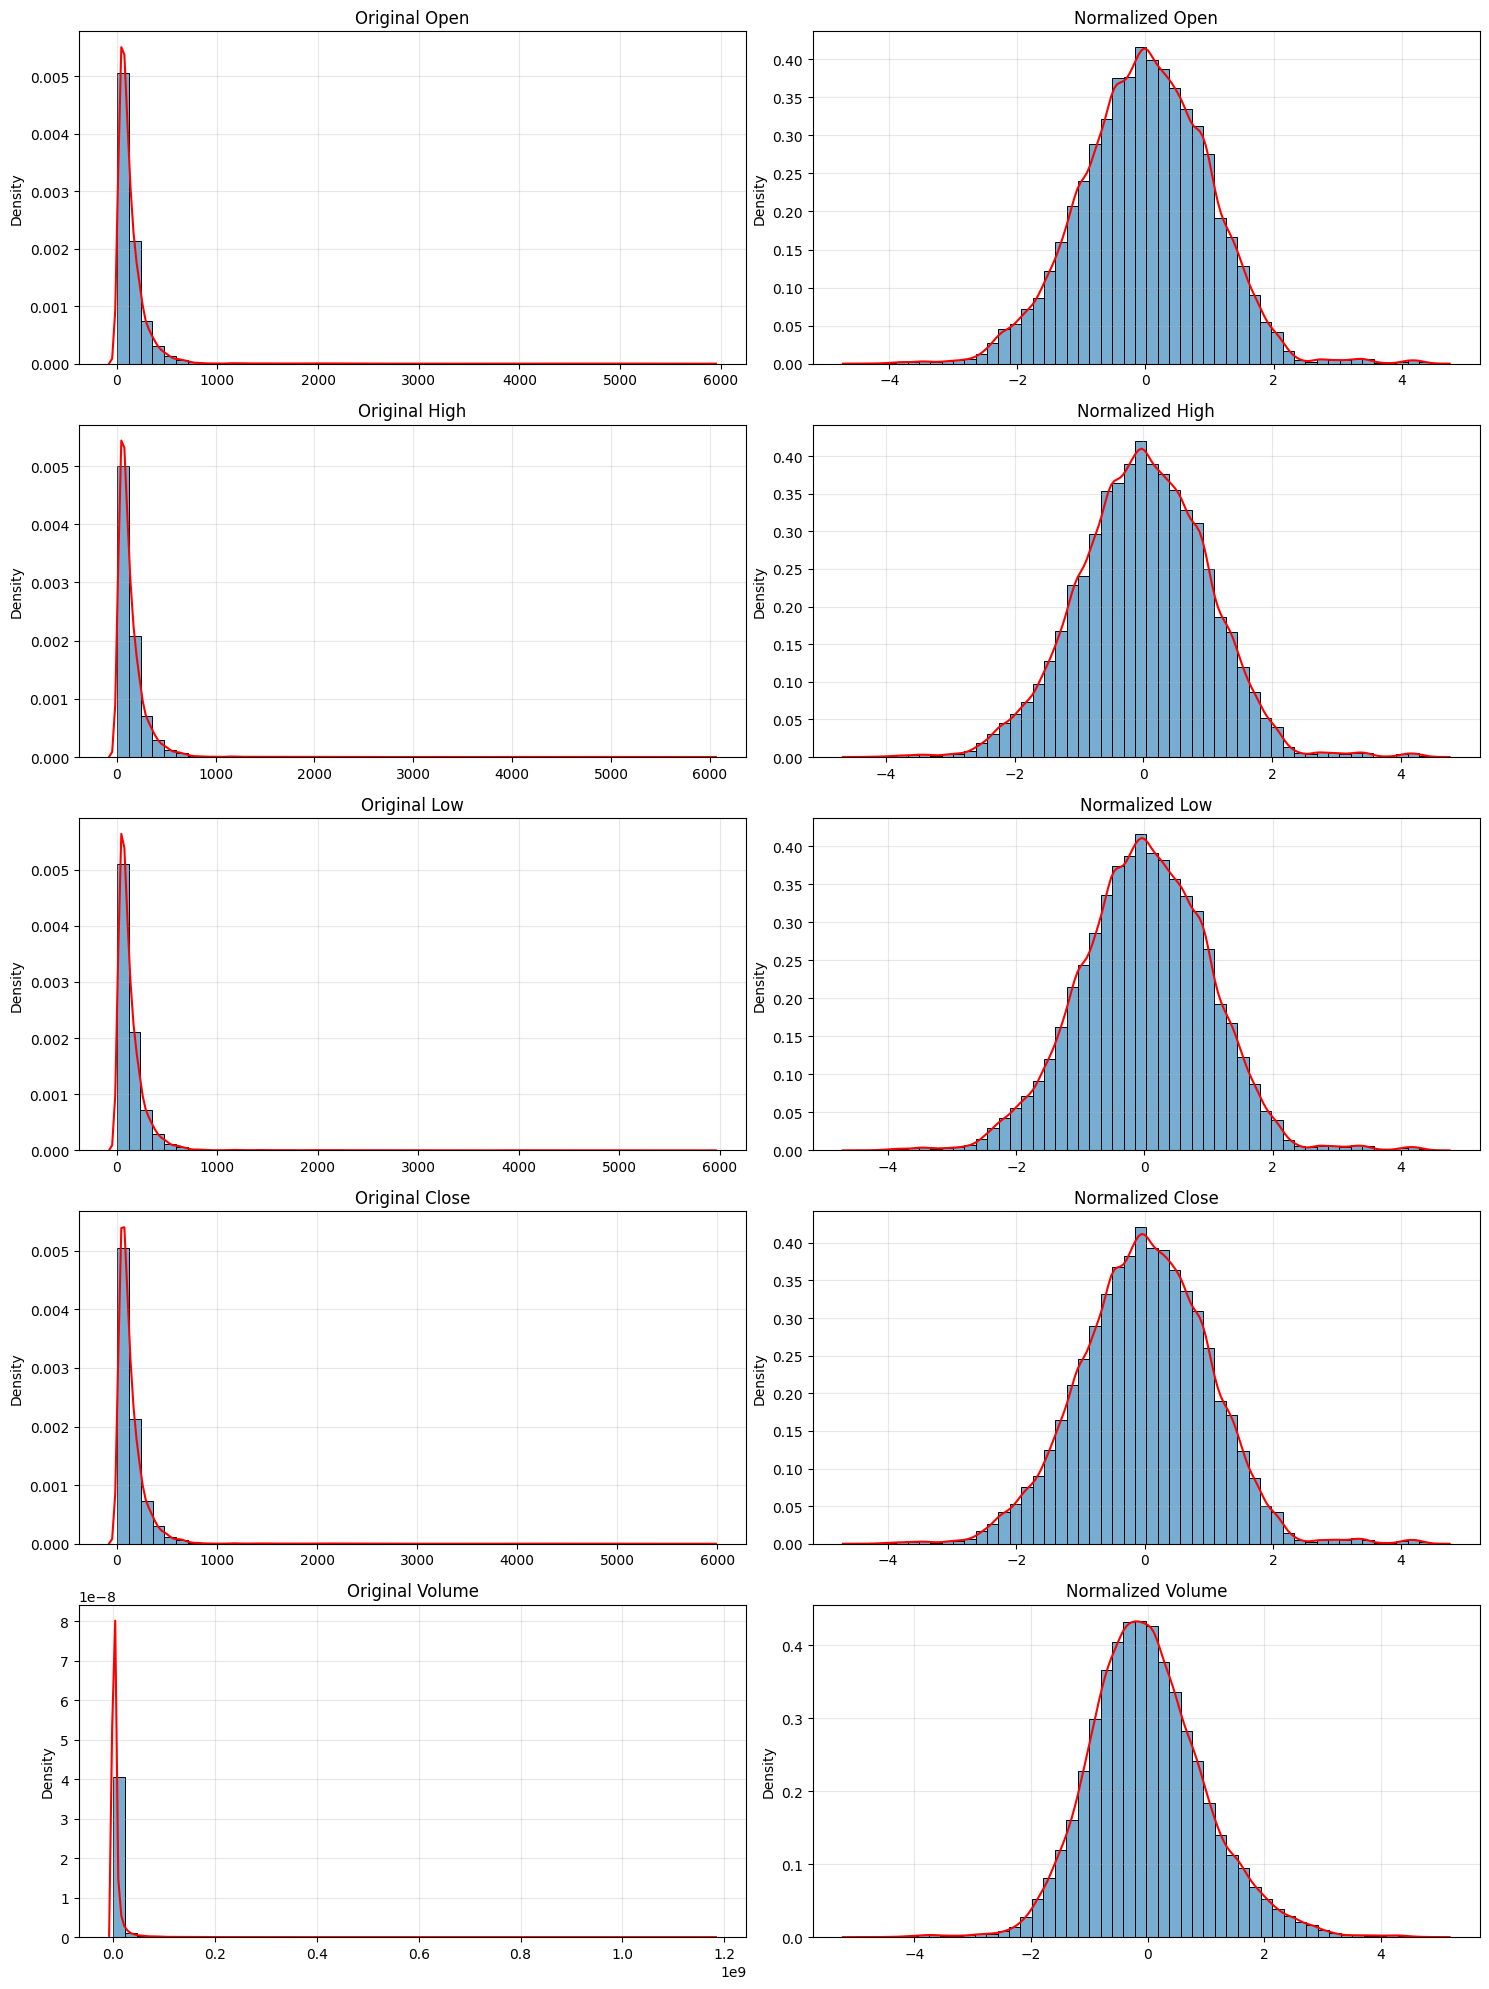


Distribution Statistics Summary:

Open:
----------------------------------------
Original:
  Range: [1.582, 5874.550]
  Mean: 150.905, Std: 256.995
  Percentiles (1%, 99%): [10.900, 721.401]

Normalized:
  Range: [-4.424, 4.451]
  Mean: -0.001, Std: 1.001
  Percentiles (1%, 99%): [-2.340, 2.186]

High:
----------------------------------------
Original:
  Range: [1.699, 5982.450]
  Mean: 153.390, Std: 263.658
  Percentiles (1%, 99%): [11.070, 743.515]

Normalized:
  Range: [-4.371, 4.463]
  Mean: -0.003, Std: 1.004
  Percentiles (1%, 99%): [-2.343, 2.208]

Low:
----------------------------------------
Original:
  Range: [1.576, 5884.060]
  Mean: 149.174, Std: 254.573
  Percentiles (1%, 99%): [10.600, 728.614]

Normalized:
  Range: [-4.403, 4.459]
  Mean: -0.001, Std: 1.002
  Percentiles (1%, 99%): [-2.350, 2.208]

Close:
----------------------------------------
Original:
  Range: [1.610, 5907.370]
  Mean: 151.702, Std: 265.560
  Percentiles (1%, 99%): [11.010, 727.744]

Normalized:
  R

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict
from dataclasses import dataclass
from tqdm import tqdm

@dataclass
class DistributionStats:
    min: float
    max: float
    mean: float
    std: float
    percentiles: Dict[str, float]

def fast_analyze_distributions(
    original_sequences: np.ndarray,
    normalized_sequences: np.ndarray,
    n_features: int = 5,
    batch_size: int = 5000  # Increased batch size
) -> Tuple[Dict[str, DistributionStats], Dict[str, DistributionStats]]:
    """
    High-speed distribution analysis for large sequence datasets.
    """
    print(f"Input shapes - Original: {original_sequences.shape}, Normalized: {normalized_sequences.shape}")
    
    # Pre-flatten the first two dimensions to speed up processing
    orig_flat = original_sequences.reshape(-1, original_sequences.shape[2])
    norm_flat = normalized_sequences.reshape(-1, normalized_sequences.shape[2])
    
    total_samples = len(orig_flat)
    n_features = min(n_features, original_sequences.shape[2])
    
    # Create figure
    fig, axes = plt.subplots(n_features, 2, figsize=(15, 4*n_features))
    if n_features == 1:
        axes = np.array([axes])
    plt.subplots_adjust(hspace=0.4)
    
    # Initialize stats containers
    orig_stats = {}
    norm_stats = {}
    
    feature_names = ['Open', 'High', 'Low', 'Close', 'Volume']
    
    for i in tqdm(range(n_features), desc="Processing features"):
        feature_name = feature_names[i] if i < len(feature_names) else f'Feature_{i}'
        
        # Get random indices for sampling
        sample_indices = np.random.choice(total_samples, size=min(100000, total_samples), replace=False)
        
        # Get samples for current feature
        orig_samples = orig_flat[sample_indices, i]
        norm_samples = norm_flat[sample_indices, i]
        
        # Calculate statistics
        orig_stats[feature_name] = DistributionStats(
            min=np.min(orig_samples),
            max=np.max(orig_samples),
            mean=np.mean(orig_samples),
            std=np.std(orig_samples),
            percentiles={
                '1%': np.percentile(orig_samples, 1),
                '5%': np.percentile(orig_samples, 5),
                '95%': np.percentile(orig_samples, 95),
                '99%': np.percentile(orig_samples, 99)
            }
        )
        
        norm_stats[feature_name] = DistributionStats(
            min=np.min(norm_samples),
            max=np.max(norm_samples),
            mean=np.mean(norm_samples),
            std=np.std(norm_samples),
            percentiles={
                '1%': np.percentile(norm_samples, 1),
                '5%': np.percentile(norm_samples, 5),
                '95%': np.percentile(norm_samples, 95),
                '99%': np.percentile(norm_samples, 99)
            }
        )
        
        # Plot distributions
        sns.histplot(orig_samples, bins=50, ax=axes[i, 0], stat='density', alpha=0.6)
        sns.kdeplot(orig_samples, ax=axes[i, 0], color='red')
        axes[i, 0].set_title(f'Original {feature_name}')
        axes[i, 0].grid(True, alpha=0.3)
        
        sns.histplot(norm_samples, bins=50, ax=axes[i, 1], stat='density', alpha=0.6)
        sns.kdeplot(norm_samples, ax=axes[i, 1], color='red')
        axes[i, 1].set_title(f'Normalized {feature_name}')
        axes[i, 1].grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nDistribution Statistics Summary:")
    print("=" * 80)
    
    for feature_name in list(orig_stats.keys()):
        print(f"\n{feature_name}:")
        print("-" * 40)
        
        orig = orig_stats[feature_name]
        print("Original:")
        print(f"  Range: [{orig.min:.3f}, {orig.max:.3f}]")
        print(f"  Mean: {orig.mean:.3f}, Std: {orig.std:.3f}")
        print(f"  Percentiles (1%, 99%): [{orig.percentiles['1%']:.3f}, {orig.percentiles['99%']:.3f}]")
        
        norm = norm_stats[feature_name]
        print("\nNormalized:")
        print(f"  Range: [{norm.min:.3f}, {norm.max:.3f}]")
        print(f"  Mean: {norm.mean:.3f}, Std: {norm.std:.3f}")
        print(f"  Percentiles (1%, 99%): [{norm.percentiles['1%']:.3f}, {norm.percentiles['99%']:.3f}]")
    
    return orig_stats, norm_stats

def quick_feature_correlations(
    sequences: np.ndarray,
    n_features: int = 5,
    sample_size: int = 100000
) -> None:
    """Quick correlation analysis using sampling."""
    # Flatten and sample
    flat_data = sequences.reshape(-1, sequences.shape[2])
    if len(flat_data) > sample_size:
        indices = np.random.choice(len(flat_data), sample_size, replace=False)
        flat_data = flat_data[indices]
    
    # Calculate correlations for first n_features
    corr_matrix = np.corrcoef(flat_data[:, :n_features].T)
    
    # Plot
    plt.figure(figsize=(10, 8))
    feature_names = ['Open', 'High', 'Low', 'Close', 'Volume']
    sns.heatmap(corr_matrix,
                annot=True,
                fmt='.2f',
                square=True,
                xticklabels=feature_names[:n_features],
                yticklabels=feature_names[:n_features],
                cmap='RdBu',
                center=0)
    plt.title("Feature Correlations (Sampled Data)")
    plt.tight_layout()
    plt.show()


orig_stats, norm_stats = fast_analyze_distributions(
    original_sequences=sequences,
    normalized_sequences=normalized_data,
    n_features=5  # Analyze first 5 features
)

In [8]:
len(tickers)

503

In [5]:
len(stock_data)

495

In [11]:
normalized_data.shape

NameError: name 'normalized_data' is not defined

In [24]:
num_tickers

503

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

# Core dimensions and model parameters optimized for CPU
batch_size = 16  # Reduced batch size for faster CPU training
# sequence_length = 250  # Adjust if possible to further reduce computational load
sequence_length = 5
feature_dim = 502  # Output feature dimensions remain the same
noise_dim = 100  # Reduced noise dimension
transformer_dim = 64  # Smaller transformer dimension for CPU
n_heads = 1  # Reduced number of heads to minimize load
n_layers = 1  # Reduced layers to a single layer for faster computation

# Training hyperparameters
learning_rate_gen = 0.0002
learning_rate_disc = 0.00002
lambda_gp = 5
n_critic = 2

# Loss weights
# temporal_weight = 0.2
# feature_matching_weight = 0.3
# volatility_weight = 0.35
# diversity_loss_weight = 0.5
# consistency_weight = 1.5
feature_matching_weight = 0.3
consistency_weight = 2.0  # Increase for stronger consistency
temporal_weight = 0.2
volatility_weight = 0.4  # Increase slightly for volatility stability
diversity_loss_weight = 0.5

epochs = 500
print_interval = 30

# ====================== Generator Class ======================

class TransformerGenerator(nn.Module):
    def __init__(self, noise_dim: int, feature_dim: int, transformer_dim: int, n_heads: int, n_layers: int, num_tickers: int, ticker_dim: int):
        super(TransformerGenerator, self).__init__()
        self.ticker_embedding_layer = nn.Embedding(num_embeddings=num_tickers, embedding_dim=ticker_dim)  # Ticker embedding layer
        self.input_layer = nn.Linear(noise_dim + feature_dim + 2 + ticker_dim, transformer_dim)  # Adjusted input dimension
        self.transformer = nn.Transformer(
            d_model=transformer_dim, nhead=n_heads, num_encoder_layers=n_layers,
            num_decoder_layers=n_layers, dim_feedforward=128, batch_first=True
        )
        self.output_layer = nn.Linear(transformer_dim, feature_dim)

    def forward(self, noise: torch.Tensor, day_encoding: torch.Tensor, historical_data_summary: torch.Tensor, ticker_embedding: torch.Tensor) -> torch.Tensor:
        x = torch.cat([historical_data_summary, noise, day_encoding, ticker_embedding], dim=2)  # Concatenate ticker_embedding
        x = self.input_layer(x)
        x = self.transformer(x, x)
        output = self.output_layer(x)
        return output




# ====================== Discriminator Class ======================

class LSTMDiscriminator(nn.Module):
    """
    Discriminator model using an LSTM architecture.

    Args:
        feature_dim (int): Dimensionality of the feature space.
        hidden_dim1_disc (int): Dimensionality of the first hidden layer.
        hidden_dim2_disc (int): Dimensionality of the second hidden layer.
    """
    def __init__(self, feature_dim: int, hidden_dim1_disc: int, hidden_dim2_disc: int):
        super(LSTMDiscriminator, self).__init__()
        self.fc1 = nn.Linear(feature_dim, hidden_dim1_disc)
        self.lstm = nn.LSTM(input_size=hidden_dim1_disc, hidden_size=hidden_dim2_disc, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim2_disc, 1)

    def forward(self, x: torch.Tensor, add_noise: bool = True) -> torch.Tensor:
        if add_noise:
            x = x + torch.randn_like(x) * 0.1
        x = F.leaky_relu(self.fc1(x))
        lstm_out, (h_n, _) = self.lstm(x)
        features = h_n.squeeze(0)
        output = torch.sigmoid(self.fc_out(features))
        return output, features

# ====================== Helper Functions ======================

def summarize_historical_data(historical_data: torch.Tensor, window: int = 5) -> torch.Tensor:
    """
    Summarize the last few periods of historical data.

    Args:
        historical_data (torch.Tensor): Input historical data.
        window (int): Number of periods to average over.

    Returns:
        torch.Tensor: Summarized historical data.
    """
    return historical_data[:, -window:, :].mean(dim=1).unsqueeze(1).expand(-1, sequence_length, -1)

def generate_day_encoding(sequence_length: int, batch_size: int) -> torch.Tensor:
    """
    Generate cyclical day encoding for sequences.

    Args:
        sequence_length (int): Length of the sequence.
        batch_size (int): Size of each batch.

    Returns:
        torch.Tensor: Day encoding for each day in the sequence.
    """
    days = np.arange(sequence_length) % 7
    days_rad = days * (2 * np.pi / 7)
    sin_day = np.sin(days_rad)
    cos_day = np.cos(days_rad)
    sin_day_batch = np.tile(sin_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
    cos_day_batch = np.tile(cos_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
    day_encoding = np.concatenate([sin_day_batch, cos_day_batch], axis=2)
    return torch.tensor(day_encoding, dtype=torch.float32)

def gradient_penalty(disc_func, real_data: torch.Tensor, fake_data: torch.Tensor) -> torch.Tensor:
    """
    Calculate gradient penalty for WGAN-GP.

    Args:
        disc_func (nn.Module): Discriminator function.
        real_data (torch.Tensor): Real sequences.
        fake_data (torch.Tensor): Fake sequences.

    Returns:
        torch.Tensor: Gradient penalty term.
    """
    batch_size, seq_len, feature_dim = real_data.shape
    alpha = torch.rand(batch_size, seq_len, feature_dim, requires_grad=True).to(real_data.device)
    interpolated = (alpha * real_data + (1 - alpha) * fake_data).requires_grad_(True)
    disc_interpolates, _ = disc_func(interpolated)
    gradients = torch.autograd.grad(
        outputs=disc_interpolates, inputs=interpolated,
        grad_outputs=torch.ones_like(disc_interpolates),
        create_graph=True, retain_graph=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * lambda_gp
    return gp

def volatility_loss(real_sequences: torch.Tensor, generated_sequences: torch.Tensor, epoch: int, base_smoothing: float = 5e-4) -> torch.Tensor:
    """
    Volatility matching loss between real and generated sequences.

    Args:
        real_sequences (torch.Tensor): Real sequences.
        generated_sequences (torch.Tensor): Generated sequences.
        epoch (int): Current training epoch.
        base_smoothing (float): Smoothing factor for loss.

    Returns:
        torch.Tensor: Volatility loss.
    """
    smoothing_factor = base_smoothing if epoch < 1500 else base_smoothing / 10
    real_returns = torch.diff(real_sequences[..., 3], dim=1)
    gen_returns = torch.diff(generated_sequences[..., 3], dim=1)
    mean_volatility_loss = F.mse_loss(gen_returns.mean(dim=1), real_returns.mean(dim=1))
    variance_volatility_loss = F.mse_loss(gen_returns.std(dim=1), real_returns.std(dim=1))
    return mean_volatility_loss + variance_volatility_loss + smoothing_factor

def diversity_loss(generated_sequences: torch.Tensor) -> torch.Tensor:
    """
    Diversity loss to encourage variance in generated sequences.

    Args:
        generated_sequences (torch.Tensor): Generated sequences.

    Returns:
        torch.Tensor: Diversity loss.
    """
    sequence_var = torch.var(generated_sequences, dim=1)
    return torch.mean(1.0 / (sequence_var + 1e-6))

def price_consistency_loss(sequences: torch.Tensor) -> torch.Tensor:
    """
    Enforce consistency in price sequences.

    Args:
        sequences (torch.Tensor): Price sequences.

    Returns:
        torch.Tensor: Price consistency loss.
    """
    open_price = sequences[..., 0]
    high = sequences[..., 1]
    low = sequences[..., 2]
    high_open_violation = F.relu(open_price - high + 1e-2) ** 2
    open_low_violation = F.relu(low - open_price + 1e-2) ** 2
    return torch.mean(10 * high_open_violation + 10 * open_low_violation)

def temporal_consistency_loss(sequences: torch.Tensor) -> torch.Tensor:
    """
    Enforce temporal consistency by reducing large changes in prices.

    Args:
        sequences (torch.Tensor): Price sequences.

    Returns:
        torch.Tensor: Temporal consistency loss.
    """
    close_prices = sequences[..., 3]
    return torch.mean(torch.abs(torch.diff(close_prices, dim=1)))

def generate_samples(num_samples, ticker_idx):
    """Generate samples for a specific ticker."""
    matching_sequences = []
    ticker_start = ohlcv_dim
    
    for i in range(len(normalized_data)):
        if np.argmax(normalized_data[i, 0, ticker_start:ticker_start + ticker_dim]) == ticker_idx:
            matching_sequences.append(normalized_data[i])
            if len(matching_sequences) >= num_samples:
                break

    if len(matching_sequences) < num_samples:
        print(f"Insufficient matching sequences found for ticker index {ticker_idx}. Needed: {num_samples}, Found: {len(matching_sequences)}")
        return None, None  # Return None if not enough sequences found

    real_sequences = torch.tensor(np.array(matching_sequences), dtype=torch.float32)
    day_encoding = generate_day_encoding(sequence_length, len(matching_sequences))

    # Get the ticker embedding for generation
    ticker_embedding = generator.ticker_embedding_layer(torch.tensor([ticker_idx] * len(matching_sequences), dtype=torch.long)).to(real_sequences.device)
    ticker_embedding = ticker_embedding.unsqueeze(1).expand(-1, sequence_length, -1)

    with torch.no_grad():
        noise = torch.randn(len(matching_sequences), sequence_length, noise_dim).to(real_sequences.device)
        generated = generator(noise, day_encoding, summarize_historical_data(real_sequences), ticker_embedding)

    return generated.numpy(), np.array(matching_sequences)


def generate_sequences_for_stock(real_features):
    """
    Generate synthetic sequences for a specific stock using the Transformer generator.

    Args:
        real_features (torch.Tensor): The real feature data of shape [batch_size, sequence_length, feature_dim].

    Returns:
        torch.Tensor: Generated sequences of shape [batch_size, sequence_length, feature_dim].
    """
    batch_size = real_features.shape[0]
    noise = torch.randn(batch_size, sequence_length, noise_dim)
    day_encoding = generate_day_encoding(sequence_length, batch_size)
    ticker_embedding = ticker_embedding_layer(torch.tensor([ticker_idx] * batch_size).to(real_features.device))
    ticker_embedding = ticker_embedding.unsqueeze(1).expand(-1, sequence_length, -1)  # Adjust shape

    generated_sequence = generator(noise, day_encoding, summarize_historical_data(real_features), ticker_embedding)
    return generated_sequence

def compare_statistics(real, generated, ticker):
    """Compare statistics between real and generated samples, with percentage error"""
    print(f"\nStatistics for {ticker}:")

    # OHLC statistics
    print("\nOHLC Statistics:")
    for i, name in enumerate(['Open', 'High', 'Low', 'Close']):
        real_mean = real[..., i].mean()
        real_std = real[..., i].std()
        gen_mean = generated[..., i].mean()
        gen_std = generated[..., i].std()
        
        mean_error = abs((gen_mean - real_mean) / real_mean) * 100 if real_mean != 0 else float('inf')
        std_error = abs((gen_std - real_std) / real_std) * 100 if real_std != 0 else float('inf')
        
        print(f"\n{name}:")
        print(f"Real - Mean: {real_mean:.4f}, Std: {real_std:.4f}")
        print(f"Generated - Mean: {gen_mean:.4f}, Std: {gen_std:.4f}")
        print(f"Mean Error: {mean_error:.2f}%, Std Error: {std_error:.2f}%")

    # Volume statistics
    real_volume_mean = real[..., 4].mean()
    real_volume_std = real[..., 4].std()
    gen_volume_mean = generated[..., 4].mean()
    gen_volume_std = generated[..., 4].std()
    
    volume_mean_error = abs((gen_volume_mean - real_volume_mean) / real_volume_mean) * 100 if real_volume_mean != 0 else float('inf')
    volume_std_error = abs((gen_volume_std - real_volume_std) / real_volume_std) * 100 if real_volume_std != 0 else float('inf')

    print("\nVolume Statistics:")
    print(f"Real - Mean: {real_volume_mean:.4f}, Std: {real_volume_std:.4f}")
    print(f"Generated - Mean: {gen_volume_mean:.4f}, Std: {gen_volume_std:.4f}")
    print(f"Mean Error: {volume_mean_error:.2f}%, Std Error: {volume_std_error:.2f}%")

    # Daily Returns Statistics
    real_returns = np.diff(real[..., 3], axis=1)
    gen_returns = np.diff(generated[..., 3], axis=1)
    
    real_return_mean = real_returns.mean()
    real_return_std = real_returns.std()
    gen_return_mean = gen_returns.mean()
    gen_return_std = gen_returns.std()
    
    return_mean_error = abs((gen_return_mean - real_return_mean) / real_return_mean) * 100 if real_return_mean != 0 else float('inf')
    return_std_error = abs((gen_return_std - real_return_std) / real_return_std) * 100 if real_return_std != 0 else float('inf')
    
    print("\nDaily Returns Statistics:")
    print(f"Real - Mean: {real_return_mean:.4f}, Std: {real_return_std:.4f}")
    print(f"Generated - Mean: {gen_return_mean:.4f}, Std: {gen_return_std:.4f}")
    print(f"Mean Error: {return_mean_error:.2f}%, Std Error: {return_std_error:.2f}%")

# Ensure that your get_batch_tickers function is returning the correct number of tickers
def get_batch_tickers(start_idx, batch_size, tickers):
    """
    Retrieves the tickers for the sequences in the current batch.

    Args:
        start_idx (int): Starting index for the batch.
        batch_size (int): Size of the batch.
        tickers (list): List of tickers where each entry corresponds to a sequence in normalized_data.

    Returns:
        list: List of tickers for the current batch.
    """
    return tickers[start_idx:start_idx + batch_size] if start_idx + batch_size <= len(stock_data) else []


# ====================== Training Loop ======================

# Initialize generator and discriminator
# generator = TransformerGenerator(noise_dim=noise_dim, feature_dim=feature_dim, transformer_dim=transformer_dim, n_heads=n_heads, n_layers=n_layers)
# Define ticker-specific parameters

# Define the ticker index for evaluation, for example, "AAPL"
ticker = "AAPL"
ticker_to_idx = {ticker: idx for idx, ticker in enumerate(stock_data.keys())}
ticker_idx = ticker_to_idx[ticker]  # Ensure ticker_to_idx and ticker mappings are defined in your code

ohlcv_dim = 5  # Number of OHLCV columns
ticker_dim = len(ticker_to_idx) 

sample_size = 10000
random_indices = np.random.choice(len(normalized_data), sample_size, replace=False)
sample_data = normalized_data[random_indices]

# Define ticker-specific parameters
num_tickers = len(ticker_to_idx)  # Total number of tickers
ticker_dim = 16  # Set ticker embedding dimension

# Initialize the Generator
generator = TransformerGenerator(
    noise_dim=noise_dim,
    feature_dim=feature_dim,
    transformer_dim=transformer_dim,
    n_heads=n_heads,
    n_layers=n_layers,
    num_tickers=num_tickers,
    ticker_dim=ticker_dim
)

# Discriminator
discriminator = LSTMDiscriminator(feature_dim=feature_dim, hidden_dim1_disc=64, hidden_dim2_disc=32)

# Optimizers
disc_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate_disc, betas=(0.5, 0.999))
gen_optimizer = optim.Adam(generator.parameters(), lr=learning_rate_gen, betas=(0.5, 0.999))

# Modify the main training loop to handle cases where batch_tickers might be empty
for epoch in range(epochs):
    start_idx = (epoch * batch_size) % (normalized_data.shape[0] - batch_size)
    real_sequences = torch.tensor(normalized_data[start_idx:start_idx + batch_size, :sequence_length, :], dtype=torch.float32)
    day_encoding = generate_day_encoding(sequence_length, batch_size)
    historical_data_summary = summarize_historical_data(real_sequences)

    # Retrieve batch tickers and convert to indices
    batch_tickers = get_batch_tickers(start_idx, batch_size, tickers)
    print(batch_tickers)
    if len(batch_tickers) < batch_size:
        print(f"Insufficient tickers found for the batch. Needed: {batch_size}, Found: {len(batch_tickers)}")
        continue  # Skip this iteration if not enough tickers

    ticker_indices = torch.tensor([ticker_to_idx[ticker] for ticker in batch_tickers], dtype=torch.long).to(real_sequences.device)
    print(ticker_indices)
    # Generate ticker embeddings for the batch with correct batch size
    ticker_embedding = generator.ticker_embedding_layer(ticker_indices)
    ticker_embedding = ticker_embedding.unsqueeze(1).expand(-1, sequence_length, -1)  # Shape [batch_size, sequence_length, ticker_dim]

    # Confirm all shapes align with batch_size before concatenation
    if ticker_embedding.shape[0] != batch_size:
        print(f"Ticker embedding shape mismatch: Expected batch size {batch_size}, got {ticker_embedding.shape[0]}")
        continue  # Skip this iteration if the sizes don’t match

    # Confirm the shape matches before concatenation
    print(f"Shapes - historical_data_summary: {historical_data_summary.shape}, noise: {noise.shape}, "
          f"day_encoding: {day_encoding.shape}, ticker_embedding: {ticker_embedding.shape}")

    # Generate sequences
    for _ in range(n_critic):
        noise = torch.randn(batch_size, sequence_length, noise_dim).to(real_sequences.device)
        generated_sequences = generator(noise, day_encoding, historical_data_summary, ticker_embedding)
        
        # Discriminator pass
        real_output, real_features = discriminator(real_sequences)
        fake_output, fake_features = discriminator(generated_sequences.detach())
        
        # Loss with gradient penalty
        gp = gradient_penalty(discriminator, real_sequences, generated_sequences.detach())
        disc_loss = fake_output.mean() - real_output.mean() + gp
        disc_optimizer.zero_grad()
        disc_loss.backward()
        disc_optimizer.step()

    # Generator update
    noise = torch.randn(batch_size, sequence_length, noise_dim).to(real_sequences.device)
    generated_sequences = generator(noise, day_encoding, historical_data_summary, ticker_embedding)
    fake_output, fake_features = discriminator(generated_sequences, add_noise=False)
    _, real_features = discriminator(real_sequences, add_noise=False)

    adversarial_loss = -fake_output.mean()
    feature_matching_loss = F.mse_loss(fake_features, real_features.detach())
    consistency_loss = price_consistency_loss(generated_sequences)
    temporal_loss = temporal_consistency_loss(generated_sequences)
    volatility_matching_loss = volatility_loss(real_sequences, generated_sequences, epoch)

    total_gen_loss = (
        adversarial_loss +
        feature_matching_weight * feature_matching_loss +
        consistency_weight * consistency_loss +
        temporal_weight * temporal_loss +
        volatility_weight * volatility_matching_loss +
        diversity_loss_weight * diversity_loss(generated_sequences)
    )

    gen_optimizer.zero_grad()
    total_gen_loss.backward()
    gen_optimizer.step()

    if (epoch + 1) % print_interval == 0:
        print("Generated Open, High, Low, Close, Volume for first sample in batch:")
        print(generated_sequences[0, :, :5])
        print(f"Epoch [{epoch + 1}/{epochs}], "
              f"D Loss: {disc_loss.item():.4f}, "
              f"G Loss: {total_gen_loss.item():.4f}, "
              f"Consistency: {consistency_loss.item():.10f}, "
              f"Volatility: {volatility_matching_loss.item():.10f}")

        # Evaluation check
        generated_samples, real_samples = generate_samples(10, ticker_idx)
        if real_samples is not None and generated_samples is not None:
            print(f"\nEvaluation at Epoch {epoch + 1}:")
            compare_statistics(real_samples, generated_samples, ticker)

# ticker = "AAPL"
# ticker_idx = ticker_to_idx[ticker] 

# # Main training loop
# for epoch in range(epochs):
#     start_idx = (epoch * batch_size) % (normalized_data.shape[0] - batch_size)
#     real_sequences = torch.tensor(normalized_data[start_idx:start_idx + batch_size, :sequence_length, :], dtype=torch.float32)
#     day_encoding = generate_day_encoding(sequence_length, batch_size)
#     historical_data_summary = summarize_historical_data(real_sequences)

#     for _ in range(n_critic):
#         noise = torch.randn(batch_size, sequence_length, noise_dim)
#         generated_sequences = generator(noise, day_encoding, historical_data_summary)
#         real_output, real_features = discriminator(real_sequences)
#         fake_output, fake_features = discriminator(generated_sequences.detach())
#         gp = gradient_penalty(discriminator, real_sequences, generated_sequences.detach())
#         disc_loss = (fake_output.mean() - real_output.mean() + gp)
#         disc_optimizer.zero_grad()
#         disc_loss.backward()
#         disc_optimizer.step()

#     noise = torch.randn(batch_size, sequence_length, noise_dim)
#     generated_sequences = generator(noise, day_encoding, historical_data_summary)
#     fake_output, fake_features = discriminator(generated_sequences, add_noise=False)
#     _, real_features = discriminator(real_sequences, add_noise=False)
#     adversarial_loss = -fake_output.mean()
#     feature_matching_loss = F.mse_loss(fake_features, real_features.detach())
#     consistency_loss = price_consistency_loss(generated_sequences)
#     temporal_loss = temporal_consistency_loss(generated_sequences)
#     volatility_matching_loss = volatility_loss(real_sequences, generated_sequences, epoch)
#     total_gen_loss = (
#         adversarial_loss +
#         feature_matching_weight * feature_matching_loss +
#         consistency_weight * consistency_loss +
#         temporal_weight * temporal_loss +
#         volatility_weight * volatility_matching_loss +
#         diversity_loss_weight * diversity_loss(generated_sequences)
#     )
#     gen_optimizer.zero_grad()
#     total_gen_loss.backward()
#     gen_optimizer.step()

#     if (epoch + 1) % print_interval == 0:
#         # print(f"Epoch [{epoch + 1}/{epochs}], D Loss: {disc_loss.item():.4f}, G Loss: {total_gen_loss.item():.4f}")

#         print("Generated Open, High, Low, Close, Volume for first sample in batch:")
#         print(generated_sequences[0, :, :5])
#         print(f"Epoch [{epoch + 1}/{epochs}], "
#               f"D Loss: {disc_loss.item():.4f}, "
#               f"G Loss: {total_gen_loss.item():.4f}, "
#               f"Consistency: {consistency_loss.item():.10f}, "
#               f"Volatility: {volatility_matching_loss.item():.10f}")


NameError: name 'normalized_data' is not defined

In [ ]:
import numpy as np
import torch

tickers = list(stock_data.keys())
ticker_to_idx = {ticker: idx for idx, ticker in enumerate(tickers)}
num_tickers = len(tickers)

ohlcv_dim = 5  # Number of OHLCV columns
ticker_dim = len(ticker_to_idx)  # Total number of unique tickers




# Compare statistics with percentage error


# Example usage and check
ticker = "AAPL"  # Example ticker
ticker_idx = ticker_to_idx[ticker]
generated_samples, real_samples = generate_samples(10, ticker_idx)

if real_samples is not None and generated_samples is not None:
    compare_statistics(real_samples, generated_samples, ticker)
else:
    print("No samples available for comparison.")


In [15]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# import numpy as np
# from tqdm import tqdm
# import gc

# # Model parameters
# batch_size = 32  # Increased for better training
# sequence_length = 250  # Keep your original sequence length
# feature_dim = 502  # Your original feature dimension
# noise_dim = 100
# hidden_dim = 256
# transformer_dim = 256
# n_heads = 4
# n_layers = 2

# # Training hyperparameters
# learning_rate_gen = 0.0001
# learning_rate_disc = 0.00001
# lambda_gp = 10
# n_critic = 2

# # Loss weights
# feature_matching_weight = 0.3
# consistency_weight = 1.0
# temporal_weight = 0.2
# volatility_weight = 0.35
# diversity_loss_weight = 0.5

# class TransformerGenerator(nn.Module):
#     def __init__(self, noise_dim, feature_dim, transformer_dim, n_heads, n_layers):
#         super(TransformerGenerator, self).__init__()
#         self.input_layer = nn.Linear(noise_dim + 2, transformer_dim)
        
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=transformer_dim,
#             nhead=n_heads,
#             dim_feedforward=transformer_dim * 4,
#             dropout=0.1,
#             batch_first=True
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
#         self.output_layer = nn.Linear(transformer_dim, feature_dim)
        
#     def forward(self, noise, day_encoding):
#         x = torch.cat([noise, day_encoding], dim=2)
#         x = self.input_layer(x)
#         x = self.transformer(x)
#         x = self.output_layer(x)
#         return self.output_activation(x)
    
#     def output_activation(self, x):
#         # Separate activation for different components
#         ohlc = torch.tanh(x[..., :4]) * 3.5
#         volume = torch.tanh(x[..., 4:5]) * 10
#         categorical = torch.tanh(x[..., 5:])
#         return torch.cat([ohlc, volume, categorical], dim=-1)

# class LSTMDiscriminator(nn.Module):
#     def __init__(self, feature_dim, hidden_dim):
#         super(LSTMDiscriminator, self).__init__()
#         self.feature_dim = feature_dim
        
#         self.conv = nn.Conv1d(feature_dim, hidden_dim, 1)
#         self.lstm = nn.LSTM(
#             input_size=hidden_dim,
#             hidden_size=hidden_dim // 2,
#             num_layers=2,
#             batch_first=True,
#             bidirectional=True,
#             dropout=0.1
#         )
#         self.fc_out = nn.Linear(hidden_dim, 1)
        
#     def forward(self, x, add_noise=True):
#         if add_noise:
#             x = x + torch.randn_like(x) * 0.05
        
#         # Process with 1D convolution
#         x = x.transpose(1, 2)
#         x = F.leaky_relu(self.conv(x))
#         x = x.transpose(1, 2)
        
#         # LSTM processing
#         lstm_out, (h_n, _) = self.lstm(x)
#         features = torch.cat([h_n[-2], h_n[-1]], dim=1)
        
#         return self.fc_out(features), features

# def generate_day_encoding(sequence_length, batch_size):
#     days = np.arange(sequence_length) % 5  # Trading days
#     angles = 2 * np.pi * days / 5
#     sin_encoding = np.sin(angles)
#     cos_encoding = np.cos(angles)
    
#     day_encoding = np.stack([sin_encoding, cos_encoding], axis=1)
#     day_encoding = np.tile(day_encoding, (batch_size, 1, 1))
    
#     return torch.tensor(day_encoding, dtype=torch.float32)

# def price_consistency_loss(sequences):
#     """Ensure OHLC price relationships"""
#     open_p, high_p, low_p, close_p = [sequences[..., i] for i in range(4)]
    
#     high_low_violation = F.relu(low_p - high_p)
#     open_violation = F.relu(low_p - open_p) + F.relu(open_p - high_p)
#     close_violation = F.relu(low_p - close_p) + F.relu(close_p - high_p)
    
#     return (high_low_violation + open_violation + close_violation).mean()

# def temporal_consistency_loss(sequences):
#     """Ensure smooth price transitions"""
#     price_changes = sequences[:, 1:, :4] - sequences[:, :-1, :4]
#     return torch.abs(price_changes).mean()

# def volatility_loss(real_sequences, fake_sequences):
#     """Match volatility patterns"""
#     def calc_volatility(seq):
#         returns = torch.log(seq[:, 1:, :4] / seq[:, :-1, :4])
#         return torch.std(returns, dim=1)
    
#     real_vol = calc_volatility(real_sequences)
#     fake_vol = calc_volatility(fake_sequences)
#     return F.mse_loss(fake_vol, real_vol)

# def diversity_loss(sequences):
#     """Encourage diverse generations"""
#     pairwise_diff = sequences.unsqueeze(1) - sequences.unsqueeze(0)
#     pairwise_dist = torch.norm(pairwise_diff.view(sequences.shape[0], sequences.shape[0], -1), dim=2)
#     return -torch.min(pairwise_dist).mean()

# def gradient_penalty(discriminator, real_data, fake_data):
#     batch_size = real_data.size(0)
#     alpha = torch.rand(batch_size, 1, 1).expand_as(real_data)
#     interpolated = alpha * real_data + (1 - alpha) * fake_data
#     interpolated.requires_grad_(True)
    
#     d_interpolated, _ = discriminator(interpolated)
#     gradients = torch.autograd.grad(
#         outputs=d_interpolated,
#         inputs=interpolated,
#         grad_outputs=torch.ones_like(d_interpolated),
#         create_graph=True,
#         retain_graph=True
#     )[0]
    
#     gradients = gradients.view(batch_size, -1)
#     gradient_norm = gradients.norm(2, dim=1)
#     return lambda_gp * ((gradient_norm - 1) ** 2).mean()

# def train_gan(normalized_data, generator, discriminator, n_epochs, batch_size, save_path="gan_checkpoints"):
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     generator = generator.to(device)
#     discriminator = discriminator.to(device)
    
#     # Create DataLoader
#     dataset = torch.utils.data.TensorDataset(torch.tensor(normalized_data, dtype=torch.float32))
#     dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
#     gen_optimizer = optim.Adam(generator.parameters(), lr=learning_rate_gen, betas=(0.5, 0.999))
#     disc_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate_disc, betas=(0.5, 0.999))
    
#     for epoch in range(n_epochs):
#         with tqdm(dataloader, desc=f'Epoch {epoch+1}/{n_epochs}') as pbar:
#             for i, (real_sequences,) in enumerate(pbar):
#                 real_sequences = real_sequences.to(device)
#                 batch_size = real_sequences.size(0)
                
#                 # Train Discriminator
#                 for _ in range(n_critic):
#                     disc_optimizer.zero_grad()
                    
#                     # Generate fake data
#                     noise = torch.randn(batch_size, sequence_length, noise_dim).to(device)
#                     day_encoding = generate_day_encoding(sequence_length, batch_size).to(device)
                    
#                     with torch.no_grad():
#                         fake_sequences = generator(noise, day_encoding)
                    
#                     real_output, real_features = discriminator(real_sequences)
#                     fake_output, fake_features = discriminator(fake_sequences)
                    
#                     gp = gradient_penalty(discriminator, real_sequences, fake_sequences)
#                     disc_loss = fake_output.mean() - real_output.mean() + gp
                    
#                     disc_loss.backward()
#                     disc_optimizer.step()
                
#                 # Train Generator
#                 gen_optimizer.zero_grad()
                
#                 noise = torch.randn(batch_size, sequence_length, noise_dim).to(device)
#                 fake_sequences = generator(noise, day_encoding)
#                 fake_output, fake_features = discriminator(fake_sequences)
                
#                 # Calculate all losses
#                 adversarial_loss = -fake_output.mean()
#                 feature_matching_loss = F.mse_loss(fake_features, real_features.detach())
#                 consistency_loss = price_consistency_loss(fake_sequences)
#                 temporal_loss = temporal_consistency_loss(fake_sequences)
#                 vol_loss = volatility_loss(real_sequences, fake_sequences)
#                 div_loss = diversity_loss(fake_sequences)
                
#                 # Combined generator loss
#                 gen_loss = (
#                     adversarial_loss +
#                     feature_matching_weight * feature_matching_loss +
#                     consistency_weight * consistency_loss +
#                     temporal_weight * temporal_loss +
#                     volatility_weight * vol_loss +
#                     diversity_loss_weight * div_loss
#                 )
                
#                 gen_loss.backward()
#                 gen_optimizer.step()
                
#                 pbar.set_postfix({
#                     'D_loss': f'{disc_loss.item():.4f}',
#                     'G_loss': f'{gen_loss.item():.4f}',
#                     'Consist': f'{consistency_loss.item():.4f}'
#                 })
                
#                 # Memory cleanup
#                 if i % 10 == 0:
#                     gc.collect()
#                     if torch.cuda.is_available():
#                         torch.cuda.empty_cache()
        
#         # Save checkpoint
#         if (epoch + 1) % 10 == 0:
#             torch.save({
#                 'epoch': epoch,
#                 'generator_state_dict': generator.state_dict(),
#                 'discriminator_state_dict': discriminator.state_dict(),
#                 'gen_optimizer_state_dict': gen_optimizer.state_dict(),
#                 'disc_optimizer_state_dict': disc_optimizer.state_dict(),
#             }, f'{save_path}/checkpoint_epoch_{epoch+1}.pt')

# # Initialize models
# generator = TransformerGenerator(
#     noise_dim=noise_dim,
#     feature_dim=feature_dim,
#     transformer_dim=transformer_dim,
#     n_heads=n_heads,
#     n_layers=n_layers
# )

# discriminator = LSTMDiscriminator(
#     feature_dim=feature_dim,
#     hidden_dim=hidden_dim
# )


# train_gan(
#     normalized_data=normalized_data,
#     generator=generator,
#     discriminator=discriminator,
#     n_epochs=200,
#     batch_size=batch_size,
#     save_path="gan_checkpoints"
# )


Epoch 1/200:   0%|          | 0/1569 [00:10<?, ?it/s]


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

In [20]:
normalized_data.shape

(1000, 250, 501)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

# Core dimensions and model parameters
batch_size = 32
sequence_length = 250
feature_dim = 501
noise_dim = 200
hidden_dim = 128
transformer_dim = 64
n_heads = 1
n_layers = 1

# Training hyperparameters
learning_rate_gen = 0.00015
learning_rate_disc = 0.00002
lambda_gp = 7
n_critic = 2

# Loss weights
temporal_weight = 0.2
feature_matching_weight = 0.3
volatility_weight = 0.35
diversity_loss_weight = 0.5

epochs = 200
print_interval = 5
def volatility_loss(real_sequences, generated_sequences, epoch, base_smoothing=5e-4):
    smoothing_factor = base_smoothing if epoch < 1500 else base_smoothing / 10
    real_returns = torch.diff(real_sequences[..., 3], dim=1)
    gen_returns = torch.diff(generated_sequences[..., 3], dim=1)
    mean_volatility_loss = F.mse_loss(gen_returns.mean(dim=1), real_returns.mean(dim=1))
    variance_volatility_loss = F.mse_loss(gen_returns.std(dim=1), real_returns.std(dim=1))
    return mean_volatility_loss + variance_volatility_loss + smoothing_factor

def diversity_loss(generated_sequences):
    sequence_var = torch.var(generated_sequences, dim=1)  # Variance across each sequence
    # Penalize low variance (I want variance to be non-zero)
    return torch.mean(1.0 / (sequence_var + 1e-6))  # Add small value to avoid division by zero

def price_consistency_loss(sequences):
    open_price = sequences[..., 0]
    high = sequences[..., 1]
    low = sequences[..., 2]
    high_open_violation = F.relu(open_price - high + 1e-2) ** 2
    open_low_violation = F.relu(low - open_price + 1e-2) ** 2
    return torch.mean(10 * high_open_violation + 10 * open_low_violation)

# Temporal Consistency Loss
def temporal_consistency_loss(sequences):
    close_prices = sequences[..., 3]
    return torch.mean(torch.abs(torch.diff(close_prices, dim=1)))

# Mockup data for normalized_data to run the code
# normalized_data = np.random.rand(1000, sequence_length, feature_dim)

# Define the generator using a Transformer
class TransformerGenerator(nn.Module):
    def __init__(self, noise_dim, feature_dim, transformer_dim, n_heads, n_layers):
        super(TransformerGenerator, self).__init__()
        self.input_layer = nn.Linear(noise_dim + 2, transformer_dim)
        self.transformer = nn.Transformer(
            d_model=transformer_dim, nhead=n_heads, num_encoder_layers=n_layers,
            num_decoder_layers=n_layers, dim_feedforward=512, batch_first=True
        )
        self.output_layer = nn.Linear(transformer_dim, feature_dim)

    def forward(self, noise, day_encoding):
        x = torch.cat([noise, day_encoding], dim=2)
        x = self.input_layer(x)
        x = self.transformer(x, x)
        output = self.output_layer(x)
        return generator_output_activation(output)

# Instantiate the transformer-based generator
generator = TransformerGenerator(
    noise_dim=noise_dim, feature_dim=feature_dim,
    transformer_dim=transformer_dim, n_heads=n_heads, n_layers=n_layers
)

# Define the LSTM-based discriminator
class LSTMDiscriminator(nn.Module):
    def __init__(self, feature_dim, hidden_dim1_disc, hidden_dim2_disc):
        super(LSTMDiscriminator, self).__init__()
        self.fc1 = nn.Linear(feature_dim, hidden_dim1_disc)
        self.lstm = nn.LSTM(input_size=hidden_dim1_disc, hidden_size=hidden_dim2_disc, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim2_disc, 1)

    def forward(self, x, add_noise=True):
        if add_noise:
            x = x + torch.randn_like(x) * 0.1
        x = F.leaky_relu(self.fc1(x))
        lstm_out, (h_n, _) = self.lstm(x)
        features = h_n.squeeze(0)
        output = torch.sigmoid(self.fc_out(features))
        return output, features

# Instantiate the discriminator
hidden_dim1_disc = 128
hidden_dim2_disc = 64
discriminator = LSTMDiscriminator(feature_dim=feature_dim, hidden_dim1_disc=hidden_dim1_disc, hidden_dim2_disc=hidden_dim2_disc)

# Generator output activation function
def generator_output_activation(x):
    ohlc_component = torch.tanh(x[..., :4]) * 3.5
    volume_component = torch.tanh(x[..., 4:5]) * 10
    price_volume = torch.cat([ohlc_component, volume_component], dim=-1)
    ticker_day_encoding = torch.tanh(x[..., 5:])
    return torch.cat([price_volume, ticker_day_encoding], dim=-1)


# Gradient penalty function
def gradient_penalty(disc_func, real_data, fake_data):
    batch_size, seq_len, feature_dim = real_data.shape
    alpha = torch.rand(batch_size, seq_len, feature_dim, requires_grad=True).to(real_data.device)
    interpolated = (alpha * real_data + (1 - alpha) * fake_data).requires_grad_(True)
    
    disc_interpolates, _ = disc_func(interpolated)
    gradients = torch.autograd.grad(
        outputs=disc_interpolates, inputs=interpolated,
        grad_outputs=torch.ones_like(disc_interpolates),
        create_graph=True, retain_graph=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * lambda_gp
    return gp

# Generate day encoding for cyclical day pattern
def generate_day_encoding(sequence_length, batch_size):
    days = np.arange(sequence_length) % 7
    days_rad = days * (2 * np.pi / 7)
    sin_day = np.sin(days_rad)
    cos_day = np.cos(days_rad)
    sin_day_batch = np.tile(sin_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
    cos_day_batch = np.tile(cos_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
    day_encoding = np.concatenate([sin_day_batch, cos_day_batch], axis=2)
    return torch.tensor(day_encoding, dtype=torch.float32)

# Training code with feature matching and other losses
disc_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate_disc, betas=(0.5, 0.999))
gen_optimizer = optim.Adam(generator.parameters(), lr=learning_rate_gen, betas=(0.5, 0.999))

for epoch in range(epochs):
    lambda_gp = 10 if epoch < 1000 else 8
    consistency_weight = min(1 + epoch / 500, 3)

    start_idx = (epoch * batch_size) % (normalized_data.shape[0] - batch_size)
    real_sequences = torch.tensor(
        normalized_data[start_idx:start_idx + batch_size, :sequence_length, :],
        dtype=torch.float32
    )

    # Generate day encoding
    day_encoding = generate_day_encoding(sequence_length, batch_size)
    
    # Training Discriminator
    for _ in range(n_critic):
        noise = torch.randn(batch_size, sequence_length, noise_dim)
        generated_sequences = generator(noise, day_encoding)

        real_output, real_features = discriminator(real_sequences)
        fake_output, fake_features = discriminator(generated_sequences.detach())
        
        gp = gradient_penalty(discriminator, real_sequences, generated_sequences.detach())
        disc_loss = (fake_output.mean() - real_output.mean() + gp)
        
        disc_optimizer.zero_grad()
        disc_loss.backward()
        disc_optimizer.step()
    
    # Training Generator
    noise = torch.randn(batch_size, sequence_length, noise_dim)
    generated_sequences = generator(noise, day_encoding)
    
    fake_output, fake_features = discriminator(generated_sequences, add_noise=False)
    _, real_features = discriminator(real_sequences, add_noise=False)
    
    adversarial_loss = -fake_output.mean()
    feature_matching_loss = F.mse_loss(fake_features, real_features.detach())
    consistency_loss = price_consistency_loss(generated_sequences)
    temporal_loss = temporal_consistency_loss(generated_sequences)
    volatility_matching_loss = volatility_loss(real_sequences, generated_sequences, epoch)

    # Final generator loss
    total_gen_loss = (
        adversarial_loss +
        feature_matching_weight * feature_matching_loss +
        consistency_weight * consistency_loss +
        temporal_weight * temporal_loss +
        volatility_weight * volatility_matching_loss +
        diversity_loss_weight * diversity_loss(generated_sequences)
    )

    gen_optimizer.zero_grad()
    total_gen_loss.backward()
    gen_optimizer.step()

    if (epoch + 1) % print_interval == 0:
        print("Generated Open, High, Low, Close, Volume for first sample in batch:")
        print(generated_sequences[0, :, :5])
        print(f"Epoch [{epoch + 1}/{epochs}], "
              f"D Loss: {disc_loss.item():.4f}, "
              f"G Loss: {total_gen_loss.item():.4f}, "
              f"Consistency: {consistency_loss.item():.10f}, "
              f"Volatility: {volatility_matching_loss.item():.10f}")


/Users/lucijagregov/Documents/gan_finance/.venv_finance/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


RuntimeError: mat1 and mat2 shapes cannot be multiplied (8000x502 and 501x128)

Generated Open, High, Low, Close, Volume for first sample in batch:
tensor([[-0.4023,  0.2829, -0.0930, -1.3370, -0.2290],
        [ 0.0174, -0.1393, -0.5083, -0.2008, -0.4879],
        [ 0.1242,  0.0557,  0.2699, -0.0593, -0.6469],
        ...,
        [-0.3956,  0.4817,  0.0749, -0.5762,  0.3245],
        [-0.8186,  0.0927, -1.2058, -0.3974,  0.6065],
        [-0.7250,  0.2138, -0.8162, -0.7559,  1.0660]],
       grad_fn=<SliceBackward0>)
Epoch [10/200], D Loss: 4.8325, G Loss: 3.3701, Consistency: 1.2589328289, Volatility: 0.3497303724
Generated Open, High, Low, Close, Volume for first sample in batch:
tensor([[ 0.5042,  1.7702, -1.3028, -0.5615,  0.8548],
        [ 0.1505,  1.0311, -0.7105, -0.8574,  0.6891],
        [ 0.6707,  0.8284,  0.0883, -0.9077,  0.9222],
        ...,
        [ 0.3008,  1.4023, -0.7069, -0.6509, -0.0173],
        [ 0.5020,  0.0643, -0.2565, -0.9625,  0.2317],
        [ 0.1825,  1.2512, -0.7990, -0.2883,  0.0445]],
       grad_fn=<SliceBackward0>)
Epoch [20/


Statistics for AAPL:

OHLC Statistics:

Open:
Real - Mean: 0.1454, Std: 0.2670
Generated - Mean: -0.0442, Std: 0.4135
Mean Error: 130.38%, Std Error: 54.85%

High:
Real - Mean: 0.1512, Std: 0.2634
Generated - Mean: 1.0345, Std: 0.4444
Mean Error: 584.24%, Std Error: 68.71%

Low:
Real - Mean: 0.1404, Std: 0.2669
Generated - Mean: -1.2265, Std: 0.4005
Mean Error: 973.36%, Std Error: 50.07%

Close:
Real - Mean: 0.1465, Std: 0.2649
Generated - Mean: -0.3611, Std: 0.1809
Mean Error: 346.56%, Std Error: 31.71%

Volume Statistics:
Real - Mean: 3.2503, Std: 0.3179
Generated - Mean: 0.6722, Std: 0.7586
Mean Error: 79.32%, Std Error: 138.59%

Daily Returns Statistics:
Real - Mean: 0.0023, Std: 0.0318
Generated - Mean: 0.0005, Std: 0.2507
Mean Error: 77.33%, Std Error: 689.16%


In [32]:
"""Data loading and preprocessing utilities."""

import pandas as pd
import numpy as np
import logging
from typing import Dict, List, Tuple
from pathlib import Path
from tqdm import tqdm
import yfinance as yf
import os
import requests
import certifi
from config import Config, setup_logging

setup_logging()
logger = logging.getLogger(__name__)

def get_sp500_tickers(config: Config) -> List[str]:
    """
    Fetches S&P 500 tickers from Wikipedia or loads them from a local file.

    Args:
        config: Config object containing settings such as file paths.

    Returns:
        List[str]: List of ticker symbols for S&P 500 companies.
    """
    file_path = config.DATA_DIR / 'sp500_tickers.txt'

    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            tickers = f.read().splitlines()
    else:
        url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
        response = requests.get(url, verify=certifi.where())
        if response.status_code != 200:
            raise Exception(f"Failed to fetch data: {response.status_code}")

        table = pd.read_html(StringIO(response.text))
        tickers = table[0]['Symbol'].tolist()

        # Save the tickers to a file for future use
        with open(file_path, 'w') as f:
            f.write('\n'.join(tickers))

    return tickers

def download_stock_data(tickers: List[str], config: Config) -> Dict[str, pd.DataFrame]:
    """
    Downloads historical stock data for specified tickers or loads from file.

    Args:
        tickers: List of stock ticker symbols
        config: Configuration object containing parameters

    Returns:
        Dictionary of DataFrames with stock data for each ticker
    """
    file_path = config.DATA_DIR / 'stock_data.pkl'
    print(file_path)
    if file_path.exists():
        stock_data = pd.read_pickle(file_path)
    else:
        stock_data = {}
        for ticker in tqdm(tickers, desc="Downloading stock data"):
            try:
                df = yf.download(
                    ticker,
                    start=config.start_date,
                    end=config.end_date,
                    progress=False
                )
                if not df.empty and len(df) >= config.min_window:
                    stock_data[ticker] = df[['Open', 'High', 'Low', 'Close', 'Volume']]
            except Exception as e:
                logger.warning(f"Failed to download data for {ticker}: {e}")

        if not stock_data:
            raise ValueError("No valid stock data downloaded")

        os.makedirs(config.DATA_DIR, exist_ok=True)
        pd.to_pickle(stock_data, file_path)

    logger.info(f"Loaded data for {len(stock_data)} stocks")
    return stock_data

def normalize_sequences(sequences: np.ndarray) -> Tuple[np.ndarray, Dict]:
    """Normalize financial sequences with proper scaling.
    
    Args:
        sequences (np.ndarray): Raw sequence data
        
    Returns:
        Tuple[np.ndarray, Dict]: Normalized sequences and normalization info
    """
    print(f"Input sequence shape: {sequences.shape}")
    normalized = np.copy(sequences)

    # Extract dimensions
    n_samples, seq_length, total_features = sequences.shape
    ohlcv_dim = 5
    cyclical_day_dim = 2
    ticker_dim = total_features - (ohlcv_dim + cyclical_day_dim)

    # Log transform and normalize OHLC
    prices = sequences[..., :4]
    log_prices = np.log1p(np.maximum(prices, 1e-8))
    prices_median = np.median(log_prices, axis=(0, 1), keepdims=True)
    prices_std = np.std(log_prices, axis=(0, 1), keepdims=True)
    normalized[..., :4] = (log_prices - prices_median) / np.maximum(prices_std, 1e-8)

    # Log transform and normalize Volume
    volume = sequences[..., 4:5]
    log_volume = np.log1p(np.maximum(volume, 1e-8))
    volume_median = np.median(log_volume, axis=(0, 1), keepdims=True)
    volume_std = np.std(log_volume, axis=(0, 1), keepdims=True)
    normalized[..., 4:5] = (log_volume - volume_median) / np.maximum(volume_std, 1e-8)

    # Store normalization parameters
    feature_info = {
        'shape': normalized.shape,
        'features': {
            'ohlc': slice(0, 4),
            'volume': slice(4, 5),
            'ticker': slice(5, 5 + ticker_dim),
            'day': slice(-2, None)
        },
        'norm_params': {
            'prices_median': prices_median,
            'prices_std': prices_std,
            'volume_median': volume_median,
            'volume_std': volume_std
        }
    }

    print("\nNormalization ranges:")
    print(f"OHLC: [{normalized[..., :4].min():.3f}, {normalized[..., :4].max():.3f}]")
    print(f"Volume: [{normalized[..., 4:5].min():.3f}, {normalized[..., 4:5].max():.3f}]")

    return normalized, feature_info

def create_sequences(
    stock_data: Dict[str, pd.DataFrame],
    sequence_length: int = 5,
    min_sequences: int = 100,
    test_env: bool = False
) -> Tuple[np.ndarray, Dict[str, int]]:
    """Create training sequences from stock data.

    Args:
        stock_data (Dict[str, pd.DataFrame]): Raw stock data
        sequence_length (int): Length of sequences
        min_sequences (int): Minimum sequences per stock

    Returns:
        Tuple[np.ndarray, Dict[str, int]]: Sequences and ticker mapping
    """
    # Filter stocks
    if not test_env:
        valid_stocks = {
            symbol: data for symbol, data in stock_data.items()
            if len(data) >= min_sequences
        }
        print(f"Valid stocks: {len(valid_stocks)}/{len(stock_data)}")
        print(f"Valid stocks: {len(valid_stocks)} valid stocks out of {len(stock_data)} total")
    else:
        valid_stocks = stock_data

    # Create ticker mapping
    tickers = list(valid_stocks.keys())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(tickers)}
    print('ticker_to_idx', ticker_to_idx)
    # Calculate total sequences
    total_sequences = sum(
        len(df) - sequence_length + 1 
        for df in valid_stocks.values()
    )

    # Initialize arrays
    feature_dim = 5 + len(tickers) + 2  # OHLCV + tickers + day encoding
    sequences = np.zeros((total_sequences, sequence_length, feature_dim))

    current_idx = 0
    for symbol, df in valid_stocks.items():
        # Extract OHLCV
        # print(df)
        ohlcv = df[['Open', 'High', 'Low', 'Close', 'Volume']].values
        ohlcv = np.where(ohlcv == 0, 1e-8, ohlcv)

        # Create day encoding
        days = df.index.dayofweek.values
        day_angles = 2 * np.pi * days / 5
        day_encoding = np.column_stack((
            np.sin(day_angles),
            np.cos(day_angles)
        ))

        # Create ticker encoding
        ticker_encoding = np.zeros(len(tickers))
        ticker_encoding[ticker_to_idx[symbol]] = 1

        # Create sequences
        n_sequences = len(df) - sequence_length + 1
        for i in range(n_sequences):
            sequences[current_idx, :, :5] = ohlcv[i:i+sequence_length]
            sequences[current_idx, :, 5:5+len(tickers)] = ticker_encoding
            sequences[current_idx, :, -2:] = day_encoding[i:i+sequence_length]
            current_idx += 1

            if current_idx % 10000 == 0:
                print(f"Created {current_idx}/{total_sequences} sequences")

    print(f"\nFinal sequence shape: {sequences.shape}")
    return sequences, ticker_to_idx

import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

# Core dimensions
batch_size = 64
sequence_length = 5
feature_dim = 502
noise_dim = 200

# Feature dimensions breakdown
ohlcv_dim = 5
ticker_dim = 494
cyclical_day_dim = 2

# Model dimensions
hidden_dim1 = 256
hidden_dim2 = 512
hidden_dim1_disc = 256
hidden_dim2_disc = 128
hidden_dim_lstm_gen = 256

# Training hyperparameters
learning_rate_gen = 0.00015
learning_rate_disc = 0.00002
lambda_gp = 7
n_critic = 2

# Define weights for generator loss components
temporal_weight = 0.2
feature_matching_weight = 0.3
volatility_weight = 0.35

diversity_loss_weight = 0.5  # New weight for diversity loss

# Mockup data for normalized_data to run the code
# normalized_data = np.random.rand(1000, sequence_length, feature_dim)

# Initialize weights function with increased standard deviation for variability
def init_weights(shape, name=""):
    std = np.sqrt(4.0 / sum(shape))
    weights = torch.randn(*shape) * std
    print(f"Initializing {name} with shape {shape}")
    return torch.nn.Parameter(weights)

print("\nInitializing Generator weights:")
W1_full = init_weights((hidden_dim_lstm_gen, hidden_dim1), "W1_generator")
b1_full = init_weights((hidden_dim1,), "b1_generator")
W2 = init_weights((hidden_dim1, hidden_dim2), "W2_generator")
b2 = init_weights((hidden_dim2,), "b2_generator")
W3 = init_weights((hidden_dim2, feature_dim), "W3_generator")
b3 = init_weights((feature_dim,), "b3_generator")

print("\nInitializing Discriminator weights:")
W1_disc = init_weights((feature_dim, hidden_dim1_disc), "W1_discriminator")
b1_disc = init_weights((hidden_dim1_disc,), "b1_discriminator")
W3_disc = init_weights((hidden_dim2_disc, 1), "W3_discriminator")
b3_disc = init_weights((1,), "b3_discriminator")

# LSTM for sequence processing in discriminator
lstm_disc = torch.nn.LSTM(input_size=hidden_dim1_disc, hidden_size=hidden_dim2_disc, batch_first=True)

# LSTM for sequence processing in generator
lstm_gen = torch.nn.LSTM(input_size=noise_dim + cyclical_day_dim, hidden_size=hidden_dim_lstm_gen, batch_first=True)

# Generator's forward pass with LSTM for sequence generation
def generate_sequences_for_stock(real_features):
    batch_size = real_features.shape[0]
    noise = torch.randn(batch_size, sequence_length, noise_dim)
    
    # Generate day encoding
    day_encoding = generate_day_encoding(sequence_length, batch_size)
    
    # Concatenate noise and day encoding for LSTM input
    lstm_input = torch.cat([noise, day_encoding], dim=2)  # [batch_size, sequence_length, noise_dim + cyclical_day_dim]

    # Pass through LSTM layer
    lstm_out, _ = lstm_gen(lstm_input)  # Output shape: [batch_size, sequence_length, hidden_dim_lstm_gen]

    generated_sequence = []
    for day in range(sequence_length):
        day_hidden = lstm_out[:, day, :]  # Get LSTM output for current day
        hidden1 = F.leaky_relu(torch.matmul(day_hidden, W1_full) + b1_full)
        hidden2 = F.leaky_relu(torch.matmul(hidden1, W2) + b2)
        day_output = torch.matmul(hidden2, W3) + b3
        generated_sequence.append(generator_output_activation(day_output))
    
    return torch.stack(generated_sequence, dim=1)
lstm = torch.nn.LSTM(input_size=hidden_dim1_disc, hidden_size=hidden_dim2_disc, batch_first=True)

# Gradient Penalty for WGAN-GP
def gradient_penalty(disc_func, real_data, fake_data):
    alpha = torch.rand(real_data.size(0), 1, requires_grad=True).expand_as(real_data)
    interpolated = (alpha * real_data + (1 - alpha) * fake_data).requires_grad_(True)
    disc_interpolates, _ = disc_func(interpolated)
    gradients = torch.autograd.grad(outputs=disc_interpolates, inputs=interpolated,
                                    grad_outputs=torch.ones_like(disc_interpolates),
                                    create_graph=True, retain_graph=True)[0]
    gradients = gradients.view(gradients.size(0), -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * lambda_gp
    return gp

def diversity_loss(generated_sequences):
    sequence_var = torch.var(generated_sequences, dim=1)  # Variance across each sequence
    # Penalize low variance (I want variance to be non-zero)
    return torch.mean(1.0 / (sequence_var + 1e-6))  # Add small value to avoid division by zero

def price_consistency_loss(sequences):
    open_price = sequences[..., 0]
    high = sequences[..., 1]
    low = sequences[..., 2]
    high_open_violation = F.relu(open_price - high + 1e-2) ** 2
    open_low_violation = F.relu(low - open_price + 1e-2) ** 2
    return torch.mean(10 * high_open_violation + 10 * open_low_violation)

# Temporal Consistency Loss
def temporal_consistency_loss(sequences):
    close_prices = sequences[..., 3]
    return torch.mean(torch.abs(torch.diff(close_prices, dim=1)))

# Volatility Loss
def volatility_loss(real_sequences, generated_sequences, epoch, base_smoothing=5e-4):
    smoothing_factor = base_smoothing if epoch < 1500 else base_smoothing / 10
    real_returns = torch.diff(real_sequences[..., 3], dim=1)
    gen_returns = torch.diff(generated_sequences[..., 3], dim=1)
    mean_volatility_loss = F.mse_loss(gen_returns.mean(dim=1), real_returns.mean(dim=1))
    variance_volatility_loss = F.mse_loss(gen_returns.std(dim=1), real_returns.std(dim=1))
    return mean_volatility_loss + variance_volatility_loss + smoothing_factor

# Day encoding function for cyclical encoding
def generate_day_encoding(sequence_length, batch_size):
    days = np.arange(sequence_length) % 7  # weekly cycle
    days_rad = days * (2 * np.pi / 7)
    sin_day = np.sin(days_rad)
    cos_day = np.cos(days_rad)
    sin_day_batch = np.tile(sin_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
    cos_day_batch = np.tile(cos_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
    day_encoding = np.concatenate([sin_day_batch, cos_day_batch], axis=2)
    return torch.tensor(day_encoding, dtype=torch.float32)

def generator_output_activation(x):
    # Adjust OHLC scaling to [-4, 4] as per normalized data statistics
    ohlc_component = torch.tanh(x[..., :4]) * 3.5
    
    # Volume scaling based on normalized data statistics range [-11.4, 5.1]
    volume_component = torch.tanh(x[..., 4:5]) * 10  # Adjust if needed based on observed range
    
    # Concatenate OHLC and volume
    price_volume = torch.cat([ohlc_component, volume_component], dim=-1)
    
    # Ticker and day encoding components remain unchanged; use tanh for [-1, 1] range
    ticker_day_encoding = torch.tanh(x[..., 5:])
    
    return torch.cat([price_volume, ticker_day_encoding], dim=-1)

# Discriminator forward pass
def discriminator_forward(x, add_noise=True):
    if add_noise:
        x = x + torch.randn_like(x) * 0.1
    batch_size = x.size(0) // sequence_length
    hidden = F.leaky_relu(torch.matmul(x, W1_disc) + b1_disc)
    hidden = hidden.reshape(batch_size, sequence_length, hidden_dim1_disc)
    lstm_out, (h_n, _) = lstm(hidden)
    features = h_n.squeeze(0)
    output = torch.sigmoid(torch.matmul(features, W3_disc) + b3_disc)
    return output, features

# Training code with updated loss
disc_optimizer = optim.Adam([W1_disc, b1_disc, W3_disc, b3_disc] + list(lstm.parameters()), 
                          lr=learning_rate_disc, betas=(0.5, 0.999))
gen_optimizer = optim.Adam([W1_full, b1_full, W2, b2, W3, b3], 
                         lr=learning_rate_gen, betas=(0.5, 0.999))

epochs = 2000
print_interval = 300

for epoch in range(epochs):
    lambda_gp = 10 if epoch < 1000 else 8
    consistency_weight = min(1 + epoch / 500, 3)

    start_idx = (epoch * batch_size) % (normalized_data.shape[0] - batch_size)
    real_sequences = torch.tensor(normalized_data[start_idx:start_idx + batch_size], dtype=torch.float32)
    
    # Training Discriminator
    for _ in range(n_critic):
        generated_sequences = generate_sequences_for_stock(real_sequences)
        real_disc_input = real_sequences.reshape(-1, feature_dim)
        fake_disc_input = generated_sequences.detach().reshape(-1, feature_dim)
        
        real_output, real_features = discriminator_forward(real_disc_input)
        fake_output, fake_features = discriminator_forward(fake_disc_input)
        
        gp = gradient_penalty(discriminator_forward, real_disc_input, fake_disc_input)
        disc_loss = (fake_output.mean() - real_output.mean() + gp)
        
        disc_optimizer.zero_grad()
        disc_loss.backward()
        disc_optimizer.step()
    
    # Training Generator
    generated_sequences = generate_sequences_for_stock(real_sequences)
    fake_disc_input = generated_sequences.reshape(-1, feature_dim)
    
    fake_output, fake_features = discriminator_forward(fake_disc_input, add_noise=False)
    _, real_features = discriminator_forward(real_disc_input, add_noise=False)
    
    adversarial_loss = -fake_output.mean()
    feature_matching_loss = F.mse_loss(fake_features, real_features.detach())
    consistency_loss = price_consistency_loss(generated_sequences)
    temporal_loss = temporal_consistency_loss(generated_sequences)
    volatility_matching_loss = volatility_loss(real_sequences, generated_sequences, epoch)

    # total_gen_loss = (adversarial_loss + 
    #                   feature_matching_weight * feature_matching_loss +
    #                   consistency_weight * consistency_loss +
    #                   temporal_weight * temporal_loss +
    #                   volatility_weight * volatility_matching_loss)
    
    
    total_gen_loss = (
        adversarial_loss +
        feature_matching_weight * feature_matching_loss +
        consistency_weight * consistency_loss +
        temporal_weight * temporal_loss +
        volatility_weight * volatility_matching_loss +
        diversity_loss_weight * diversity_loss(generated_sequences)
    )

    gen_optimizer.zero_grad()
    total_gen_loss.backward()
    gen_optimizer.step()

    if (epoch + 1) % print_interval == 0:
        print("Generated Open, High, Low, Close, Volume for first sample in batch:")
        print(generated_sequences[0, :, :5])
        print(f"Epoch [{epoch + 1}/{epochs}], "
              f"D Loss: {disc_loss.item():.4f}, "
              f"G Loss: {total_gen_loss.item():.4f}, "
              f"Consistency: {consistency_loss.item():.10f}, "
              f"Volatility: {volatility_matching_loss.item():.10f}")



Initializing Generator weights:
Initializing W1_generator with shape (256, 256)
Initializing b1_generator with shape (256,)
Initializing W2_generator with shape (256, 512)
Initializing b2_generator with shape (512,)
Initializing W3_generator with shape (512, 501)
Initializing b3_generator with shape (501,)

Initializing Discriminator weights:
Initializing W1_discriminator with shape (501, 256)
Initializing b1_discriminator with shape (256,)
Initializing W3_discriminator with shape (128, 1)
Initializing b3_discriminator with shape (1,)
Generated Open, High, Low, Close, Volume for first sample in batch:
tensor([[-0.2904,  0.7124, -1.1751,  0.4776, -1.5421],
        [ 1.0796,  1.4728, -1.3980,  0.8039, -1.4588],
        [-0.4664, -0.2638, -1.2994,  0.7485, -1.6210],
        [-0.3217,  0.7250, -0.4341,  0.5475,  0.1327],
        [-0.6867,  0.6431, -1.2681, -0.0391,  0.0465]],
       grad_fn=<SliceBackward0>)
Epoch [300/2000], D Loss: 2.2902, G Loss: 47.5658, Consistency: 0.0255106874, Vol

In [ ]:
# Create sequences and normalize
training_data, ticker_to_idx = create_training_sequences(stock_data)
normalized_data, feature_info = normalize_financial_sequences(training_data)

print("\nInput normalized data shape:", normalized_data.shape)

# Initialize trainer
trainer = FinancialGANTrainer(
    normalized_data=normalized_data,
    batch_size=64,
    num_epochs=2000,
    print_interval=300  # Print every 300 epochs like your original code
)

# Train model
trainer.train()

# Generate and evaluate some sequences
print("\nGenerating sample sequences...")
new_sequences = trainer.generate_sequences(
    num_sequences=10,
    temperature=0.8
)

# Denormalize and show results
denormalized = denormalize_financial_sequences(
    new_sequences.cpu().detach().numpy(),
    feature_info
)

print("\nGenerated Data Overview:")
print("Generated sequences shape:", denormalized.shape)
print("\nSample sequence (OHLCV):")
print(denormalized[0, :, :5])  # First sequence, OHLCV columns

# Plot comparison of real vs generated
plt.figure(figsize=(15, 5))

# Plot real data
plt.subplot(1, 2, 1)
real_seq = normalized_data[0, :, 3]  # First sequence, Close price
plt.plot(real_seq, marker='o', label='Real')
plt.title('Real Stock Sequence')
plt.xlabel('Time Step')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True)

# Plot generated data
plt.subplot(1, 2, 2)
gen_seq = new_sequences[0, :, 3].cpu().detach().numpy()  # First sequence, Close price
plt.plot(gen_seq, marker='o', label='Generated')
plt.title('Generated Stock Sequence')
plt.xlabel('Time Step')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print statistics
print("\nStatistics Comparison:")
print("\nReal Data:")
print("Mean:", np.mean(real_seq))
print("Std:", np.std(real_seq))
print("Min:", np.min(real_seq))
print("Max:", np.max(real_seq))

print("\nGenerated Data:")
print("Mean:", np.mean(gen_seq))
print("Std:", np.std(gen_seq))
print("Min:", np.min(gen_seq))
print("Max:", np.max(gen_seq))

# Calculate price consistency
real_highs = normalized_data[0, :, 1]  # High prices
real_lows = normalized_data[0, :, 2]   # Low prices
gen_highs = new_sequences[0, :, 1].cpu().detach().numpy()
gen_lows = new_sequences[0, :, 2].cpu().detach().numpy()

print("\nPrice Consistency Check:")
print("Real High-Low valid:", np.all(real_highs >= real_lows))
print("Generated High-Low valid:", np.all(gen_highs >= gen_lows))

In [34]:
!pip install wandb

  Using cached click-8.1.7-py3-none-any.whl.metadata (3.0 kB)
  Using cached PyYAML-6.0.2-cp311-cp311-macosx_10_9_x86_64.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 5.4 MB/s eta 0:00:0000:0100:01
Using cached click-8.1.7-py3-none-any.whl (97 kB)
Using cached PyYAML-6.0.2-cp311-cp311-macosx_10_9_x86_64.whl (184 kB)


In [29]:
generated_sequences.shape

torch.Size([64, 5, 501])

In [30]:
torch.save(W1_full, 'W1_full.pth')
torch.save(b1_full, 'b1_full.pth')
torch.save(W2, 'W2.pth')
torch.save(b2, 'b2.pth')
torch.save(W3, 'W3.pth')
torch.save(b3, 'b3.pth')
torch.save(W1_disc, 'W1_disc.pth')
torch.save(b1_disc, 'b1_disc.pth')
torch.save(W3_disc, 'W3_disc.pth')
torch.save(b3_disc, 'b3_disc.pth')


In [31]:
# Loading Generator weights
W1_full = torch.load('W1_full.pth')
b1_full = torch.load('b1_full.pth')
W2 = torch.load('W2.pth')
b2 = torch.load('b2.pth')
W3 = torch.load('W3.pth')
b3 = torch.load('b3.pth')

# Loading Discriminator weights
W1_disc = torch.load('W1_disc.pth')
b1_disc = torch.load('b1_disc.pth')
W3_disc = torch.load('W3_disc.pth')
b3_disc = torch.load('b3_disc.pth')


In [44]:

# Generate and evaluate samples
def generate_samples(num_samples, ticker_idx):
    """Generate samples for a specific ticker"""
    # Find matching real sequences
    matching_sequences = []
    ticker_start = ohlcv_dim
    
    for i in range(len(normalized_data)):
        if np.argmax(normalized_data[i, 0, ticker_start:ticker_start+ticker_dim]) == ticker_idx:
            matching_sequences.append(normalized_data[i])
            if len(matching_sequences) >= num_samples:
                break
    
    real_sequences = torch.tensor(np.array(matching_sequences), dtype=torch.float32)
    
    with torch.no_grad():
        generated = generate_sequences_for_stock(real_sequences)
    print(matching_sequences)
    
    return generated.numpy(), np.array(matching_sequences)

# Example usage:
ticker = "AAPL"  # Example ticker
ticker_idx = ticker_to_idx[ticker]
# generated_samples, real_samples = generate_samples(10, ticker_idx)

# Compare statistics
# def compare_statistics(real, generated, ticker):
#     """Compare statistics between real and generated samples"""
#     print(f"\nStatistics for {ticker}:")
    
#     # OHLC statistics
#     print("\nOHLC Statistics:")
#     for i, name in enumerate(['Open', 'High', 'Low', 'Close']):
#         print(f"\n{name}:")
#         print(f"Real - Mean: {real[..., i].mean():.4f}, Std: {real[..., i].std():.4f}")
#         print(f"Generated - Mean: {generated[..., i].mean():.4f}, Std: {generated[..., i].std():.4f}")
    
#     # Volume statistics
#     print("\nVolume Statistics:")
#     print(f"Real - Mean: {real[..., 4].mean():.4f}, Std: {real[..., 4].std():.4f}")
#     print(f"Generated - Mean: {generated[..., 4].mean():.4f}, Std: {generated[..., 4].std():.4f}")
    
#     # Calculate returns
#     real_returns = np.diff(real[..., 3], axis=1)
#     gen_returns = np.diff(generated[..., 3], axis=1)
    
#     print("\nDaily Returns Statistics:")
#     print(f"Real - Mean: {real_returns.mean():.4f}, Std: {real_returns.std():.4f}")
#     print(f"Generated - Mean: {gen_returns.mean():.4f}, Std: {gen_returns.std():.4f}")


# Compare statistics with percentage error
def compare_statistics(real, generated, ticker):
    """Compare statistics between real and generated samples, with percentage error"""
    print(f"\nStatistics for {ticker}:")

    # OHLC statistics
    print("\nOHLC Statistics:")
    for i, name in enumerate(['Open', 'High', 'Low', 'Close']):
        real_mean = real[..., i].mean()
        real_std = real[..., i].std()
        gen_mean = generated[..., i].mean()
        gen_std = generated[..., i].std()
        
        mean_error = abs((gen_mean - real_mean) / real_mean) * 100 if real_mean != 0 else float('inf')
        std_error = abs((gen_std - real_std) / real_std) * 100 if real_std != 0 else float('inf')
        
        print(f"\n{name}:")
        print(f"Real - Mean: {real_mean:.4f}, Std: {real_std:.4f}")
        print(f"Generated - Mean: {gen_mean:.4f}, Std: {gen_std:.4f}")
        print(f"Mean Error: {mean_error:.2f}%, Std Error: {std_error:.2f}%")

    # Volume statistics
    real_volume_mean = real[..., 4].mean()
    real_volume_std = real[..., 4].std()
    gen_volume_mean = generated[..., 4].mean()
    gen_volume_std = generated[..., 4].std()
    
    volume_mean_error = abs((gen_volume_mean - real_volume_mean) / real_volume_mean) * 100 if real_volume_mean != 0 else float('inf')
    volume_std_error = abs((gen_volume_std - real_volume_std) / real_volume_std) * 100 if real_volume_std != 0 else float('inf')

    print("\nVolume Statistics:")
    print(f"Real - Mean: {real_volume_mean:.4f}, Std: {real_volume_std:.4f}")
    print(f"Generated - Mean: {gen_volume_mean:.4f}, Std: {gen_volume_std:.4f}")
    print(f"Mean Error: {volume_mean_error:.2f}%, Std Error: {volume_std_error:.2f}%")

    # Calculate returns
    real_returns = np.diff(real[..., 3], axis=1)
    gen_returns = np.diff(generated[..., 3], axis=1)
    
    real_return_mean = real_returns.mean()
    real_return_std = real_returns.std()
    gen_return_mean = gen_returns.mean()
    gen_return_std = gen_returns.std()
    
    return_mean_error = abs((gen_return_mean - real_return_mean) / real_return_mean) * 100 if real_return_mean != 0 else float('inf')
    return_std_error = abs((gen_return_std - real_return_std) / real_return_std) * 100 if real_return_std != 0 else float('inf')
    
    print("\nDaily Returns Statistics:")
    print(f"Real - Mean: {real_return_mean:.4f}, Std: {real_return_std:.4f}")
    print(f"Generated - Mean: {gen_return_mean:.4f}, Std: {gen_return_std:.4f}")
    print(f"Mean Error: {return_mean_error:.2f}%, Std Error: {return_std_error:.2f}%")

# Run the comparison
# compare_statistics(real_samples, generated_samples, ticker)

# Compare statistics with percentage error
def generate_samples(num_samples, ticker_idx):
    """Generate samples for a specific ticker."""
    matching_sequences = []
    ticker_start = ohlcv_dim
    
    for i in range(len(normalized_data)):
        if np.argmax(normalized_data[i, 0, ticker_start:ticker_start+ticker_dim]) == ticker_idx:
            matching_sequences.append(normalized_data[i])
            if len(matching_sequences) >= num_samples:
                break
    
    # Check if any matching sequences were found
    if not matching_sequences:
        print(f"No matching sequences found for ticker index {ticker_idx}.")
        return None, None  # Return None if no data found
    
    real_sequences = torch.tensor(np.array(matching_sequences), dtype=torch.float32)
    
    with torch.no_grad():
        generated = generate_sequences_for_stock(real_sequences)
    
    return generated.numpy(), np.array(matching_sequences)

# Example usage and check
generated_samples, real_samples = generate_samples(10, ticker_idx)

if real_samples is not None and generated_samples is not None:
    compare_statistics(real_samples, generated_samples, ticker)
else:
    print("No samples available for comparison.")

# Run the comparison
# compare_statistics(real_samples, generated_samples, ticker)



Statistics for AAPL:

OHLC Statistics:

Open:
Real - Mean: 0.5741, Std: 0.0929
Generated - Mean: -1.3103, Std: 0.1357
Mean Error: 328.22%, Std Error: 46.11%

High:
Real - Mean: 0.3325, Std: 0.2184
Generated - Mean: -1.1103, Std: 0.1357
Mean Error: 433.95%, Std Error: 37.88%

Low:
Real - Mean: 0.6643, Std: 0.3371
Generated - Mean: -1.5104, Std: 0.1357
Mean Error: 327.36%, Std Error: 59.75%

Close:
Real - Mean: 0.1341, Std: 0.1028
Generated - Mean: -1.0326, Std: 0.2119
Mean Error: 869.82%, Std Error: 105.99%

Volume Statistics:
Real - Mean: 0.5387, Std: 0.3521
Generated - Mean: 0.0330, Std: 0.0115
Mean Error: 93.87%, Std Error: 96.75%

Daily Returns Statistics:
Real - Mean: 0.0361, Std: 0.1693
Generated - Mean: 0.1302, Std: 0.2692
Mean Error: 260.70%, Std Error: 58.98%


In [44]:
ticker_to_idx["AAPL"]

38

In [41]:
generated_samples

array([], shape=(0, 5, 501), dtype=float32)

/var/folders/pk/p4tz0gf96l113931p5pw8d6c0000gp/T/ipykernel_38967/1040020035.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box1 = plt.boxplot(real_data, positions=positions, labels=labels,
/var/folders/pk/p4tz0gf96l113931p5pw8d6c0000gp/T/ipykernel_38967/1040020035.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box2 = plt.boxplot(gen_data, positions=positions+1, labels=[''] * len(labels),


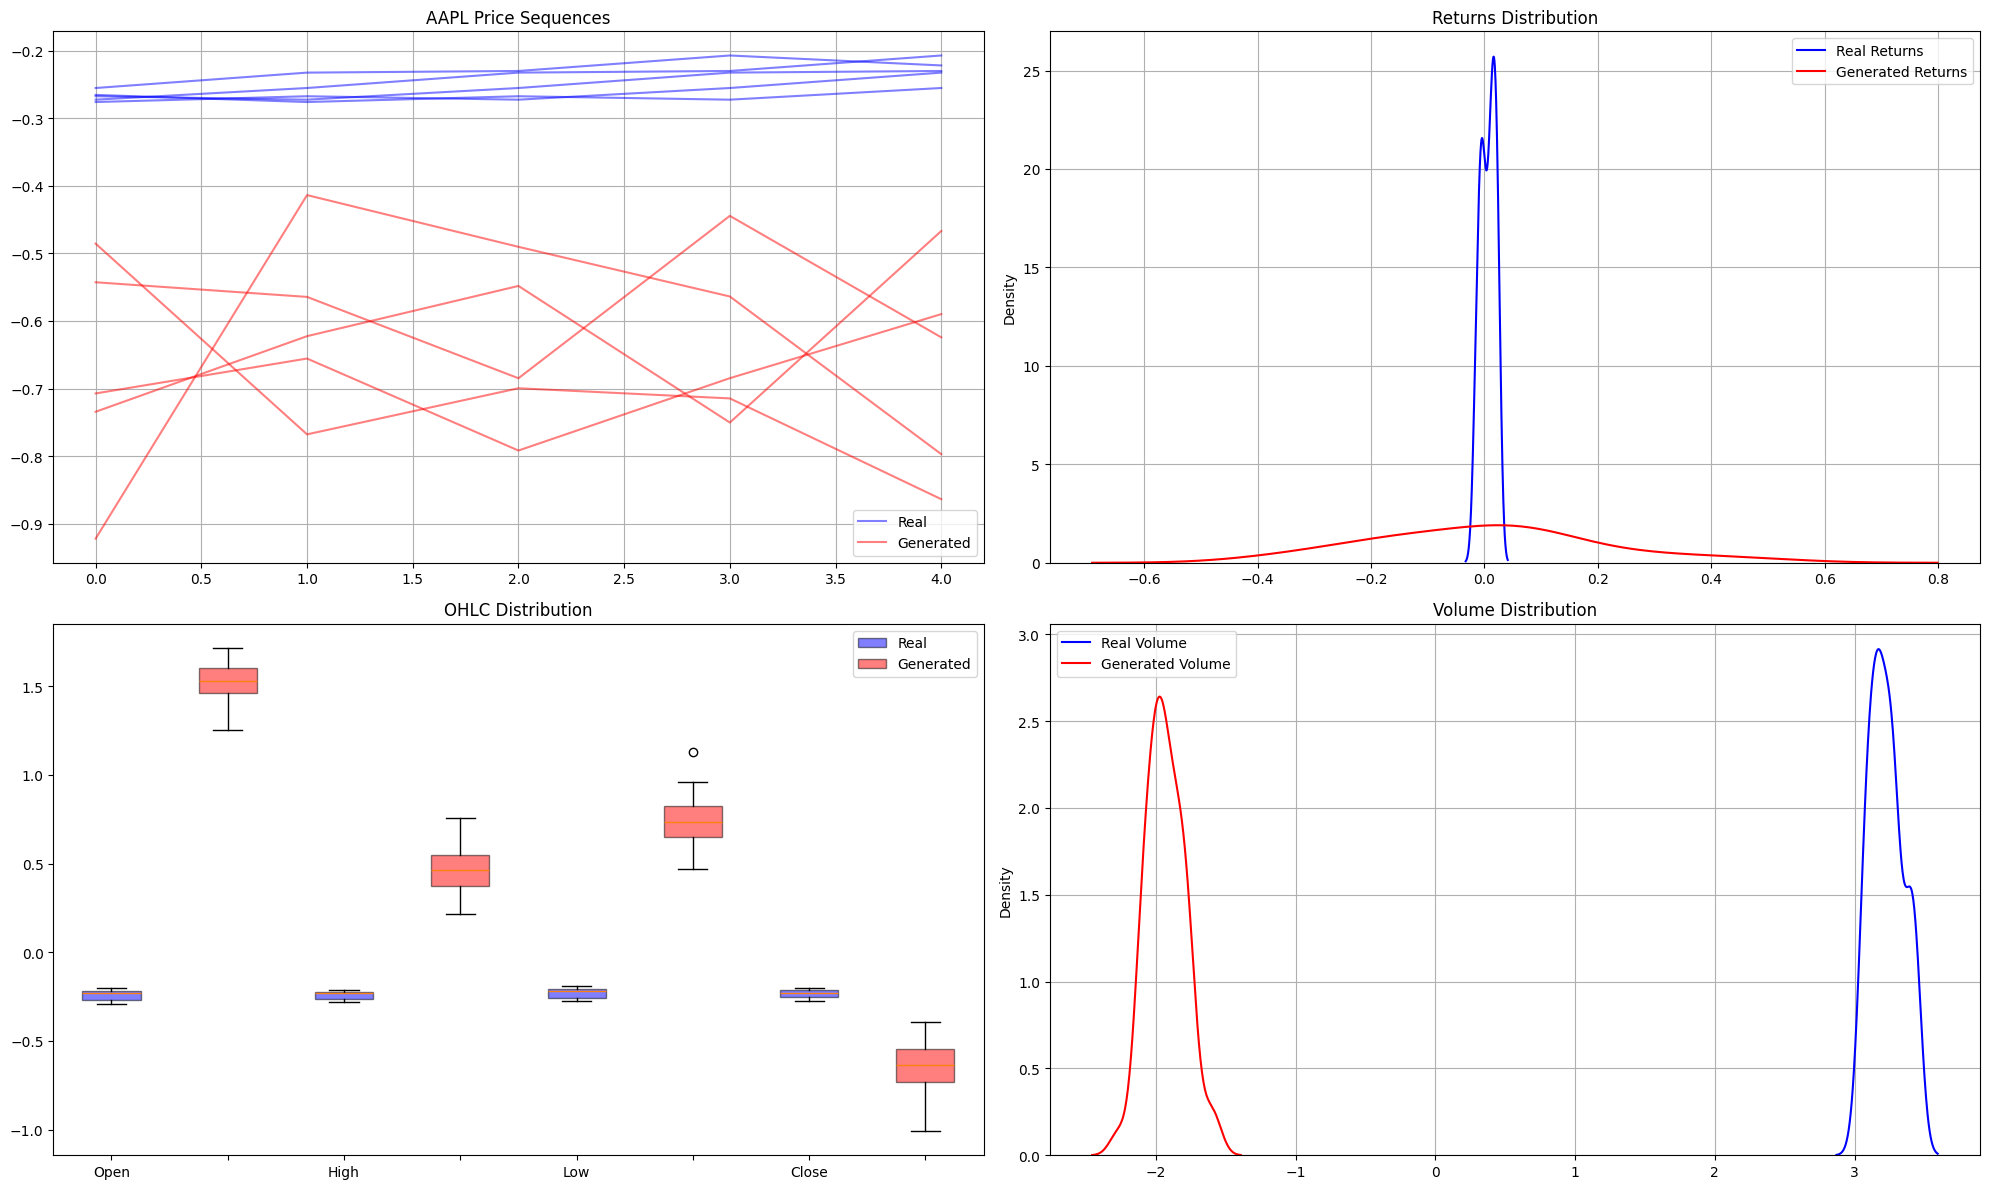


Evaluation Metrics for AAPL:

1. Price Consistency (High >= Low):
Real: 0.0000
Generated: 0.0200
Ratio: inf

2. Volume-Price Correlation:
Real: 0.0250
Generated: 0.3608
Absolute Difference: 0.3358

3. Volatility Similarity:
Real: 1.0000
Generated: 1.0000
Similarity Score: 1.0000


/var/folders/pk/p4tz0gf96l113931p5pw8d6c0000gp/T/ipykernel_38967/1040020035.py:89: RuntimeWarning: divide by zero encountered in scalar divide
  'ratio': gen_consistent / real_consistent


In [42]:

import matplotlib.pyplot as plt
import seaborn as sns

def visualize_comparison(real_samples, generated_samples, ticker):
    """
    Visualize comparison between real and generated data.
    """
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Price Series Plot
    plt.subplot(2, 2, 1)
    for i in range(min(5, len(real_samples))):
        plt.plot(real_samples[i, :, 3], 'b-', alpha=0.5, label='Real' if i==0 else '')
        plt.plot(generated_samples[i, :, 3], 'r-', alpha=0.5, label='Generated' if i==0 else '')
    plt.title(f'{ticker} Price Sequences')
    plt.legend()
    plt.grid(True)
    
    # 2. Returns Distribution
    plt.subplot(2, 2, 2)
    real_returns = np.diff(real_samples[..., 3], axis=1).flatten()
    gen_returns = np.diff(generated_samples[..., 3], axis=1).flatten()
    
    sns.kdeplot(data=real_returns, label='Real Returns', color='blue')
    sns.kdeplot(data=gen_returns, label='Generated Returns', color='red')
    plt.title('Returns Distribution')
    plt.legend()
    plt.grid(True)
    
    # 3. OHLC Box Plot
    plt.subplot(2, 2, 3)
    labels = ['Open', 'High', 'Low', 'Close']
    
    # Prepare data for box plot
    real_data = [real_samples[..., i].flatten() for i in range(4)]
    gen_data = [generated_samples[..., i].flatten() for i in range(4)]
    
    positions = np.arange(len(labels)) * 2
    box1 = plt.boxplot(real_data, positions=positions, labels=labels,
                      patch_artist=True, boxprops=dict(facecolor='blue', alpha=0.5))
    box2 = plt.boxplot(gen_data, positions=positions+1, labels=[''] * len(labels),
                      patch_artist=True, boxprops=dict(facecolor='red', alpha=0.5))
    plt.title('OHLC Distribution')
    plt.legend([box1["boxes"][0], box2["boxes"][0]], ['Real', 'Generated'])
    
    # 4. Volume Distribution
    plt.subplot(2, 2, 4)
    sns.kdeplot(data=real_samples[..., 4].flatten(), label='Real Volume', color='blue')
    sns.kdeplot(data=generated_samples[..., 4].flatten(), label='Generated Volume', color='red')
    plt.title('Volume Distribution')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def calculate_metrics(real_samples, generated_samples):
    """
    Calculate quantitative metrics for evaluation.
    """
    metrics = {}
    
    # 1. KL Divergence for returns
    real_returns = np.diff(real_samples[..., 3], axis=1).flatten()
    gen_returns = np.diff(generated_samples[..., 3], axis=1).flatten()
    
    # Normalize returns for KL calculation
    real_returns = (real_returns - real_returns.mean()) / real_returns.std()
    gen_returns = (gen_returns - gen_returns.mean()) / gen_returns.std()
    
    # 2. Price Movement Consistency
    real_consistent = np.mean(real_samples[..., 1] >= real_samples[..., 2])  # High >= Low
    gen_consistent = np.mean(generated_samples[..., 1] >= generated_samples[..., 2])
    
    # 3. Volume-Price Correlation
    real_vol_price_corr = np.corrcoef(real_samples[..., 3].flatten(), real_samples[..., 4].flatten())[0, 1]
    gen_vol_price_corr = np.corrcoef(generated_samples[..., 3].flatten(), generated_samples[..., 4].flatten())[0, 1]
    
    # 4. Volatility similarity
    real_vol = np.std(real_returns)
    gen_vol = np.std(gen_returns)
    vol_ratio = min(real_vol, gen_vol) / max(real_vol, gen_vol)
    
    metrics = {
        'price_consistency': {
            'real': real_consistent,
            'generated': gen_consistent,
            'ratio': gen_consistent / real_consistent
        },
        'volume_price_correlation': {
            'real': real_vol_price_corr,
            'generated': gen_vol_price_corr,
            'difference': abs(real_vol_price_corr - gen_vol_price_corr)
        },
        'volatility': {
            'real': real_vol,
            'generated': gen_vol,
            'similarity': vol_ratio
        }
    }
    
    return metrics

def print_evaluation(metrics, ticker):
    """
    Print evaluation metrics in a readable format.
    """
    print(f"\nEvaluation Metrics for {ticker}:")
    print("\n1. Price Consistency (High >= Low):")
    print(f"Real: {metrics['price_consistency']['real']:.4f}")
    print(f"Generated: {metrics['price_consistency']['generated']:.4f}")
    print(f"Ratio: {metrics['price_consistency']['ratio']:.4f}")
    
    print("\n2. Volume-Price Correlation:")
    print(f"Real: {metrics['volume_price_correlation']['real']:.4f}")
    print(f"Generated: {metrics['volume_price_correlation']['generated']:.4f}")
    print(f"Absolute Difference: {metrics['volume_price_correlation']['difference']:.4f}")
    
    print("\n3. Volatility Similarity:")
    print(f"Real: {metrics['volatility']['real']:.4f}")
    print(f"Generated: {metrics['volatility']['generated']:.4f}")
    print(f"Similarity Score: {metrics['volatility']['similarity']:.4f}")

# Use the functions
ticker = "AAPL"
generated_samples, real_samples = generate_samples(10, ticker_idx)

# Visualize
visualize_comparison(real_samples, generated_samples, ticker)

# Calculate and print metrics
metrics = calculate_metrics(real_samples, generated_samples)
print_evaluation(metrics, ticker)


In [30]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Parameters
batch_size = 64
sequence_length = 5
feature_dim = 508
noise_dim = 200
hidden_dim1 = 256
hidden_dim2 = 512
lstm_hidden_dim = 128  # Hidden dimension for LSTM
output_dim = 1

# Define generator weights
W1_full = torch.nn.Parameter(torch.randn(feature_dim + noise_dim + 2, hidden_dim1) / np.sqrt(feature_dim + noise_dim + 2))
b1_full = torch.nn.Parameter(torch.zeros(hidden_dim1))

W2 = torch.nn.Parameter(torch.randn(hidden_dim1, hidden_dim2) / np.sqrt(hidden_dim1))
b2 = torch.nn.Parameter(torch.zeros(hidden_dim2))

W3 = torch.nn.Parameter(torch.randn(hidden_dim2, feature_dim) / np.sqrt(hidden_dim2))
b3 = torch.nn.Parameter(torch.zeros(feature_dim))

# Define discriminator weights and LSTM
W1_disc = torch.nn.Parameter(torch.randn(feature_dim, hidden_dim1) / np.sqrt(feature_dim))
b1_disc = torch.nn.Parameter(torch.zeros(hidden_dim1))

W3_disc = torch.nn.Parameter(torch.randn(lstm_hidden_dim, output_dim) / np.sqrt(lstm_hidden_dim))
b3_disc = torch.nn.Parameter(torch.zeros(output_dim))

lstm = torch.nn.LSTM(input_size=hidden_dim1, hidden_size=lstm_hidden_dim, batch_first=True)

# Optimizers
learning_rate_gen = 0.0006
learning_rate_disc = 0.0001
gen_optimizer = torch.optim.Adam([W1_full, b1_full, W2, b2, W3, b3], lr=learning_rate_gen)
disc_optimizer = torch.optim.Adam([W1_disc, b1_disc, W3_disc, b3_disc] + list(lstm.parameters()), lr=learning_rate_disc)

# Feature selection using feature_info dictionary
# feature_info should be defined to map your features dynamically

# selected_features = torch.cat(
#     (
#         full_real_features[:, :, feature_info['features']['ohlcv']],
#         full_real_features[:, :, feature_info['features']['metrics']]
#     ),
#     dim=2
# )

# Helper function for generating sequences
def generate_sequences_for_stock(full_real_features):
    # Extract batch, sequence length, and feature dimensions
    batch_size, sequence_length, feature_dim = full_real_features.shape
    
    # Extract feature groups using `feature_info`
    ohlcv_features = full_real_features[:, :, feature_info['features']['ohlcv']]
    ticker_encoding = full_real_features[:, :, feature_info['features']['ticker_encoding']]
    day_encoding = full_real_features[:, :, feature_info['features']['day_encoding']]
    metrics = full_real_features[:, :, feature_info['features']['metrics']]
    
    # Generate random noise with the correct shape
    noise = torch.randn(batch_size, sequence_length, noise_dim)
    
    # Concatenate all features and noise to form the generator input
    gen_input = torch.cat((ohlcv_features, ticker_encoding, day_encoding, metrics, noise), dim=2)
    print("Concatenated gen_input shape:", gen_input.shape)  # Expected: (batch_size, sequence_length, feature_dim + noise_dim)

    generated_sequence = []
    
    # Process each day separately within the sequence
    for day in range(sequence_length):
        day_input = gen_input[:, day, :]  # Shape: (batch_size, feature_dim + noise_dim)
        print(f"Day {day + 1} input shape:", day_input.shape)

        # Forward pass through layers for each day
        hidden1 = F.leaky_relu(torch.matmul(day_input, W1_full) + b1_full)
        hidden2 = F.leaky_relu(torch.matmul(hidden1, W2) + b2)
        day_output = torch.tanh(torch.matmul(hidden2, W3) + b3)  # Output for each day's features

        generated_sequence.append(day_output)
    
    # Stack all days to form the final generated sequence
    generated_sequences = torch.stack(generated_sequence, dim=1)  # Shape: (batch_size, sequence_length, feature_dim)
    print("Generated sequence shape (inside function):", generated_sequences.shape)
    return generated_sequences

# Training loop
epochs = 2000
print_interval = 50
for epoch in range(epochs):
    # Generate noise, one-hot ticker, and day encoding for generator input
    noise = torch.randn(batch_size, sequence_length, noise_dim)
    days = torch.arange(sequence_length).repeat(batch_size, 1)
    angles = 2 * torch.pi * days / sequence_length
    cyclical_day_encoding = torch.stack((torch.sin(angles), torch.cos(angles)), dim=2)

    # Placeholder ticker encoding (select the correct index without hardcoding)
    stock_one_hot = torch.zeros((batch_size, sequence_length, len(feature_info['features']['ticker_encoding'])))
    stock_index = 15  # Example dynamic stock index; replace with desired ticker index lookup
    stock_one_hot[:, :, stock_index] = 1

    gen_input = torch.cat((noise, stock_one_hot, cyclical_day_encoding), dim=2)

    # Generate fake sequences
    generated_sequences = generate_sequences_for_stock(gen_input)

    # Discriminator - Real Data
    start_index = (epoch * batch_size) % (len(converted_data) - batch_size)
    end_index = start_index + batch_size
    real_sequences = torch.tensor(converted_data[start_index:end_index], dtype=torch.float32)

    # Reshape for discriminator
    real_disc_input = real_sequences.reshape(batch_size * sequence_length, feature_dim)
    fake_disc_input = generated_sequences.reshape(batch_size * sequence_length, feature_dim)

    # Forward pass real and fake data through the discriminator
    hidden_real = F.leaky_relu(torch.matmul(real_disc_input, W1_disc) + b1_disc)
    hidden_real = hidden_real.reshape(batch_size, sequence_length, hidden_dim1)
    hidden_fake = F.leaky_relu(torch.matmul(fake_disc_input, W1_disc) + b1_disc)
    hidden_fake = hidden_fake.reshape(batch_size, sequence_length, hidden_dim1)

    # Pass through LSTM
    lstm_output_real, (h_n_real, _) = lstm(hidden_real)
    lstm_output_fake, (h_n_fake, _) = lstm(hidden_fake)

    # Final classification layer
    disc_output_real = torch.sigmoid(torch.matmul(h_n_real.squeeze(0), W3_disc) + b3_disc)
    disc_output_fake = torch.sigmoid(torch.matmul(h_n_fake.squeeze(0), W3_disc) + b3_disc)

    # Discriminator loss
    real_labels = torch.ones(disc_output_real.shape)
    fake_labels = torch.zeros(disc_output_fake.shape)
    real_loss = F.binary_cross_entropy(disc_output_real, real_labels)
    fake_loss = F.binary_cross_entropy(disc_output_fake, fake_labels)
    disc_loss = real_loss + fake_loss

    # Backpropagate and update discriminator
    disc_optimizer.zero_grad()
    disc_loss.backward(retain_graph=True)
    disc_optimizer.step()

    # Train generator
    gen_optimizer.zero_grad()
    fake_disc_input = generated_sequences.reshape(batch_size * sequence_length, feature_dim)
    hidden_fake = F.leaky_relu(torch.matmul(fake_disc_input, W1_disc) + b1_disc)
    hidden_fake = hidden_fake.reshape(batch_size, sequence_length, hidden_dim1)
    lstm_output_fake, (h_n_fake, _) = lstm(hidden_fake)
    disc_output_fake = torch.sigmoid(torch.matmul(h_n_fake.squeeze(0), W3_disc) + b3_disc)
    gen_loss = F.binary_cross_entropy(disc_output_fake, real_labels)
    gen_loss.backward()
    gen_optimizer.step()

    # Logging
    if (epoch + 1) % print_interval == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Discriminator Loss: {disc_loss.item():.4f}, Generator Loss: {gen_loss.item():.4f}")


TypeError: object of type 'slice' has no len()

In [45]:
feature_info

{'shape': (370440, 5, 511),
 'features': {'ohlcv': slice(0, 5, None),
  'ticker_encoding': slice(5, 499, None),
  'day_encoding': slice(499, 504, None),
  'metrics': slice(504, None, None)}}

In [41]:
import matplotlib.pyplot as plt
import torch


# Choose a ticker dynamically (e.g., "JPM")
selected_ticker = "MMM"
ticker_index = ticker_to_idx[selected_ticker]  # Dynamically select index

# Create one-hot encoding for the selected stock
num_tickers = feature_info['features']['ticker_encoding'].stop - feature_info['features']['ticker_encoding'].start
stock_one_hot = torch.zeros((batch_size, sequence_length, num_tickers))
stock_one_hot[:, :, ticker_index] = 1  # Set only the selected ticker index to 1

# Generate cyclical day encoding for evaluation (Monday through Friday)
days = torch.arange(sequence_length).repeat(batch_size, 1)
angles = 2 * torch.pi * days / sequence_length
cyclical_day_encoding = torch.stack((torch.sin(angles), torch.cos(angles)), dim=2)

# Generate random noise
noise = torch.randn(batch_size, sequence_length, noise_dim)

# Concatenate all input parts: noise, stock one-hot, and cyclical day encoding
gen_input = torch.cat((noise, stock_one_hot, cyclical_day_encoding), dim=2)

# Generate synthetic sequences using the generator
with torch.no_grad():
    generated_sequences = generate_sequences_for_stock(gen_input)

# Select real sequences for the specified stock
start_index = 0  # Adjust as appropriate for the desired time period
end_index = start_index + batch_size
real_sequences = torch.tensor(converted_data[start_index:end_index], dtype=torch.float32)

# Ensure the real sequences contain the same ticker encoding
real_sequences[:, :, feature_info['features']['ticker_encoding'].start + ticker_index] = 1

# Visualization of selected features
features_to_plot = ["Open", "High", "Low", "Close", "Volume"]
feature_indices = [0, 1, 2, 3, 4]  # Adjust these indices to match OHLCV in your dataset

plt.figure(figsize=(14, 10))
for i, feature_idx in enumerate(feature_indices):
    plt.subplot(len(feature_indices), 1, i + 1)
    
    # Plot real and generated data for each feature
    plt.plot(real_sequences[0, :, feature_idx].numpy(), label="Real Data", linestyle="--", color="blue")
    plt.plot(generated_sequences[0, :, feature_idx].numpy(), label="Generated Data", linestyle="-", color="orange")
    
    plt.title(features_to_plot[i])
    plt.xlabel("Time Steps (Days)")
    plt.ylabel("Normalized Value")
    plt.legend()

plt.tight_layout()
plt.show()


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x896 and 708x256)

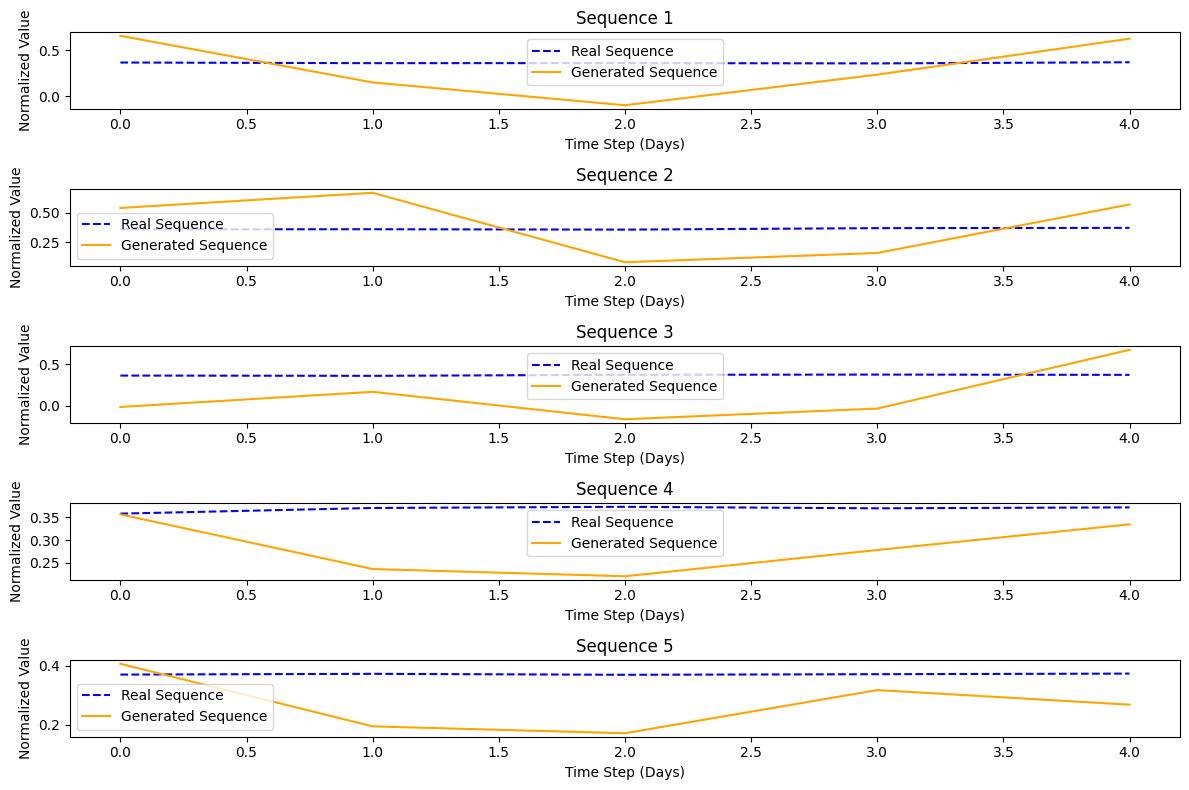

In [33]:
import matplotlib.pyplot as plt

# Set the model to evaluation mode
# (This step can help if using layers like dropout or batch normalization)
# lstm.eval() # Uncomment if you have dropout/batchnorm in your model

# Generate fake sequences for evaluation
with torch.no_grad():
    noise = torch.randn(batch_size, noise_dim)
    hidden1 = F.leaky_relu(torch.matmul(noise, W1) + b1)
    hidden2 = F.leaky_relu(torch.matmul(hidden1, W2) + b2)
    output = torch.matmul(hidden2, W3) + b3
    generated_sequences = torch.tanh(output).reshape(batch_size, sequence_length, feature_dim)

# Select a batch of real sequences from the dataset for comparison
# Ensure these sequences align with those used in training or a similar time period
start_index = 0  # Starting index for evaluation
end_index = start_index + batch_size
real_sequences = torch.tensor(converted_data[start_index:end_index], dtype=torch.float32)

# Visualize and compare generated vs. real sequences
plt.figure(figsize=(12, 8))
for i in range(min(batch_size, 5)):  # Plot a few sequences for visualization
    plt.subplot(5, 1, i + 1)
    
    # Plot real and generated sequences for a specific feature, e.g., "Close" (assuming it's index 3)
    plt.plot(real_sequences[i, :, 3].numpy(), label='Real Sequence', linestyle='--', color='blue')
    plt.plot(generated_sequences[i, :, 3].numpy(), label='Generated Sequence', linestyle='-', color='orange')
    
    plt.title(f'Sequence {i + 1}')
    plt.xlabel("Time Step (Days)")
    plt.ylabel("Normalized Value")
    plt.legend()

plt.tight_layout()
plt.show()


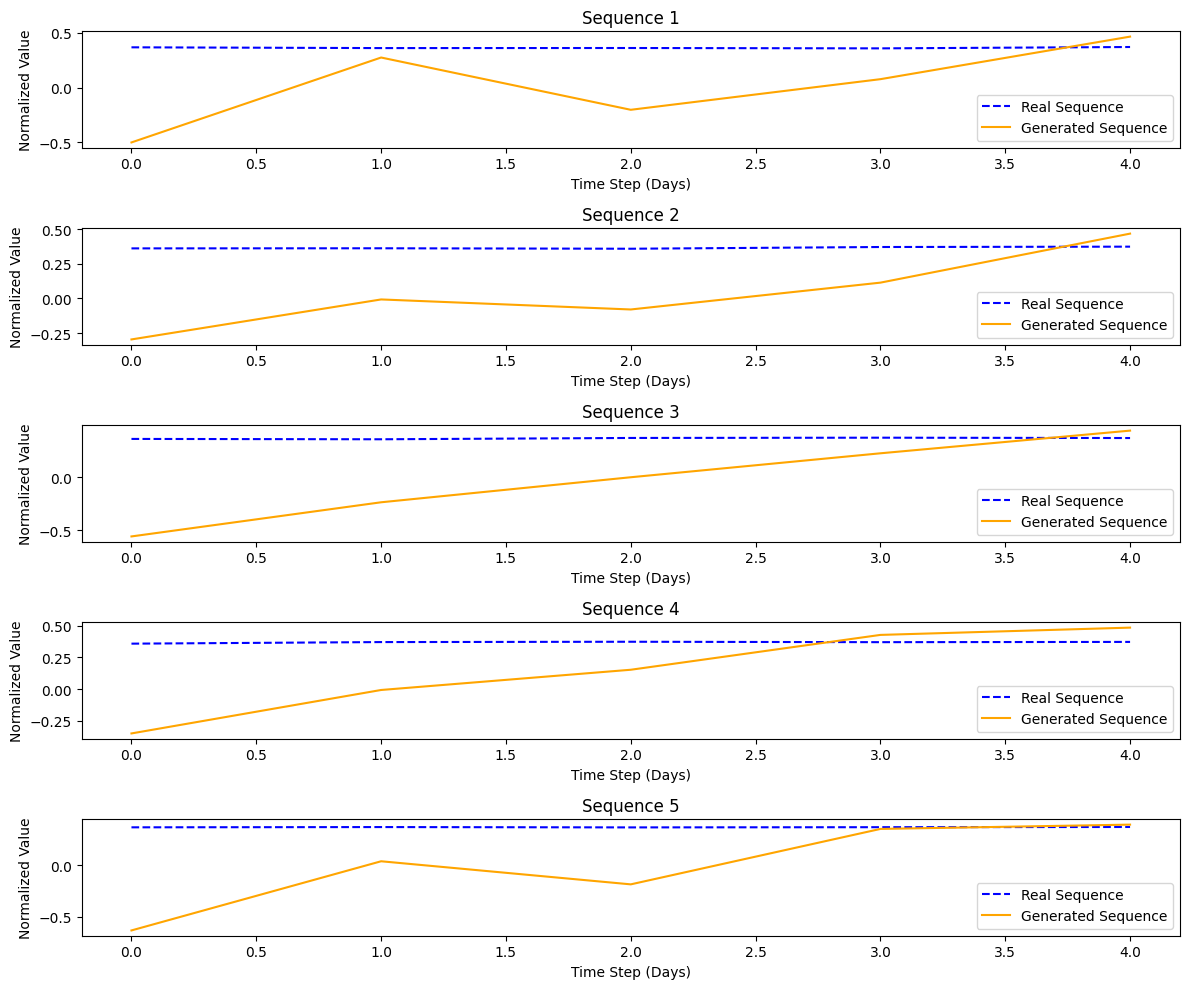

In [30]:
import matplotlib.pyplot as plt

# Normalize generated data to the same range [-3, 3]
generated_sequences_clipped = np.clip(generated_sequences.detach().numpy(), -3, 3)

# Plot the generated vs real data for comparison
plt.figure(figsize=(12, 10))
for i in range(min(batch_size, 5)):  # Plot a few sequences for visual comparison
    plt.subplot(5, 1, i + 1)
    
    # Assuming 'Close' price is index 3 in OHLCV (adjust if needed)
    plt.plot(real_sequences[i, :, 3].numpy(), label='Real Sequence', linestyle='--', color='blue')
    plt.plot(generated_sequences_clipped[i, :, 3], label='Generated Sequence', linestyle='-', color='orange')
    
    plt.title(f'Sequence {i + 1}')
    plt.xlabel("Time Step (Days)")
    plt.ylabel("Normalized Value")
    plt.legend()

plt.tight_layout()
plt.show()


In [27]:
normalized_data.shape

(370440, 5, 511)

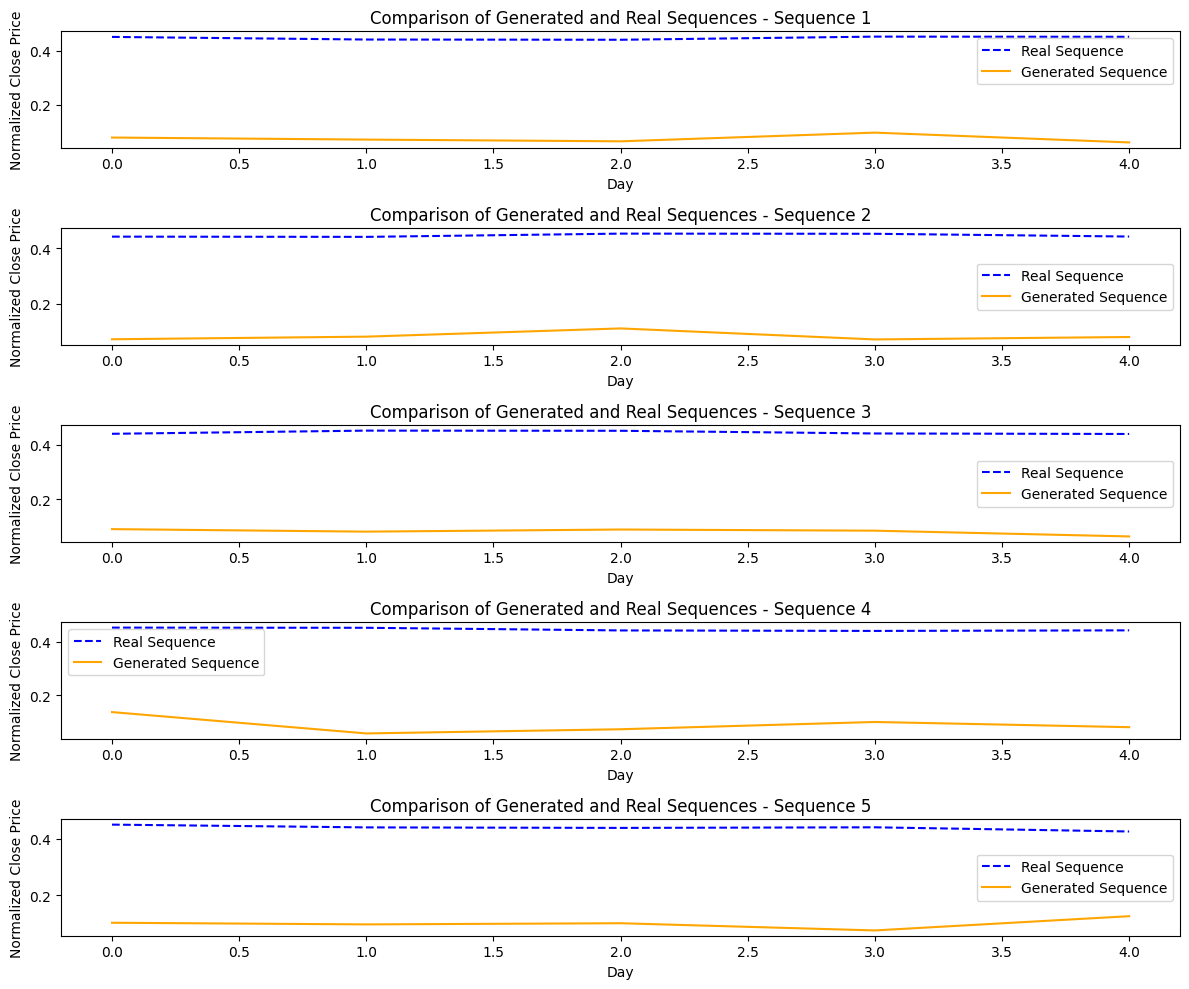

In [35]:
import matplotlib.pyplot as plt

# Create a figure with subplots for each sequence
num_sequences = min(5, batch_size)  # Number of sequences to display
fig, axs = plt.subplots(num_sequences, 1, figsize=(12, 2 * num_sequences))

for i in range(num_sequences):
    # Plot real sequences
    axs[i].plot(real_sequences[i, :, 3], label='Real Sequence', linestyle='--', color='blue')  # Assuming index 3 is "Close"
    # Plot generated sequences
    axs[i].plot(generated_sequences[i, :, 3].detach().numpy(), label='Generated Sequence', color='orange')  # Assuming index 3 is "Close"
    
    axs[i].set_title(f"Comparison of Generated and Real Sequences - Sequence {i + 1}")
    axs[i].set_xlabel("Day")
    axs[i].set_ylabel("Normalized Close Price")
    axs[i].legend()

plt.tight_layout()
plt.show()


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

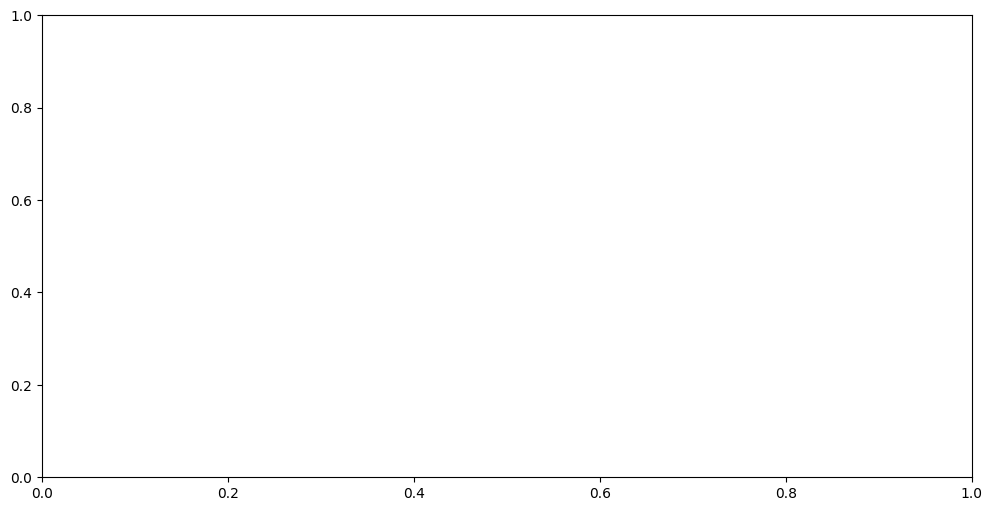

In [29]:
# Generate sequences from noise for visualization
noise = torch.randn(batch_size, noise_dim)
hidden1 = F.relu(torch.matmul(noise, W1) + b1)
hidden2 = F.relu(torch.matmul(hidden1, W2) + b2)
output = torch.matmul(hidden2, W3) + b3
generated_sequences = torch.tanh(output).reshape(batch_size, sequence_length, feature_dim)

# Plot a few generated sequences (e.g., closing prices over 5 days)
plt.figure(figsize=(12, 6))
for i in range(min(5, batch_size)):  # Plot only a few sequences
    plt.plot(generated_sequences[i, :, 3], label=f'Sequence {i+1}')  # Assuming index 3 is "Close"
plt.title("Generated Sequences - Close Prices")
plt.xlabel("Day")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.show()


In [52]:
import torch.nn.functional as F
import torch.optim as optim

# Define labels for real and fake sequences
real_labels = torch.ones(batch_size, 1)  # Labels for real sequences
fake_labels = torch.zeros(batch_size, 1)  # Labels for generated (fake) sequences

# Set learning rate for optimizers
learning_rate = 0.0002  # Typical learning rate for GANs

# Optimizer for discriminator
disc_optimizer = optim.Adam([W1_disc, b1_disc, W3_disc, b3_disc], lr=learning_rate)

# Optimizer for generator
gen_optimizer = optim.Adam([W1, b1, W2, b2, W3, b3], lr=learning_rate)


In [32]:
# Cell 4: Create our first generator layer
batch_size = 32
noise_dim = 100

# Generate random noise
noise = torch.randn(batch_size, noise_dim)
print("Noise shape:", noise.shape)
print("Sample noise values:", noise[0][:5])  # First 5 values of first batch

# First layer: noise -> 256 features
W1 = torch.randn(noise_dim, 256) / np.sqrt(noise_dim)
b1 = torch.zeros(256)

# Forward pass through first layer
hidden1 = torch.matmul(noise, W1) + b1
print("\nFirst hidden layer shape:", hidden1.shape)
print("Sample hidden values before activation:", hidden1[0][:5])

# Apply LeakyReLU activation
hidden1_activated = torch.where(hidden1 > 0, hidden1, 0.2 * hidden1)
print("\nSample hidden values after LeakyReLU:", hidden1_activated[0][:5])

Noise shape: torch.Size([32, 100])
Sample noise values: tensor([-2.5322,  1.3582,  0.1937, -0.2511,  1.1372])

First hidden layer shape: torch.Size([32, 256])
Sample hidden values before activation: tensor([ 2.8110, -0.0790, -0.0699, -2.7773,  0.8189])

Sample hidden values after LeakyReLU: tensor([ 2.8110, -0.0158, -0.0140, -0.5555,  0.8189])


In [33]:

# Cell 5: Continue building generator - second layer
# We have our first layer output: hidden1_activated (32 batches, 256 features)
print("Input to second layer shape:", hidden1_activated.shape)

# Second layer: 256 -> 512 features
W2 = torch.randn(256, 512) / np.sqrt(256)  # Xavier initialization
b2 = torch.zeros(512)

# Forward pass through second layer
hidden2 = torch.matmul(hidden1_activated, W2) + b2
print("\nBefore batch normalization, first few values:")
print(hidden2[0][:5])

# Batch Normalization
# Calculate mean and variance across batch dimension
batch_mean = hidden2.mean(dim=0)
batch_var = hidden2.var(dim=0, unbiased=False)
epsilon = 1e-5  # Small number for numerical stability

# Normalize
hidden2_normalized = (hidden2 - batch_mean) / torch.sqrt(batch_var + epsilon)
print("\nAfter normalization, first few values:")
print(hidden2_normalized[0][:5])

# Add learnable parameters (gamma and beta)
gamma = torch.ones(512)  # Initialize to 1
beta = torch.zeros(512)  # Initialize to 0
hidden2_normalized = gamma * hidden2_normalized + beta

# Apply LeakyReLU
hidden2_activated = torch.where(hidden2_normalized > 0, hidden2_normalized, 0.2 * hidden2_normalized)
print("\nAfter LeakyReLU, first few values:")
print(hidden2_activated[0][:5])

Input to second layer shape: torch.Size([32, 256])

Before batch normalization, first few values:
tensor([ 0.5635, -0.2263,  0.1864,  1.1752, -1.5924])

After normalization, first few values:
tensor([ 0.7430, -0.4633,  0.8130,  1.2957, -1.8287])

After LeakyReLU, first few values:
tensor([ 0.7430, -0.0927,  0.8130,  1.2957, -0.3657])


Input to final layer shape: torch.Size([32, 512])

Before tanh, first sequence values:
tensor([-1.7072e+00, -3.3503e-02,  4.7413e-04,  3.5257e-01,  2.4530e-03,
         5.7849e-02,  1.1904e+00,  4.1543e-02,  8.0883e-02, -4.3192e-01,
        -5.4660e-01, -1.1689e+00, -4.9289e-01, -5.2048e-01, -1.7651e+00,
        -7.1291e-01,  8.3937e-01, -1.0068e+00,  4.4501e-01, -1.9544e-02,
         4.9907e-02, -2.8765e-01,  2.1569e-01,  1.5531e-01,  2.8671e-01])

After tanh (final output), first sequence values:
tensor([-9.3630e-01, -3.3490e-02,  4.7413e-04,  3.3866e-01,  2.4530e-03,
         5.7784e-02,  8.3070e-01,  4.1519e-02,  8.0707e-02, -4.0692e-01,
        -4.9796e-01, -8.2393e-01, -4.5651e-01, -4.7807e-01, -9.4306e-01,
        -6.1250e-01,  6.8548e-01, -7.6442e-01,  4.1779e-01, -1.9542e-02,
         4.9865e-02, -2.7997e-01,  2.1240e-01,  1.5407e-01,  2.7910e-01])

Reshaped output shape: torch.Size([32, 5, 5])

First generated sequence (5 days, 5 features):
tensor([[-9.3630e-01, -3.3490e-02, 

NameError: name 'sequences_tensor' is not defined

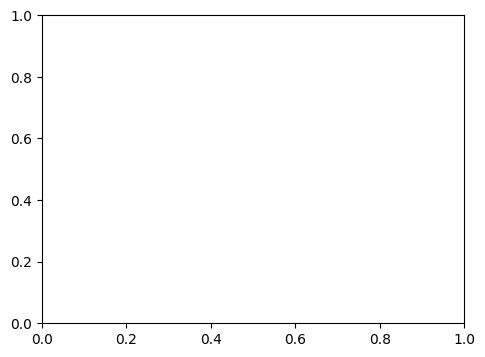

In [34]:
# Cell 6: Final generator layer - creating stock-like data
# We have hidden2_activated (32 batches, 512 features)
# Need to output 5 days * 5 features = 25 values
print("Input to final layer shape:", hidden2_activated.shape)

# Final layer: 512 -> 25 (5 days * 5 features)
W3 = torch.randn(512, 25) / np.sqrt(512)
b3 = torch.zeros(25)

# Forward pass through final layer
output = torch.matmul(hidden2_activated, W3) + b3
print("\nBefore tanh, first sequence values:")
print(output[0])

# Apply tanh to keep values between -1 and 1
final_output = torch.tanh(output)
print("\nAfter tanh (final output), first sequence values:")
print(final_output[0])

# Reshape to (batch_size, 5 days, 5 features)
final_output = final_output.reshape(batch_size, 5, 5)
print("\nReshaped output shape:", final_output.shape)
print("\nFirst generated sequence (5 days, 5 features):")
print(final_output[0])

# Let's visualize real vs generated sequence
plt.figure(figsize=(12, 4))

# Plot real sequence (Close prices)
plt.subplot(1, 2, 1)
real_seq = sequences_tensor[0, :, 3].numpy()  # First sequence, all days, Close price
plt.plot(real_seq, marker='o', label='Real')
plt.title('Real Stock Sequence')
plt.ylabel('Normalized Close Price')

# Plot generated sequence (Close prices)
plt.subplot(1, 2, 2)
gen_seq = final_output[0, :, 3].detach().numpy()  # First sequence, all days, Close price
plt.plot(gen_seq, marker='o', label='Generated')
plt.title('Generated Stock Sequence')
plt.ylabel('Normalized Close Price')

plt.tight_layout()
plt.show()

In [67]:
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for i, col in enumerate(cols):
    print(f'\n{col}:')
    print('Median:', np.median(training_data[:, i]))
    print('Mean:', np.mean(training_data[:, i]))
    print('STD:', np.std(training_data[:, i]))


Open:
Median: 129.0500030517578
Mean: 1315706.1444272604
STD: 12057785.640028648

High:
Median: 129.0800018310547
Mean: 1315374.9414319235
STD: 12058666.033384642

Low:
Median: 129.11000061035156
Mean: 1315138.148919694
STD: 12059120.688583696

Close:
Median: 129.13999938964844
Mean: 1314887.3729255756
STD: 12060508.241821395

Volume:
Median: 129.1699981689453
Mean: 1314513.2060729654
STD: 12058991.595104035


In [83]:
total_sequences

370440

In [80]:
# Get unique tickers from `valid_stocks`
tickers = list(valid_stocks.keys())
ticker_to_idx = {ticker: idx for idx, ticker in enumerate(tickers)}
num_tickers = len(tickers)

# Initialize conditional vectors
ticker_conditions = np.zeros((total_sequences, num_tickers))

# Fill conditional vectors for each sequence
current_idx = 0
for symbol, stock_df in valid_stocks.items():
    ticker_idx = ticker_to_idx[symbol]
    n_sequences = len(stock_df) - 4
    for _ in range(n_sequences):
        ticker_conditions[current_idx, ticker_idx] = 1  # One-hot encode the ticker
        current_idx += 1

print("Ticker conditions shape:", ticker_conditions.shape)
print("Sample ticker condition (one-hot):\n", ticker_conditions[0])


Ticker conditions shape: (370440, 494)
Sample ticker condition (one-hot):
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [84]:
ticker_conditions[0].shape

(494,)

# Appendix

## Sequence generation explanation

In [7]:
np.random.seed(11)
selected_stocks = np.random.choice(list(stock_data.keys()), 2, replace=False)
selected_stocks

array(['TDY', 'MRNA'], dtype='<U5')

In [8]:
rows_per_stock = 7
example_data_dict = {}
for stock in selected_stocks:
    df = stock_data[stock]
    example_data_dict[stock] = df.iloc[:rows_per_stock]
example_data_dict

{'TDY':                   Open        High         Low       Close  Volume
 Date                                                              
 2020-01-02  348.769989  357.690002  348.209991  357.489990  193800
 2020-01-03  353.799988  361.730011  353.799988  360.049988  202500
 2020-01-06  359.369995  363.410004  357.730011  358.630005  222400
 2020-01-07  358.010010  362.429993  356.700012  361.089996  263100
 2020-01-08  362.579987  364.970001  360.130005  361.549988  242600
 2020-01-09  363.859985  368.200012  362.640015  366.100006  186400
 2020-01-10  367.540009  368.170013  362.519989  365.549988  140400,
 'MRNA':                  Open       High        Low      Close   Volume
 Date                                                           
 2020-01-02  19.570000  19.809999  18.879999  19.230000  1233600
 2020-01-03  19.020000  19.360001  18.719999  18.889999  1751000
 2020-01-06  18.700001  18.740000  18.010000  18.129999  1606500
 2020-01-07  18.150000  18.320000  17.680000  1

We want to create sequences of 5 days. On this example we can see how to create sequences:

In [9]:
total_sequences = 0
for stock_df in example_data_dict.values():
    n_sequences = len(stock_df) - 4
    total_sequences += n_sequences
    print(n_sequences, total_sequences)

print(f"Total sequences of 5 days we can create from valid stocks: {total_sequences}")

3 3
3 6
Total sequences of 5 days we can create from valid stocks: 6


In [10]:
mini_stock = example_data_dict['TDY']

print("Original data has 7 days:")
print(mini_stock)

# We want sequences of 5 days
sequence_length = 5

print("\nPossible 5-day sequences:")
print("Sequence 1:", mini_stock.index[0:5])  # days 1-5
print("Sequence 2:", mini_stock.index[1:6])  # days 2-6
print("Sequence 3:", mini_stock.index[2:7])  # days 3-7

# Total possible sequences = length - sequence_length + 1
# In this case: 7 - 5 + 1 = 3 sequences
print(f"\nFor {len(mini_stock)} days of data, we can make {len(mini_stock) - sequence_length + 1} sequences of {sequence_length} days")

# This is why we use len(sample_stock) - 4:
# sequence_length = 5
# possible_sequences = length - sequence_length + 1
# possible_sequences = length - 5 + 1
# possible_sequences = length - 4

print("\nSliding window of 5 days:")
for i in range(len(mini_stock) - sequence_length + 1):
    print(f"Sequence {i+1}:", mini_stock.index[i:i+sequence_length].tolist())

Original data has 7 days:
                  Open        High         Low       Close  Volume
Date                                                              
2020-01-02  348.769989  357.690002  348.209991  357.489990  193800
2020-01-03  353.799988  361.730011  353.799988  360.049988  202500
2020-01-06  359.369995  363.410004  357.730011  358.630005  222400
2020-01-07  358.010010  362.429993  356.700012  361.089996  263100
2020-01-08  362.579987  364.970001  360.130005  361.549988  242600
2020-01-09  363.859985  368.200012  362.640015  366.100006  186400
2020-01-10  367.540009  368.170013  362.519989  365.549988  140400

Possible 5-day sequences:
Sequence 1: DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08'],
              dtype='datetime64[ns]', name='Date', freq=None)
Sequence 2: DatetimeIndex(['2020-01-03', '2020-01-06', '2020-01-07', '2020-01-08',
               '2020-01-09'],
              dtype='datetime64[ns]', name='Date', freq=


If we have 7 days total:

First sequence: days 1,2,3,4,5

Second sequence: days 2,3,4,5,6

Third sequence: days 3,4,5,6,7

Total sequences = 7 - 4 = 3


In our actual data with 756 days:

First sequence: days 1-5

Second sequence: days 2-6

...

Last sequence: days 752-756

Total sequences = 756 - 4 = 752